Reading all sheets from 'datatoshafi.xlsx'...
Loaded sheet: Phan  with 16436 rows
Loaded sheet: Thuận with 16436 rows
Loaded sheet: Ninh with 16436 rows
Successfully combined 3 sheets. Total rows: 49308


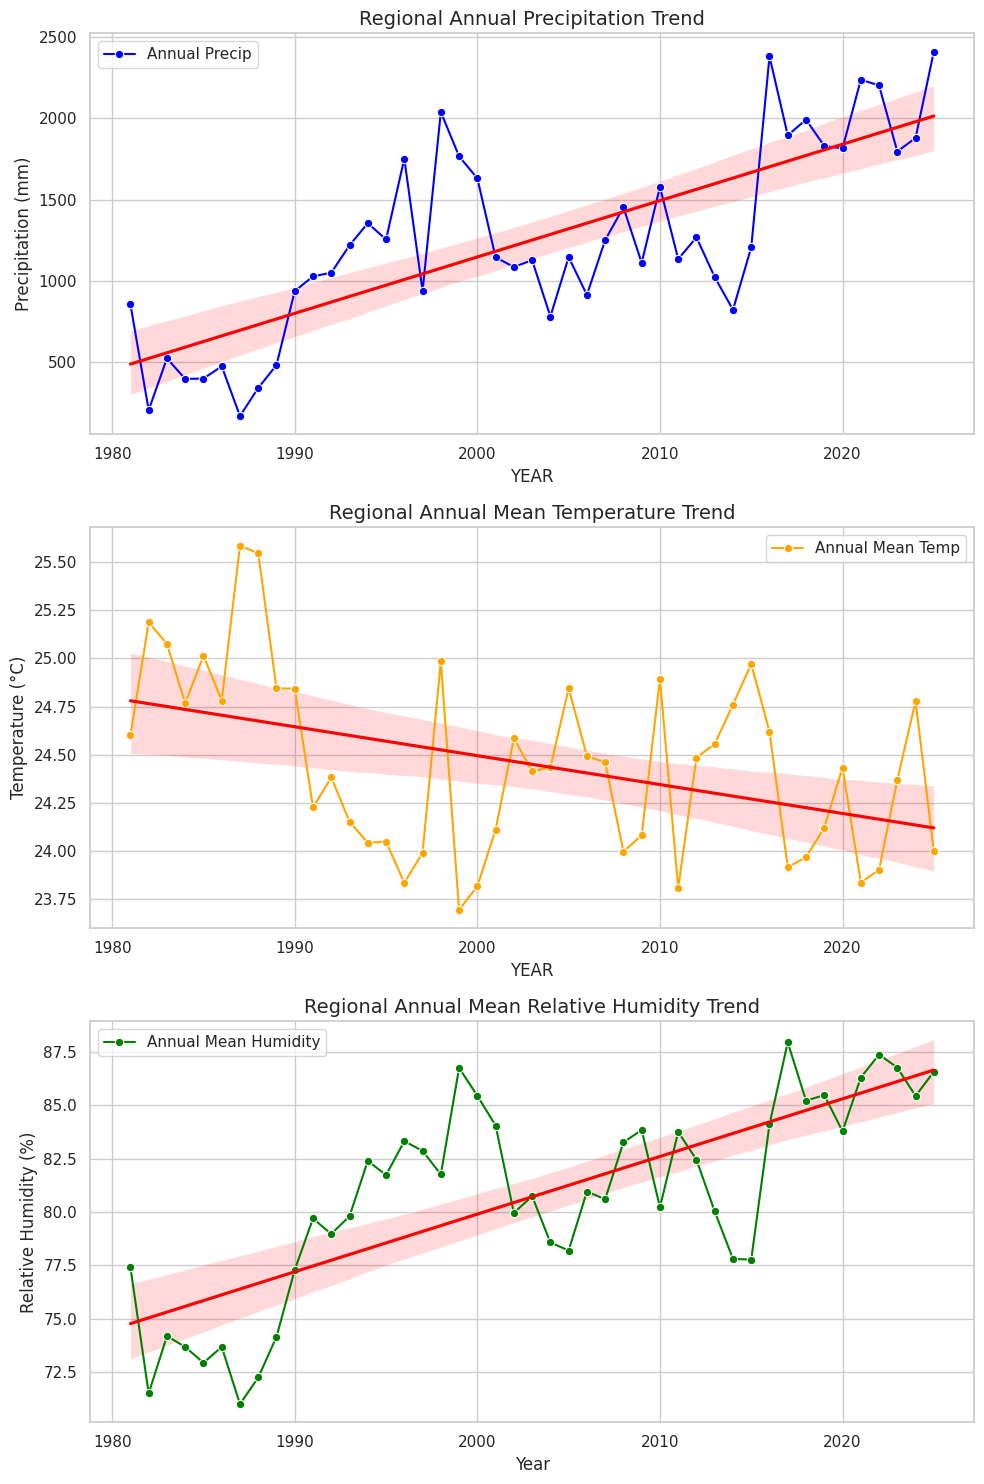

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import files

# ---------------------------------------------------------
# 1. LOAD EXCEL FILE
# ---------------------------------------------------------
filename = 'datatoshafi.xlsx'

# Check if file exists, if not, prompt upload
if not os.path.exists(filename):
    print(f"'{filename}' not found. Please upload it now.")
    uploaded = files.upload()
    if filename not in uploaded:
        # If user uploaded with a different name, try to grab the first xlsx found
        uploaded_files = [f for f in uploaded.keys() if f.endswith('.xlsx')]
        if uploaded_files:
            filename = uploaded_files[0]
            print(f"Using uploaded file: {filename}")
        else:
            raise FileNotFoundError("Please upload the correct .xlsx file.")

print(f"Reading all sheets from '{filename}'...")

# Read all sheets at once
# sheet_name=None reads all sheets into a dictionary
all_sheets = pd.read_excel(filename, sheet_name=None)

# Combine all sheets into one DataFrame
dfs = []
for sheet_name, df in all_sheets.items():
    print(f"Loaded sheet: {sheet_name} with {len(df)} rows")
    dfs.append(df)

if dfs:
    combined_df = pd.concat(dfs, ignore_index=True)
    print(f"Successfully combined {len(dfs)} sheets. Total rows: {len(combined_df)}")
else:
    raise ValueError("The Excel file appears to be empty.")

# ---------------------------------------------------------
# 2. DATA PROCESSING (Regional Trends)
# ---------------------------------------------------------
# 1. Calculate Annual Sum/Mean per Station
station_annual = combined_df.groupby(['YEAR', 'Location']).agg({
    'Precipitation': 'sum',           # Total Rainfall
    't2m': 'mean',                    # Average Temp
    'RelativeHumidityat2m': 'mean'    # Average Humidity
}).reset_index()

# 2. Calculate Regional Average (Mean of the 3 stations)
regional_trends = station_annual.groupby('YEAR').agg({
    'Precipitation': 'mean',
    't2m': 'mean',
    'RelativeHumidityat2m': 'mean'
}).reset_index()

# ---------------------------------------------------------
# 3. VISUALIZATION
# ---------------------------------------------------------
sns.set(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: Precipitation
sns.lineplot(data=regional_trends, x='YEAR', y='Precipitation', ax=axes[0], marker='o', color='blue', label='Annual Precip')
sns.regplot(data=regional_trends, x='YEAR', y='Precipitation', ax=axes[0], scatter=False, color='red', line_kws={'label': 'Linear Trend'})
axes[0].set_title('Regional Annual Precipitation Trend', fontsize=14)
axes[0].set_ylabel('Precipitation (mm)', fontsize=12)
axes[0].legend()

# Plot 2: Temperature
sns.lineplot(data=regional_trends, x='YEAR', y='t2m', ax=axes[1], marker='o', color='orange', label='Annual Mean Temp')
sns.regplot(data=regional_trends, x='YEAR', y='t2m', ax=axes[1], scatter=False, color='red', line_kws={'label': 'Linear Trend'})
axes[1].set_title('Regional Annual Mean Temperature Trend', fontsize=14)
axes[1].set_ylabel('Temperature (°C)', fontsize=12)
axes[1].legend()

# Plot 3: Humidity
sns.lineplot(data=regional_trends, x='YEAR', y='RelativeHumidityat2m', ax=axes[2], marker='o', color='green', label='Annual Mean Humidity')
sns.regplot(data=regional_trends, x='YEAR', y='RelativeHumidityat2m', ax=axes[2], scatter=False, color='red', line_kws={'label': 'Linear Trend'})
axes[2].set_title('Regional Annual Mean Relative Humidity Trend', fontsize=14)
axes[2].set_ylabel('Relative Humidity (%)', fontsize=12)
axes[2].set_xlabel('Year', fontsize=12)
axes[2].legend()

plt.tight_layout()
plt.show()

🔄 Checking for data files...
✅ Found Excel file: datatoshafi.xlsx
   Reading all sheets...
   -> Loaded sheet: Phan  (16436 rows)
   -> Loaded sheet: Thuận (16436 rows)
   -> Loaded sheet: Ninh (16436 rows)
✅ Successfully combined 49308 records.

📊 Generating Step 1 Trend Plots...
   💾 Saved high-res image: Trend_1_Precipitation.png


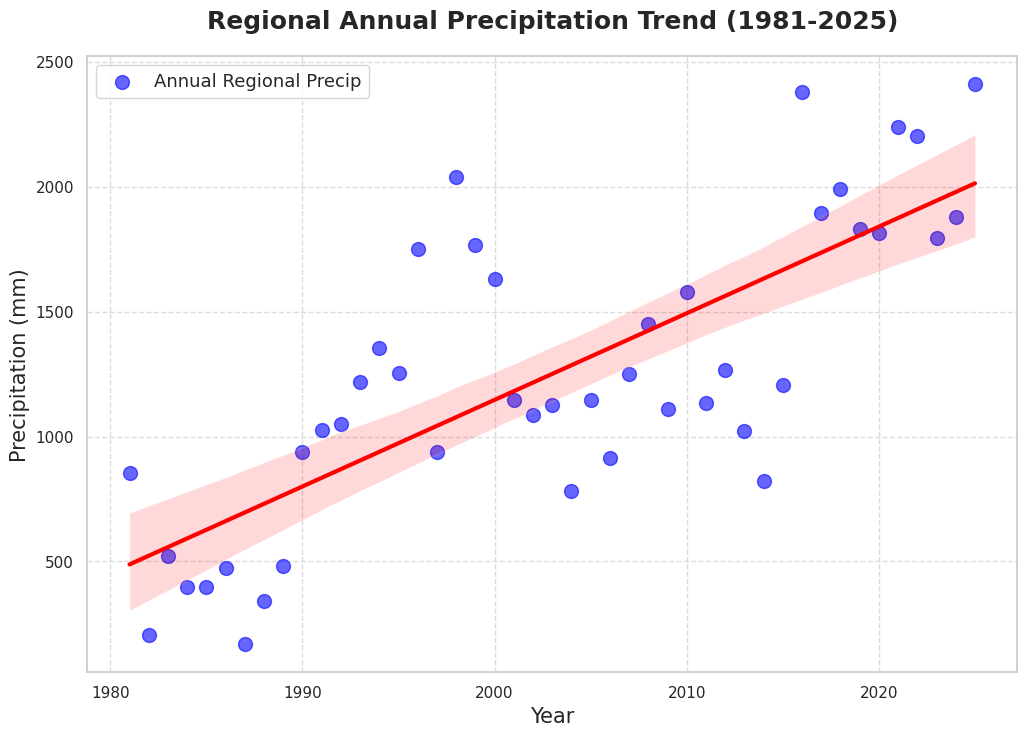

   💾 Saved high-res image: Trend_2_Temperature.png


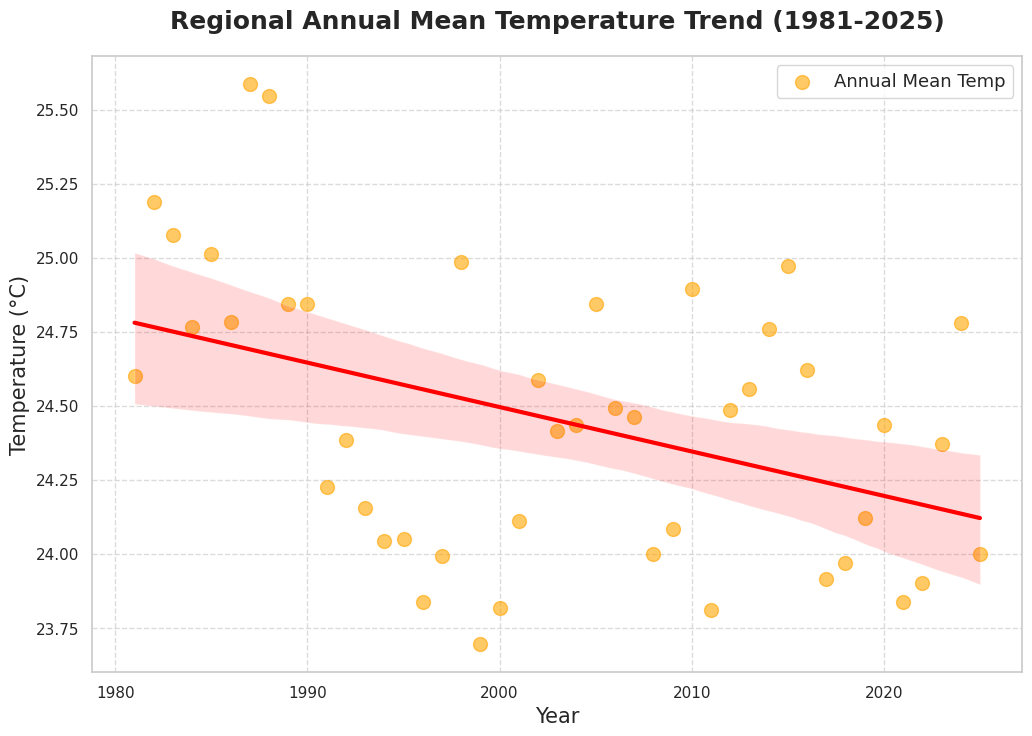

   💾 Saved high-res image: Trend_3_Humidity.png


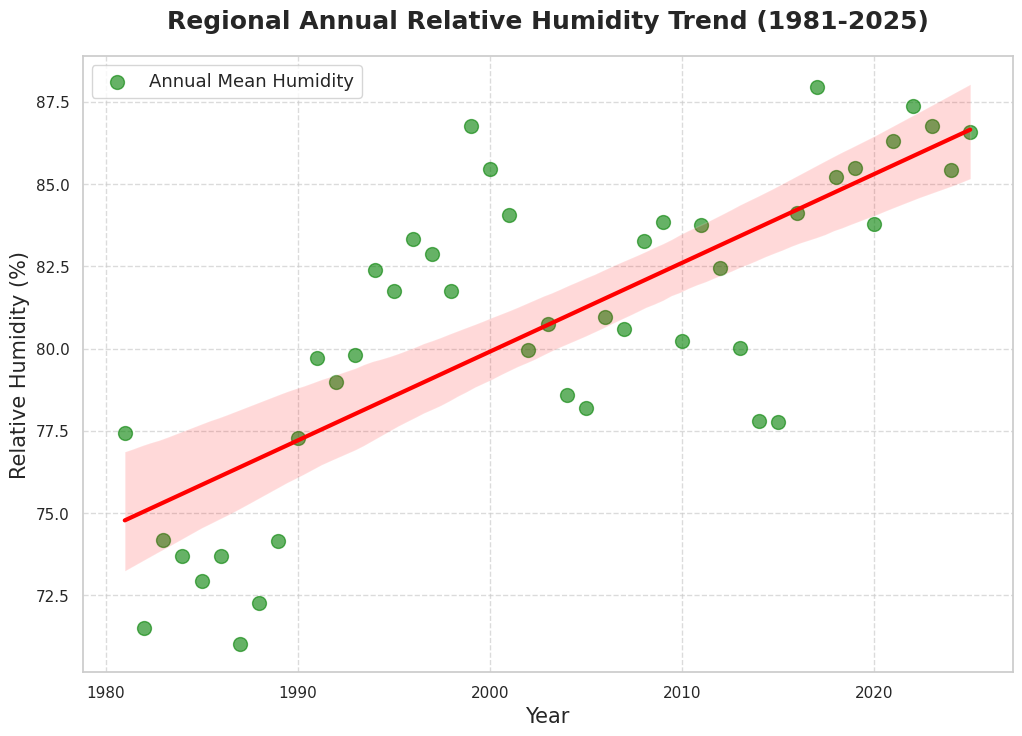


✅ Step 1 Complete. Check the 'Files' tab to download your images.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# ---------------------------------------------------------
# 1. SMART DATA LOADING (Finds .xlsx OR .csv)
# ---------------------------------------------------------
print("🔄 Checking for data files...")

dfs = []
# Look for Excel files first (since you mentioned using xlsx)
excel_files = glob.glob("*.xlsx")
csv_files = glob.glob("*.csv")

if excel_files:
    # If Excel file found, read all sheets
    target_file = excel_files[0]
    print(f"✅ Found Excel file: {target_file}")
    print("   Reading all sheets...")
    xls_data = pd.read_excel(target_file, sheet_name=None)

    for sheet_name, df in xls_data.items():
        dfs.append(df)
        print(f"   -> Loaded sheet: {sheet_name} ({len(df)} rows)")

elif csv_files:
    # If no Excel, look for CSVs
    print(f"✅ Found {len(csv_files)} CSV files. Loading...")
    for fp in csv_files:
        try:
            df = pd.read_csv(fp)
            dfs.append(df)
        except Exception as e:
            print(f"⚠️ Could not read {fp}: {e}")

else:
    # If neither found, stop and alert user
    print("\n❌ ERROR: No files found!")
    print("👉 Please upload 'datatoshafi.xlsx' to the 'Files' tab on the left.")
    raise FileNotFoundError("No .xlsx or .csv files found in the Colab environment.")

if not dfs:
    raise ValueError("File was empty or could not be loaded.")

# Combine all data
combined_df = pd.concat(dfs, ignore_index=True)
print(f"✅ Successfully combined {len(combined_df)} records.")

# ---------------------------------------------------------
# 2. DATA AGGREGATION (Step 1 Logic)
# ---------------------------------------------------------
# Group by YEAR and Location first (Annual Totals per Station)
station_annual = combined_df.groupby(['YEAR', 'Location']).agg({
    'Precipitation': 'sum',
    't2m': 'mean',
    'RelativeHumidityat2m': 'mean'
}).reset_index()

# Group by YEAR (Regional Average of the 3 stations)
regional_trends = station_annual.groupby('YEAR').agg({
    'Precipitation': 'mean',
    't2m': 'mean',
    'RelativeHumidityat2m': 'mean'
}).reset_index()

# ---------------------------------------------------------
# 3. HIGH-RES VISUALIZATION (12x8, 600 DPI)
# ---------------------------------------------------------
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 14})

def save_high_res_plot(filename, title, xlabel, ylabel):
    plt.title(title, fontsize=18, fontweight='bold', pad=20)
    plt.xlabel(xlabel, fontsize=15)
    plt.ylabel(ylabel, fontsize=15)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=13)
    # Save as PNG, 600 DPI
    plt.savefig(filename, dpi=600, bbox_inches='tight', format='png')
    print(f"   💾 Saved high-res image: {filename}")
    plt.show()

print("\n📊 Generating Step 1 Trend Plots...")

# Plot 1: Precipitation Trend
plt.figure(figsize=(12, 8))
sns.regplot(data=regional_trends, x='YEAR', y='Precipitation',
            scatter_kws={'s': 100, 'color': 'blue', 'alpha': 0.6},
            line_kws={'color': 'red', 'linewidth': 3},
            label='Annual Regional Precip')
save_high_res_plot('Trend_1_Precipitation.png',
                   'Regional Annual Precipitation Trend (1981-2025)',
                   'Year', 'Precipitation (mm)')

# Plot 2: Temperature Trend
plt.figure(figsize=(12, 8))
sns.regplot(data=regional_trends, x='YEAR', y='t2m',
            scatter_kws={'s': 100, 'color': 'orange', 'alpha': 0.6},
            line_kws={'color': 'red', 'linewidth': 3},
            label='Annual Mean Temp')
save_high_res_plot('Trend_2_Temperature.png',
                   'Regional Annual Mean Temperature Trend (1981-2025)',
                   'Year', 'Temperature (°C)')

# Plot 3: Humidity Trend
plt.figure(figsize=(12, 8))
sns.regplot(data=regional_trends, x='YEAR', y='RelativeHumidityat2m',
            scatter_kws={'s': 100, 'color': 'green', 'alpha': 0.6},
            line_kws={'color': 'red', 'linewidth': 3},
            label='Annual Mean Humidity')
save_high_res_plot('Trend_3_Humidity.png',
                   'Regional Annual Relative Humidity Trend (1981-2025)',
                   'Year', 'Relative Humidity (%)')

print("\n✅ Step 1 Complete. Check the 'Files' tab to download your images.")

🔄 Scanning for files...
   👉 Found Excel file(s): ['datatoshafi.xlsx']
✅ Successfully loaded 49308 rows from: 3 sources.

📊 Generating Vibrant Plots...
   💾 Saved Image: Trend_Precipitation_Vibrant.png


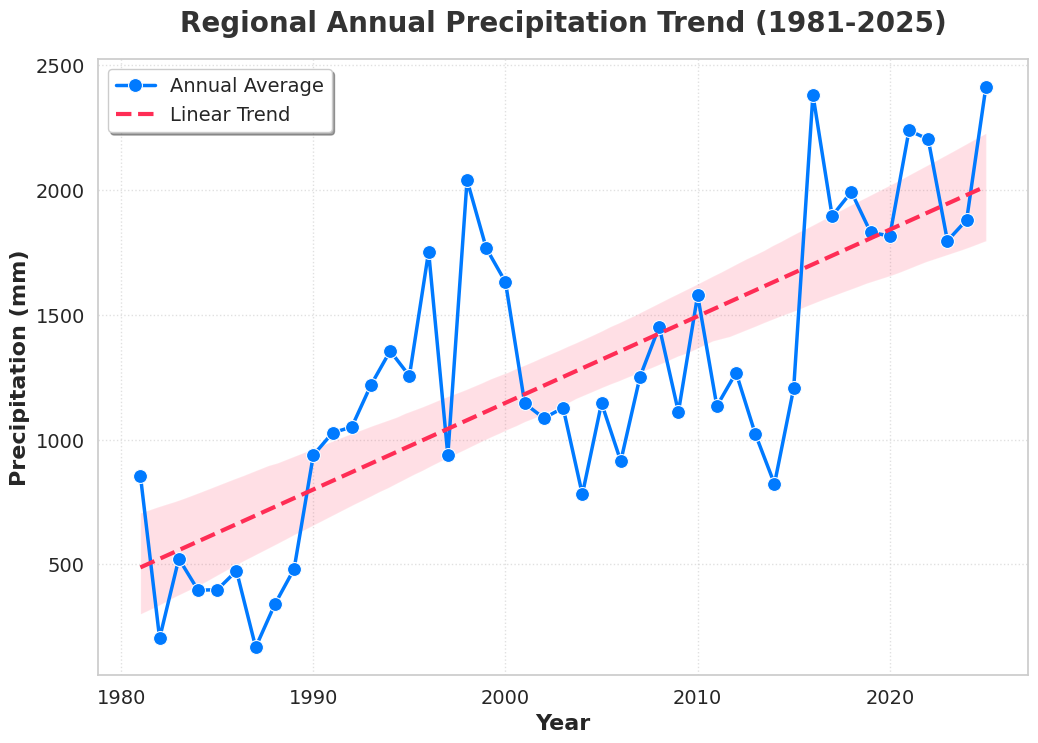

   💾 Saved Image: Trend_Temperature_Vibrant.png


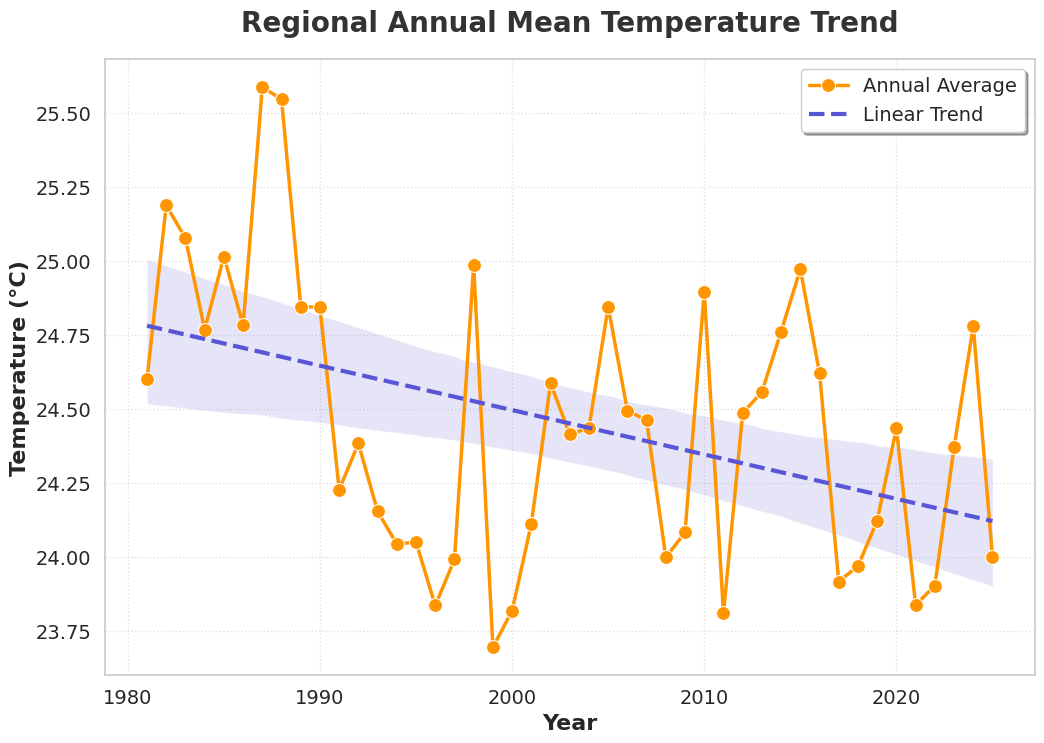

   💾 Saved Image: Trend_Humidity_Vibrant.png


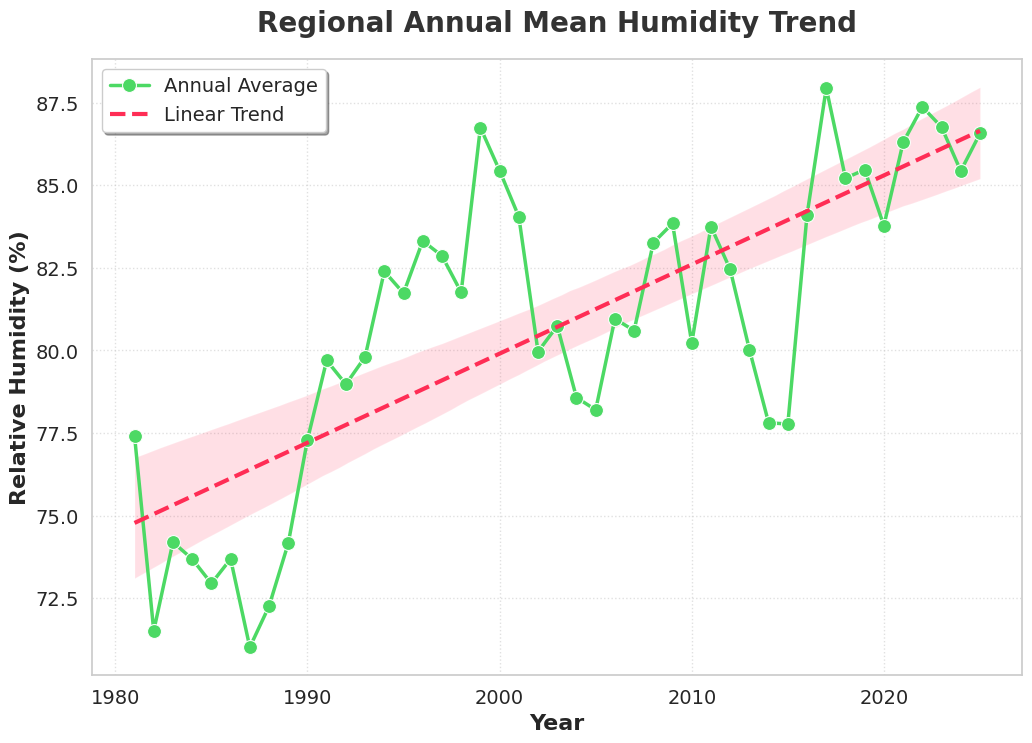


✅ Step 1 Complete! Check the 'Files' folder to download the images.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# ---------------------------------------------------------
# 1. SMART DATA LOADING
# ---------------------------------------------------------
print("🔄 Scanning for files...")

dfs = []
# 1. Try finding the specific Excel file first
excel_files = glob.glob("*.xlsx")
# 2. Try finding ANY CSV files
csv_files = glob.glob("*.csv")

loaded_files = []

# Strategy: Load Excel if exists, otherwise load all CSVs found
if excel_files:
    print(f"   👉 Found Excel file(s): {excel_files}")
    for f in excel_files:
        try:
            # Read all sheets
            sheets_dict = pd.read_excel(f, sheet_name=None)
            for name, sheet_df in sheets_dict.items():
                dfs.append(sheet_df)
                loaded_files.append(f"{f} - {name}")
        except Exception as e:
            print(f"   ⚠️ Error reading {f}: {e}")

if not dfs and csv_files:
    print(f"   👉 Found CSV file(s): {csv_files}")
    for f in csv_files:
        try:
            df = pd.read_csv(f)
            dfs.append(df)
            loaded_files.append(f)
        except Exception as e:
            print(f"   ⚠️ Error reading {f}: {e}")

if not dfs:
    print("\n❌ CRITICAL ERROR: No data found.")
    print("   Please check the 'Files' tab on the left.")
    print("   Make sure you uploaded 'datatoshafi.xlsx' OR the .csv files.")
    raise FileNotFoundError("No data files found.")

# Combine Data
combined_df = pd.concat(dfs, ignore_index=True)
print(f"✅ Successfully loaded {len(combined_df)} rows from: {len(loaded_files)} sources.")

# ---------------------------------------------------------
# 2. DATA AGGREGATION
# ---------------------------------------------------------
# Group by YEAR and Location first
station_annual = combined_df.groupby(['YEAR', 'Location']).agg({
    'Precipitation': 'sum',
    't2m': 'mean',
    'RelativeHumidityat2m': 'mean'
}).reset_index()

# Group by YEAR (Regional Average)
regional_trends = station_annual.groupby('YEAR').agg({
    'Precipitation': 'mean',
    't2m': 'mean',
    'RelativeHumidityat2m': 'mean'
}).reset_index()

# ---------------------------------------------------------
# 3. HIGH-RES VIBRANT VISUALIZATION
# ---------------------------------------------------------
# Set style and font
sns.set_style("whitegrid")
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 14})

def save_vibrant_plot(x_col, y_col, filename, title, ylabel, color_line, color_trend):
    plt.figure(figsize=(12, 8))

    # 1. The Line Plot (Actual Data)
    sns.lineplot(
        data=regional_trends,
        x=x_col,
        y=y_col,
        marker='o',
        markersize=10,
        color=color_line,
        linewidth=2.5,
        label='Annual Average'
    )

    # 2. The Trend Line (Regression)
    sns.regplot(
        data=regional_trends,
        x=x_col,
        y=y_col,
        scatter=False,
        color=color_trend,
        line_kws={'linewidth': 3, 'linestyle': '--'},
        label='Linear Trend'
    )

    # Styling
    plt.title(title, fontsize=20, fontweight='bold', pad=20, color='#333333')
    plt.xlabel('Year', fontsize=16, fontweight='bold')
    plt.ylabel(ylabel, fontsize=16, fontweight='bold')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14, loc='best', frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.6)

    # Save High Res
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    print(f"   💾 Saved Image: {filename}")
    plt.show()

print("\n📊 Generating Vibrant Plots...")

# Plot 1: Precipitation (Vibrant Blue & Red)
save_vibrant_plot(
    'YEAR', 'Precipitation',
    'Trend_Precipitation_Vibrant.png',
    'Regional Annual Precipitation Trend (1981-2025)',
    'Precipitation (mm)',
    color_line='#007AFF',  # Vibrant Dodger Blue
    color_trend='#FF2D55'  # Vibrant Red/Pink
)

# Plot 2: Temperature (Vibrant Orange & Purple)
save_vibrant_plot(
    'YEAR', 't2m',
    'Trend_Temperature_Vibrant.png',
    'Regional Annual Mean Temperature Trend',
    'Temperature (°C)',
    color_line='#FF9500',  # Vibrant Orange
    color_trend='#5856D6'  # Vibrant Purple
)

# Plot 3: Humidity (Vibrant Green & Magenta)
save_vibrant_plot(
    'YEAR', 'RelativeHumidityat2m',
    'Trend_Humidity_Vibrant.png',
    'Regional Annual Mean Humidity Trend',
    'Relative Humidity (%)',
    color_line='#4CD964',  # Vibrant Green
    color_trend='#FF2D55'  # Vibrant Red
)

print("\n✅ Step 1 Complete! Check the 'Files' folder to download the images.")

🔄 Loading Data...
   👉 Reading Excel file: datatoshafi.xlsx


/tmp/ipython-input-234669725.py:119: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


✅ 3D Ribbon Plot saved as '3D_Climate_Ribbon_Plot.png'. Check Files tab to download.


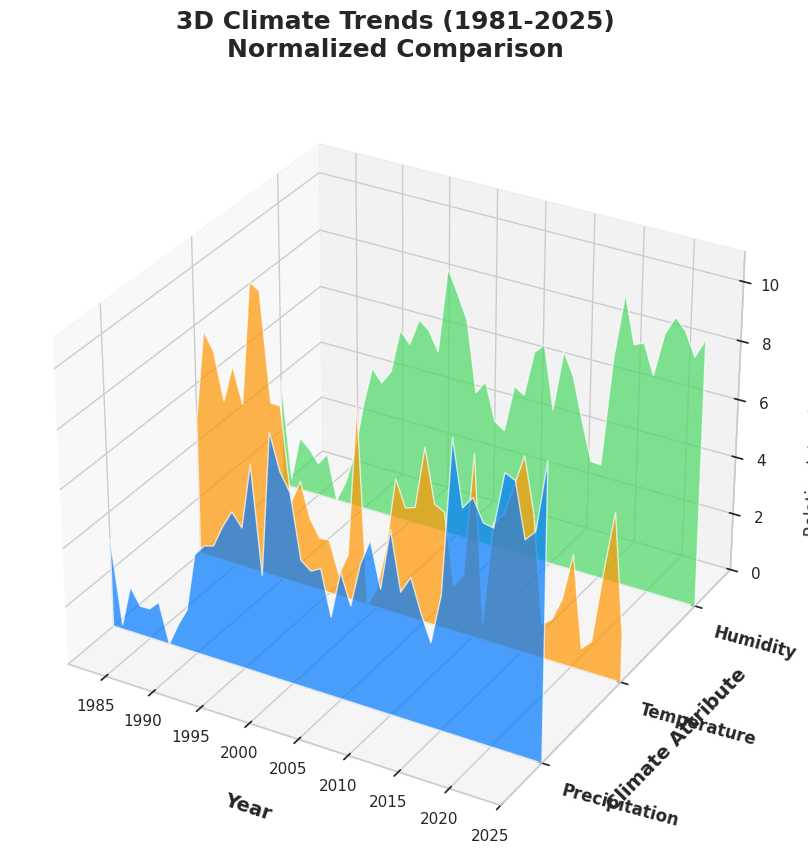

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection
from sklearn.preprocessing import MinMaxScaler
import glob

# ---------------------------------------------------------
# 1. SMART DATA LOADING
# ---------------------------------------------------------
print("🔄 Loading Data...")
dfs = []
excel_files = glob.glob("*.xlsx")
csv_files = glob.glob("*.csv")

if excel_files:
    f = excel_files[0]
    print(f"   👉 Reading Excel file: {f}")
    try:
        sheets_dict = pd.read_excel(f, sheet_name=None)
        for name, sheet_df in sheets_dict.items():
            dfs.append(sheet_df)
    except Exception as e:
        print(f"   ⚠️ Error reading {f}: {e}")
elif csv_files:
    print(f"   👉 Reading CSV files: {csv_files}")
    for f in csv_files:
        try:
            df = pd.read_csv(f)
            dfs.append(df)
        except Exception as e:
            print(f"   ⚠️ Error reading {f}: {e}")
else:
    raise FileNotFoundError("No data found. Please upload 'datatoshafi.xlsx' or CSVs.")

if not dfs:
    raise ValueError("Data loaded but empty.")

combined_df = pd.concat(dfs, ignore_index=True)

# ---------------------------------------------------------
# 2. DATA PROCESSING
# ---------------------------------------------------------
# Calculate Annual Regional Average
station_annual = combined_df.groupby(['YEAR', 'Location']).agg({
    'Precipitation': 'sum',
    't2m': 'mean',
    'RelativeHumidityat2m': 'mean'
}).reset_index()

regional = station_annual.groupby('YEAR').agg({
    'Precipitation': 'mean',
    't2m': 'mean',
    'RelativeHumidityat2m': 'mean'
}).reset_index()

# NORMALIZE DATA (0-10 Scale) for Visual Comparison
# This ensures all ribbons fit nicely in the plot height
scaler = MinMaxScaler(feature_range=(0, 10))
regional_norm = regional.copy()
cols = ['Precipitation', 't2m', 'RelativeHumidityat2m']
regional_norm[cols] = scaler.fit_transform(regional[cols])

# ---------------------------------------------------------
# 3. 3D RIBBON PLOT (WATERFALL STYLE)
# ---------------------------------------------------------
def polygon_under_graph(x, y):
    """Construct the vertex list for the polygon filling the space under the line graph."""
    # Start at y=0, go up to y values, then back down to y=0
    return [(x[0], 0.), *zip(x, y), (x[-1], 0.)]

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

years = regional['YEAR'].values

# Define the 3 ribbons
ribbons = [
    (regional_norm['Precipitation'], 'Precipitation', '#007AFF'), # Blue
    (regional_norm['t2m'],           'Temperature',   '#FF9500'), # Orange
    (regional_norm['RelativeHumidityat2m'], 'Humidity', '#4CD964')  # Green
]

verts = []
colors = []
zs = [0, 1, 2] # Z-positions (Lanes) for the ribbons

for data, label, color in ribbons:
    verts.append(polygon_under_graph(years, data))
    colors.append(color)

# Create the Polygon Collection
poly = PolyCollection(verts, facecolors=colors, alpha=0.7, edgecolors='white', linewidths=1)
ax.add_collection3d(poly, zs=zs, zdir='y')

# Axis Setup
ax.set_xlabel('\nYear', fontsize=14, fontweight='bold', linespacing=3.2)
ax.set_ylabel('\nClimate Attribute', fontsize=14, fontweight='bold', linespacing=3.2)
ax.set_zlabel('\nRelative Intensity (Normalized)', fontsize=12, linespacing=3.2)

# Set Limits
ax.set_xlim(years.min(), years.max())
ax.set_ylim(-0.5, 2.5)
ax.set_zlim(0, 11)

# Custom Y-Axis Labels (The Variable Names)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Precipitation', 'Temperature', 'Humidity'],
                   fontsize=12, fontweight='bold', rotation=-15, ha='left')

# Title
ax.set_title("3D Climate Trends (1981-2025)\nNormalized Comparison", fontsize=18, fontweight='bold', pad=20)

# Set View Angle for best "Waterfall" perspective
ax.view_init(elev=30, azim=-60)

# Save High Res
plt.tight_layout()
filename = '3D_Climate_Ribbon_Plot.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"✅ 3D Ribbon Plot saved as '{filename}'. Check Files tab to download.")
plt.show()

🔄 Loading Data...
   👉 Reading Excel file: datatoshafi.xlsx
✅ Dashboard saved as 'Climate_Dashboard_SinglePage.png'


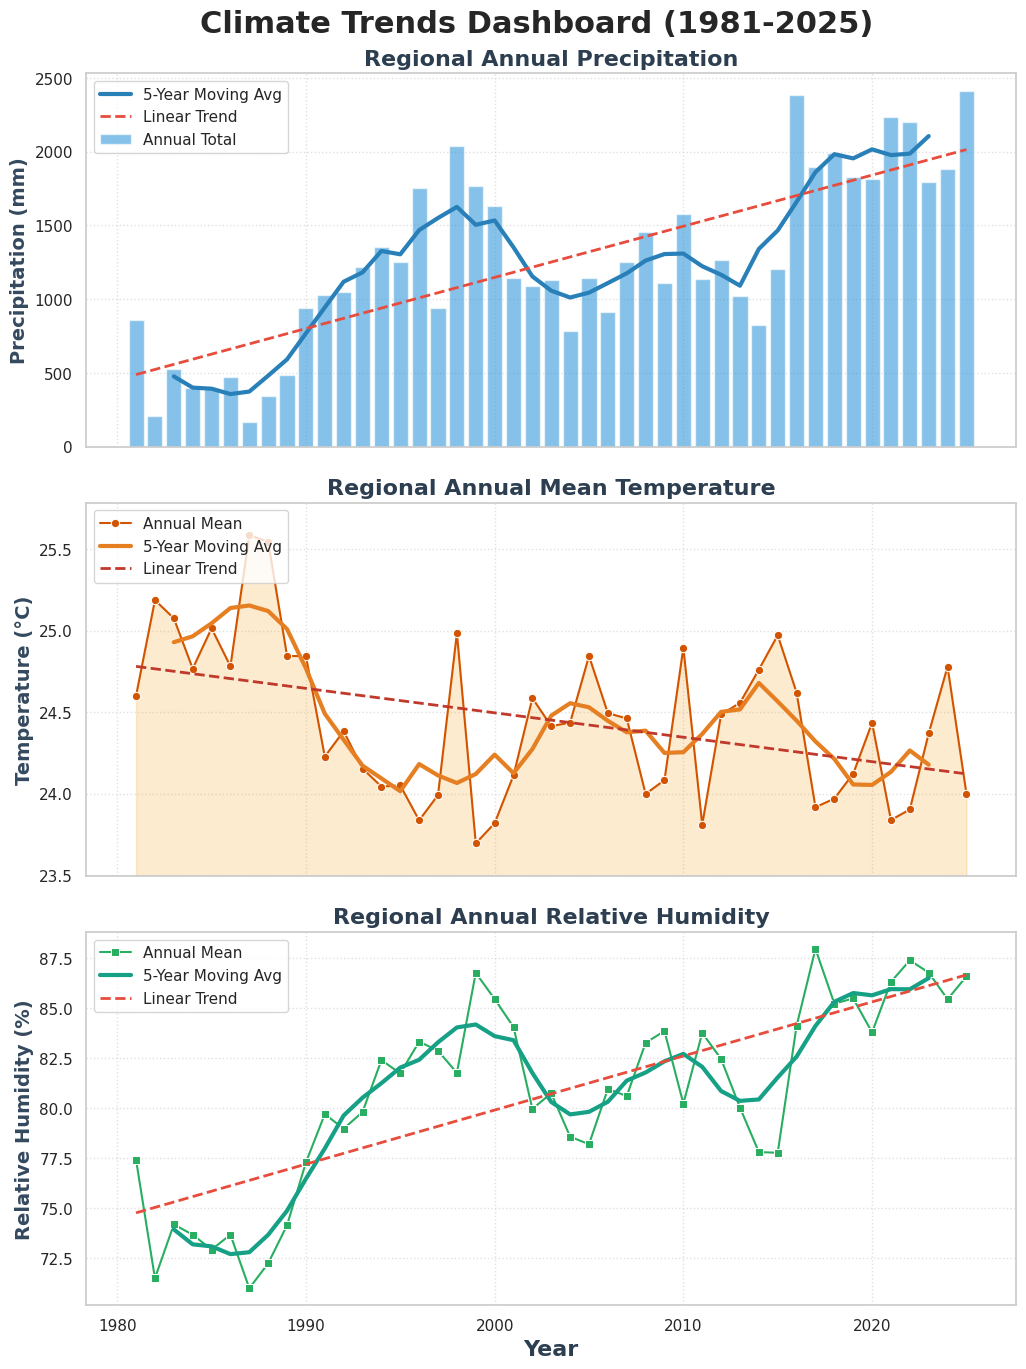

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy import stats

# ---------------------------------------------------------
# 1. SMART DATA LOADING
# ---------------------------------------------------------
print("🔄 Loading Data...")
dfs = []
# Try finding Excel first, then CSVs
excel_files = glob.glob("*.xlsx")
csv_files = glob.glob("*.csv")

if excel_files:
    # Prefer the first Excel file found
    f = excel_files[0]
    print(f"   👉 Reading Excel file: {f}")
    try:
        sheets_dict = pd.read_excel(f, sheet_name=None)
        for name, sheet_df in sheets_dict.items():
            dfs.append(sheet_df)
    except Exception as e:
        print(f"   ⚠️ Error reading {f}: {e}")
elif csv_files:
    # Fallback to CSVs
    print(f"   👉 Reading CSV files: {csv_files}")
    for f in csv_files:
        try:
            df = pd.read_csv(f)
            dfs.append(df)
        except Exception as e:
            print(f"   ⚠️ Error reading {f}: {e}")
else:
    raise FileNotFoundError("No data files found. Please upload 'datatoshafi.xlsx' or CSVs.")

if not dfs:
    raise ValueError("Data loaded but empty.")

combined_df = pd.concat(dfs, ignore_index=True)

# ---------------------------------------------------------
# 2. DATA PROCESSING (Annual & Rolling Avgs)
# ---------------------------------------------------------
# 1. Annual Totals/Means per Station
station_annual = combined_df.groupby(['YEAR', 'Location']).agg({
    'Precipitation': 'sum',
    't2m': 'mean',
    'RelativeHumidityat2m': 'mean'
}).reset_index()

# 2. Regional Average (Mean of 3 stations)
regional = station_annual.groupby('YEAR').agg({
    'Precipitation': 'mean',
    't2m': 'mean',
    'RelativeHumidityat2m': 'mean'
}).reset_index()

# 3. Calculate 5-Year Rolling Averages (Smooth Trend)
regional['Precip_Roll'] = regional['Precipitation'].rolling(window=5, center=True).mean()
regional['Temp_Roll'] = regional['t2m'].rolling(window=5, center=True).mean()
regional['Hum_Roll'] = regional['RelativeHumidityat2m'].rolling(window=5, center=True).mean()

# ---------------------------------------------------------
# 3. DASHBOARD VISUALIZATION
# ---------------------------------------------------------
# Setup Figure: 3 Rows, 1 Column
fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=True)
plt.subplots_adjust(hspace=0.15) # Tight layout

# Styling Constants
sns.set_style("whitegrid")
years = regional['YEAR']
title_font = {'fontsize': 16, 'fontweight': 'bold', 'color': '#2c3e50'}
label_font = {'fontsize': 14, 'fontweight': 'bold', 'color': '#34495e'}

# --- SUBPLOT 1: PRECIPITATION (Bars + Trend) ---
ax1 = axes[0]
# Bars for annual totals
ax1.bar(years, regional['Precipitation'], color='#3498db', alpha=0.6, label='Annual Total', width=0.8)
# Rolling Avg
ax1.plot(years, regional['Precip_Roll'], color='#2980b9', linewidth=3, label='5-Year Moving Avg')
# Linear Trend
slope, intercept, _, _, _ = stats.linregress(years, regional['Precipitation'])
ax1.plot(years, slope*years + intercept, color='#e74c3c', linewidth=2, linestyle='--', label=f'Linear Trend')

ax1.set_ylabel('Precipitation (mm)', **label_font)
ax1.set_title('Regional Annual Precipitation', **title_font)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

# --- SUBPLOT 2: TEMPERATURE (Area + Trend) ---
ax2 = axes[1]
# Fill Area
ax2.fill_between(years, regional['t2m'], regional['t2m'].min()-0.5, color='#f39c12', alpha=0.2)
# Line
sns.lineplot(x=years, y=regional['t2m'], ax=ax2, color='#d35400', marker='o', label='Annual Mean', linewidth=1.5)
# Rolling Avg
ax2.plot(years, regional['Temp_Roll'], color='#e67e22', linewidth=3, label='5-Year Moving Avg')
# Linear Trend
slope, intercept, _, _, _ = stats.linregress(years, regional['t2m'])
ax2.plot(years, slope*years + intercept, color='#c0392b', linewidth=2, linestyle='--', label=f'Linear Trend')

ax2.set_ylabel('Temperature (°C)', **label_font)
ax2.set_title('Regional Annual Mean Temperature', **title_font)
ax2.set_ylim(regional['t2m'].min() - 0.2, regional['t2m'].max() + 0.2)
ax2.legend(loc='upper left', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

# --- SUBPLOT 3: HUMIDITY (Line + Trend) ---
ax3 = axes[2]
sns.lineplot(x=years, y=regional['RelativeHumidityat2m'], ax=ax3, color='#27ae60', marker='s', label='Annual Mean', linewidth=1.5)
# Rolling Avg
ax3.plot(years, regional['Hum_Roll'], color='#16a085', linewidth=3, label='5-Year Moving Avg')
# Linear Trend
slope, intercept, _, _, _ = stats.linregress(years, regional['RelativeHumidityat2m'])
ax3.plot(years, slope*years + intercept, color='#e74c3c', linewidth=2, linestyle='--', label=f'Linear Trend')

ax3.set_ylabel('Relative Humidity (%)', **label_font)
ax3.set_title('Regional Annual Relative Humidity', **title_font)
ax3.set_xlabel('Year', **title_font)
ax3.legend(loc='upper left', frameon=True)
ax3.grid(True, linestyle=':', alpha=0.6)

# Final Touches
fig.suptitle('Climate Trends Dashboard (1981-2025)', fontsize=22, fontweight='bold', y=0.92)

# Save High Res
plt.savefig('Climate_Dashboard_SinglePage.png', dpi=300, bbox_inches='tight')
print("✅ Dashboard saved as 'Climate_Dashboard_SinglePage.png'")
plt.show()

In [ ]:
!pip install pymannkendall


In [ ]:

!pip install openpyxl


In [ ]:
df = pd.read_excel("datatoshafi.xlsx", engine="openpyxl")


In [ ]:
xls = pd.ExcelFile("datatoshafi.xlsx")
print(xls.sheet_names)


['Phan ', 'Thuận', 'Ninh']


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import pymannkendall as mk

df = pd.read_excel("datatoshafi.xlsx", engine="openpyxl")

print(df.head())


              Location         Climate  YEAR  DOY  Precipitation  \
0  Phan Rang-Tháp Chàm  Drought Center  1981    1            0.0   
1  Phan Rang-Tháp Chàm  Drought Center  1981    2            0.0   
2  Phan Rang-Tháp Chàm  Drought Center  1981    3            0.0   
3  Phan Rang-Tháp Chàm  Drought Center  1981    4            0.0   
4  Phan Rang-Tháp Chàm  Drought Center  1981    5            0.0   

   RelativeHumidityat2m  tmin2m  tmax2m    t2m  
0                 75.98   20.77   26.79  22.95  
1                 77.00   21.34   26.35  23.24  
2                 74.88   21.08   26.70  23.01  
3                 74.41   21.05   27.17  23.32  
4                 71.88   20.48   28.27  23.58  


===== Mann-Kendall Test Results =====
Trend: decreasing
Tau: -0.23434343434343435
p-value: 0.023838891030700138
Z-value: -2.2597158647656754
Sen's Slope: -0.011186595027545413


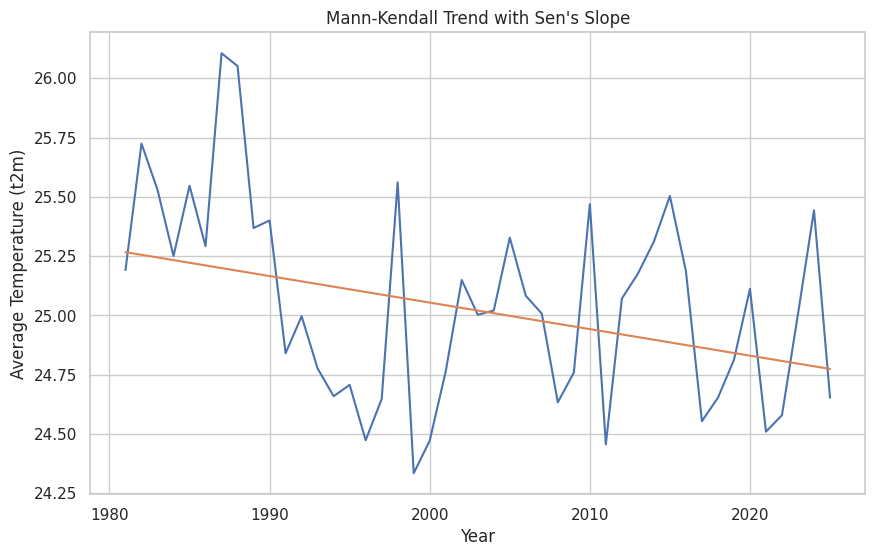

In [ ]:
# Combine all locations yearly average of t2m
yearly = df.groupby("YEAR")["t2m"].mean().reset_index()

# Mann-Kendall test
result = mk.original_test(yearly["t2m"])

print("===== Mann-Kendall Test Results =====")
print("Trend:", result.trend)
print("Tau:", result.Tau)
print("p-value:", result.p)
print("Z-value:", result.z)
print("Sen's Slope:", result.slope)

# Sen slope line
sen_slope = result.slope
intercept = yearly["t2m"].median() - sen_slope * yearly["YEAR"].median()
trend_line = intercept + sen_slope * yearly["YEAR"]

# Plot
plt.figure(figsize=(10,6))
plt.plot(yearly["YEAR"], yearly["t2m"])
plt.plot(yearly["YEAR"], trend_line)
plt.xlabel("Year")
plt.ylabel("Average Temperature (t2m)")
plt.title("Mann-Kendall Trend with Sen's Slope")
plt.show()


In [ ]:
print(df["Location"].unique())
print(len(df["Location"].unique()))


['Phan Rang-Tháp Chàm']
1


In [ ]:
import numpy as np
from statsmodels.tsa.stattools import acf

series = yearly["t2m"].values
lag1 = acf(series, nlags=1)[1]

print("Lag-1 Autocorrelation:", lag1)



Lag-1 Autocorrelation: 0.41843996126435185


In [ ]:
import pymannkendall as mk

result_mod = mk.hamed_rao_modification_test(yearly["t2m"])

print("===== Modified Mann-Kendall Test =====")
print("Trend:", result_mod.trend)
print("Tau:", result_mod.Tau)
print("p-value:", result_mod.p)
print("Z-value:", result_mod.z)
print("Sen's Slope:", result_mod.slope)
print("Lower CI:", result_mod.slope_confidence_interval[0])
print("Upper CI:", result_mod.slope_confidence_interval[1])


===== Modified Mann-Kendall Test =====
Trend: no trend
Tau: -0.23434343434343435
p-value: 0.069177265623523
Z-value: -1.8172603007211237
Sen's Slope: -0.011186595027545413


AttributeError: 'Modified_Mann_Kendall_Test_Hamed_Rao_Approach' object has no attribute 'slope_confidence_interval'

In [ ]:
import numpy as np
from scipy.stats import theilslopes

# Extract series
years = yearly["YEAR"].values
values = yearly["t2m"].values

# Theil-Sen slope with CI
slope, intercept, lower, upper = theilslopes(values, years, 0.95)

print("Sen's Slope:", slope)
print("95% CI Lower:", lower)
print("95% CI Upper:", upper)


Sen's Slope: -0.011186595027545413
95% CI Lower: -0.021779135164807666
95% CI Upper: -0.0014401826484018443


In [ ]:
import pandas as pd

df = pd.read_excel("datatoshafi.xlsx")

print("Shape:", df.shape)
print("Years:", df["YEAR"].min(), "-", df["YEAR"].max())
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())


Shape: (16436, 9)
Years: 1981 - 2025
Missing values:
 Location                0
Climate                 0
YEAR                    0
DOY                     0
Precipitation           0
RelativeHumidityat2m    0
tmin2m                  0
tmax2m                  0
t2m                     0
dtype: int64
Duplicate rows: 0


In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
YEAR,16436.0,2003.000669,12.987371,1981.00,1992.00,2003.00,2014.00,2025.00
DOY,16436.0,183.122475,105.440240,1.00,92.00,183.00,274.00,366.00
Precipitation,16436.0,3.484709,7.549544,0.00,0.02,0.63,3.71,153.10
RelativeHumidityat2m,16436.0,80.670609,6.885692,53.83,75.41,81.38,86.24,96.08
tmin2m,16436.0,22.420121,1.842535,14.59,21.28,22.91,23.76,26.56
tmax2m,16436.0,28.791197,2.156348,20.64,27.28,28.73,30.24,35.61
t2m,16436.0,25.048624,1.705823,17.99,23.96,25.27,26.21,29.94


In [ ]:
df.describe().T.to_csv("descriptive_statistics.csv")


In [ ]:
import pandas as pd

file = "datatoshafi.xlsx"

# Read all sheets into dictionary
all_sheets = pd.read_excel(file, sheet_name=None)

print("Sheet names:", list(all_sheets.keys()))


Sheet names: ['Phan ', 'Thuận', 'Ninh']


In [ ]:
# Combine all sheets vertically
df_combined = pd.concat(all_sheets.values(), ignore_index=True)

print("Combined shape:", df_combined.shape)
print(df_combined.head())


Combined shape: (49308, 9)
              Location         Climate  YEAR  DOY  Precipitation  \
0  Phan Rang-Tháp Chàm  Drought Center  1981    1            0.0   
1  Phan Rang-Tháp Chàm  Drought Center  1981    2            0.0   
2  Phan Rang-Tháp Chàm  Drought Center  1981    3            0.0   
3  Phan Rang-Tháp Chàm  Drought Center  1981    4            0.0   
4  Phan Rang-Tháp Chàm  Drought Center  1981    5            0.0   

   RelativeHumidityat2m  tmin2m  tmax2m    t2m  
0                 75.98   20.77   26.79  22.95  
1                 77.00   21.34   26.35  23.24  
2                 74.88   21.08   26.70  23.01  
3                 74.41   21.05   27.17  23.32  
4                 71.88   20.48   28.27  23.58  


In [ ]:
# Remove duplicates
df_combined = df_combined.drop_duplicates()

# Check missing values
print("Missing values:\n", df_combined.isnull().sum())

# Ensure YEAR is numeric
df_combined["YEAR"] = pd.to_numeric(df_combined["YEAR"])


Missing values:
 Location                0
Climate                 0
YEAR                    0
DOY                     0
Precipitation           0
RelativeHumidityat2m    0
tmin2m                  0
tmax2m                  0
t2m                     0
dtype: int64


In [ ]:
yearly = df_combined.groupby("YEAR").agg({
    "t2m": "mean",
    "Precipitation": "sum",
    "RelativeHumidityat2m": "mean"
}).reset_index()

yearly.head()


,YEAR,t2m,Precipitation,RelativeHumidityat2m
0,1981,24.600922,2567.38,77.419123
1,1982,25.187269,614.39,71.511963
2,1983,25.075982,1569.43,74.196411
3,1984,24.767341,1191.17,73.687067
4,1985,25.014329,1196.46,72.944247


In [ ]:
import pymannkendall as mk

for var in ["t2m", "Precipitation", "RelativeHumidityat2m"]:
    result = mk.hamed_rao_modification_test(yearly[var])
    print(f"\n===== {var} =====")
    print("Trend:", result.trend)
    print("p-value:", result.p)
    print("Sen's slope:", result.slope)



===== t2m =====
Trend: decreasing
p-value: 0.0410829582243637
Sen's slope: -0.013740021488047288

===== Precipitation =====
Trend: increasing
p-value: 1.941951055117741e-05
Sen's slope: 107.77355957767722

===== RelativeHumidityat2m =====
Trend: increasing
p-value: 0.00028532597715269503
Sen's slope: 0.2731761802973723


In [ ]:
corr = yearly[["t2m", "Precipitation", "RelativeHumidityat2m"]].corr()
print("\nCorrelation Matrix:\n", corr)



Correlation Matrix:
                            t2m  Precipitation  RelativeHumidityat2m
t2m                   1.000000      -0.604922             -0.819211
Precipitation        -0.604922       1.000000              0.889513
RelativeHumidityat2m -0.819211       0.889513              1.000000


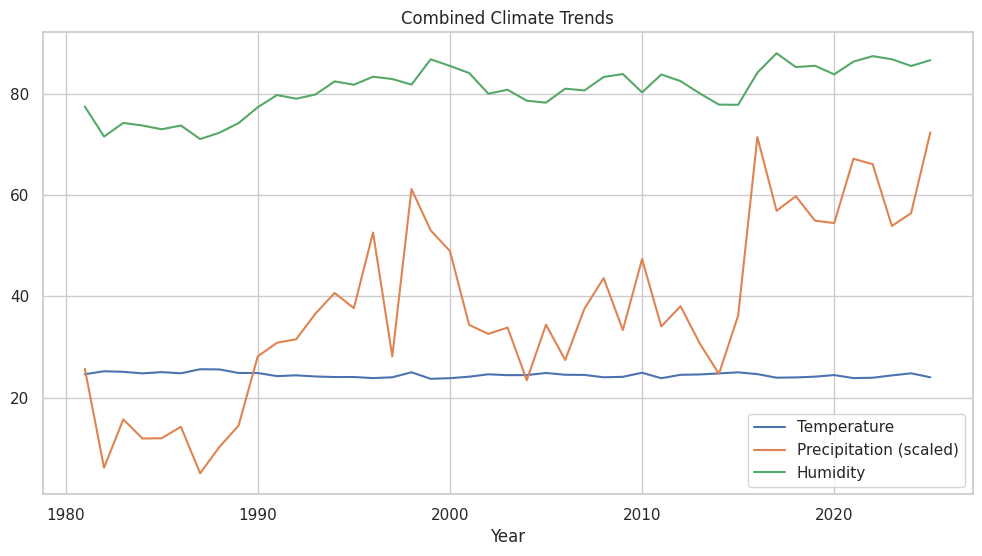

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(yearly["YEAR"], yearly["t2m"], label="Temperature")
plt.plot(yearly["YEAR"], yearly["Precipitation"]/100, label="Precipitation (scaled)")
plt.plot(yearly["YEAR"], yearly["RelativeHumidityat2m"], label="Humidity")

plt.legend()
plt.title("Combined Climate Trends")
plt.xlabel("Year")
plt.show()


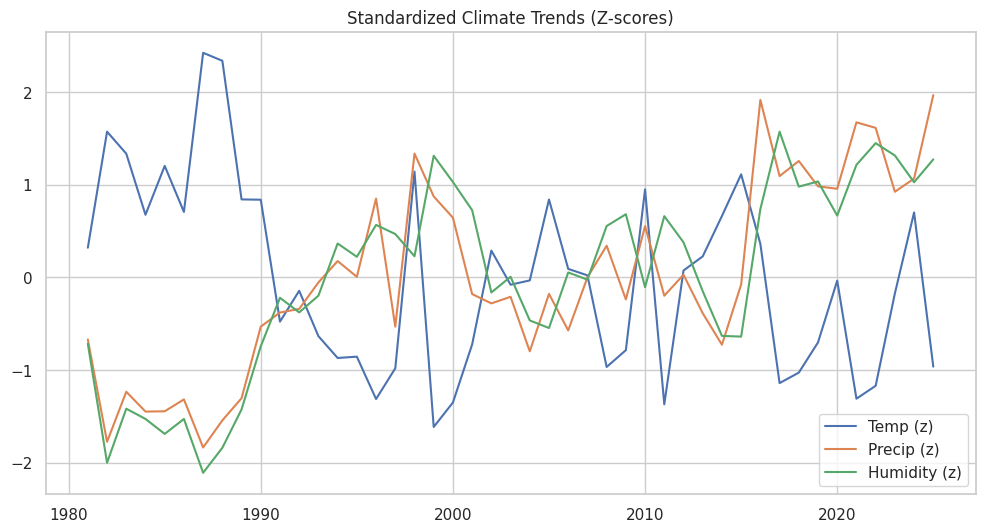

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(yearly[["t2m", "Precipitation", "RelativeHumidityat2m"]])

scaled_df = pd.DataFrame(scaled, columns=["Temp_z", "Prec_z", "Hum_z"])
scaled_df["YEAR"] = yearly["YEAR"]

plt.figure(figsize=(12,6))
plt.plot(scaled_df["YEAR"], scaled_df["Temp_z"], label="Temp (z)")
plt.plot(scaled_df["YEAR"], scaled_df["Prec_z"], label="Precip (z)")
plt.plot(scaled_df["YEAR"], scaled_df["Hum_z"], label="Humidity (z)")
plt.legend()
plt.title("Standardized Climate Trends (Z-scores)")
plt.show()


In [ ]:
import pandas as pd

file = "datatoshafi.xlsx"

# Read all sheets
all_sheets = pd.read_excel(file, sheet_name=None)

# Stack all sheets vertically
df = pd.concat(all_sheets.values(), ignore_index=True)

print("Final Shape:", df.shape)
print(df.head())


Final Shape: (49308, 9)
              Location         Climate  YEAR  DOY  Precipitation  \
0  Phan Rang-Tháp Chàm  Drought Center  1981    1            0.0   
1  Phan Rang-Tháp Chàm  Drought Center  1981    2            0.0   
2  Phan Rang-Tháp Chàm  Drought Center  1981    3            0.0   
3  Phan Rang-Tháp Chàm  Drought Center  1981    4            0.0   
4  Phan Rang-Tháp Chàm  Drought Center  1981    5            0.0   

   RelativeHumidityat2m  tmin2m  tmax2m    t2m  
0                 75.98   20.77   26.79  22.95  
1                 77.00   21.34   26.35  23.24  
2                 74.88   21.08   26.70  23.01  
3                 74.41   21.05   27.17  23.32  
4                 71.88   20.48   28.27  23.58  


In [ ]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49308 entries, 0 to 49307
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Location              49308 non-null  object 
 1   Climate               49308 non-null  object 
 2   YEAR                  49308 non-null  int64  
 3   DOY                   49308 non-null  int64  
 4   Precipitation         49308 non-null  float64
 5   RelativeHumidityat2m  49308 non-null  float64
 6   tmin2m                49308 non-null  float64
 7   tmax2m                49308 non-null  float64
 8   t2m                   49308 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 3.4+ MB
None

Missing values:
 Location                0
Climate                 0
YEAR                    0
DOY                     0
Precipitation           0
RelativeHumidityat2m    0
tmin2m                  0
tmax2m                  0
t2m                     0
dtype: int64

In [ ]:
def outlier_count(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

for col in ["t2m", "Precipitation", "RelativeHumidityat2m", "tmin2m", "tmax2m"]:
    print(f"{col} outliers:", outlier_count(df[col]))


t2m outliers: 751
Precipitation outliers: 5706
RelativeHumidityat2m outliers: 133
tmin2m outliers: 727
tmax2m outliers: 390


In [ ]:
from scipy.stats import shapiro

for col in ["t2m", "Precipitation", "RelativeHumidityat2m"]:
    stat, p = shapiro(df[col])
    print(f"{col} Shapiro p-value:", p)


t2m Shapiro p-value: 3.421133829576929e-65
Precipitation Shapiro p-value: 1.2966706078048687e-143
RelativeHumidityat2m Shapiro p-value: 5.342794618301962e-63


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 49308.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
yearly = df.groupby("YEAR").agg({
    "t2m": "mean",
    "Precipitation": "sum",
    "RelativeHumidityat2m": "mean"
}).reset_index()

print(yearly.head())


   YEAR        t2m  Precipitation  RelativeHumidityat2m
0  1981  24.600922        2567.38             77.419123
1  1982  25.187269         614.39             71.511963
2  1983  25.075982        1569.43             74.196411
3  1984  24.767341        1191.17             73.687067
4  1985  25.014329        1196.46             72.944247


In [ ]:
from statsmodels.tsa.stattools import acf

for col in ["t2m", "Precipitation", "RelativeHumidityat2m"]:
    lag1 = acf(yearly[col], nlags=1)[1]
    print(f"{col} Lag-1 Autocorrelation:", lag1)


t2m Lag-1 Autocorrelation: 0.4689544013472035
Precipitation Lag-1 Autocorrelation: 0.7292469894175148
RelativeHumidityat2m Lag-1 Autocorrelation: 0.8376945130874275


In [ ]:
import pymannkendall as mk
from scipy.stats import theilslopes

results = []

for col in ["t2m", "Precipitation", "RelativeHumidityat2m"]:

    # Modified MK
    mk_result = mk.hamed_rao_modification_test(yearly[col])

    # Theil-Sen slope + CI
    slope, intercept, lower, upper = theilslopes(
        yearly[col].values, yearly["YEAR"].values, 0.95
    )

    results.append({
        "Variable": col,
        "Trend": mk_result.trend,
        "MK p-value": mk_result.p,
        "Tau": mk_result.Tau,
        "Sen Slope": slope,
        "CI Lower": lower,
        "CI Upper": upper
    })

final_results = pd.DataFrame(results)
print("\n===== FINAL TREND RESULTS =====")
print(final_results)



===== FINAL TREND RESULTS =====
               Variable       Trend  MK p-value       Tau   Sen Slope  \
0                   t2m  decreasing    0.041083 -0.266667   -0.013740   
1         Precipitation  increasing    0.000019  0.551515  107.773560   
2  RelativeHumidityat2m  increasing    0.000285  0.555556    0.273176   

    CI Lower    CI Upper  
0  -0.025776   -0.003441  
1  77.456970  136.185455  
2   0.198999    0.353484  


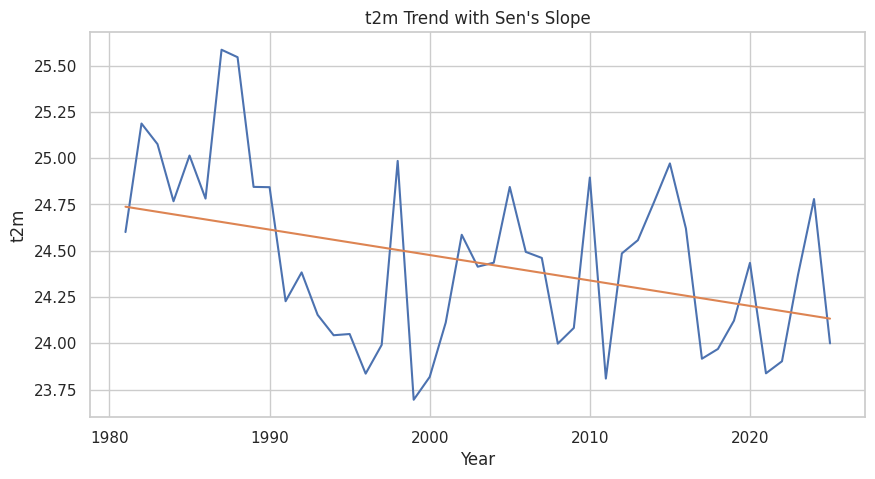

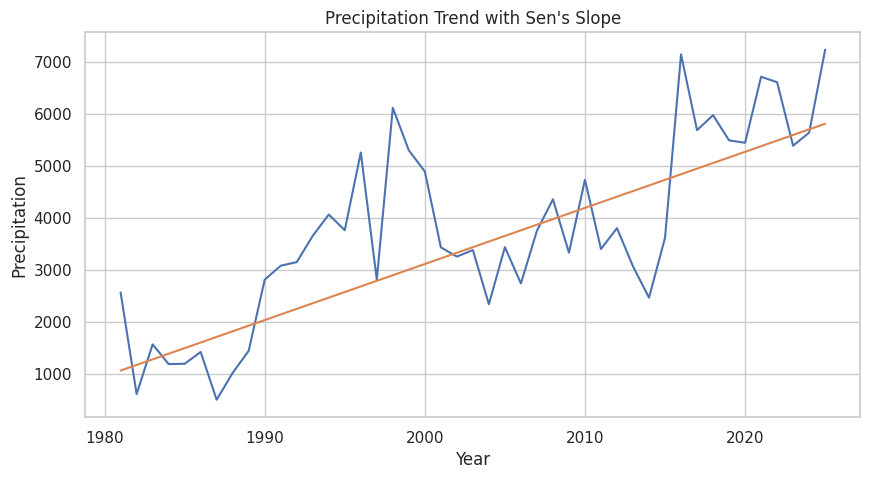

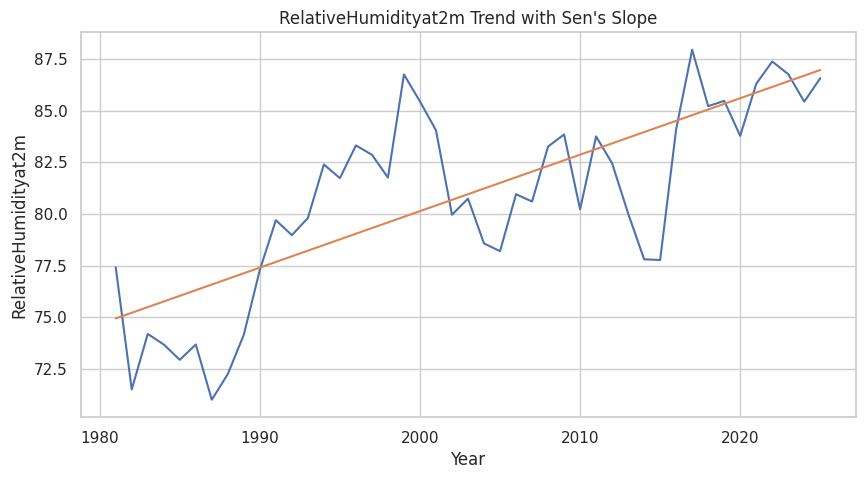

In [ ]:
import matplotlib.pyplot as plt

for col in ["t2m", "Precipitation", "RelativeHumidityat2m"]:

    plt.figure(figsize=(10,5))
    plt.plot(yearly["YEAR"], yearly[col])

    slope, intercept, _, _ = theilslopes(
        yearly[col].values, yearly["YEAR"].values
    )

    trend_line = intercept + slope * yearly["YEAR"]
    plt.plot(yearly["YEAR"], trend_line)

    plt.title(f"{col} Trend with Sen's Slope")
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.show()


In [ ]:
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes

# Load and combine all sheets
file = "datatoshafi.xlsx"
all_sheets = pd.read_excel(file, sheet_name=None)
df = pd.concat(all_sheets.values(), ignore_index=True)

# Yearly aggregation
yearly = df.groupby("YEAR").agg({
    "t2m": "mean",
    "Precipitation": "sum",
    "RelativeHumidityat2m": "mean"
}).reset_index()

variables = ["t2m", "Precipitation", "RelativeHumidityat2m"]

results = []

for var in variables:

    # Modified Mann-Kendall
    mk_result = mk.hamed_rao_modification_test(yearly[var])

    # Sen’s slope + 95% CI (Theil-Sen robust estimator)
    slope, intercept, lower, upper = theilslopes(
        yearly[var].values,
        yearly["YEAR"].values,
        0.95
    )

    results.append({
        "Variable": var,
        "Trend": mk_result.trend,
        "MK p-value": mk_result.p,
        "Z-value": mk_result.z,
        "Tau": mk_result.Tau,
        "Sen Slope": slope,
        "CI Lower": lower,
        "CI Upper": upper
    })

final_results = pd.DataFrame(results)

print("\n===== MODIFIED MANN-KENDALL RESULTS =====")
print(final_results)



===== MODIFIED MANN-KENDALL RESULTS =====
               Variable       Trend  MK p-value   Z-value       Tau  \
0                   t2m  decreasing    0.041083 -2.042692 -0.266667   
1         Precipitation  increasing    0.000019  4.271463  0.551515   
2  RelativeHumidityat2m  increasing    0.000285  3.628271  0.555556   

    Sen Slope   CI Lower    CI Upper  
0   -0.013740  -0.025776   -0.003441  
1  107.773560  77.456970  136.185455  
2    0.273176   0.198999    0.353484  


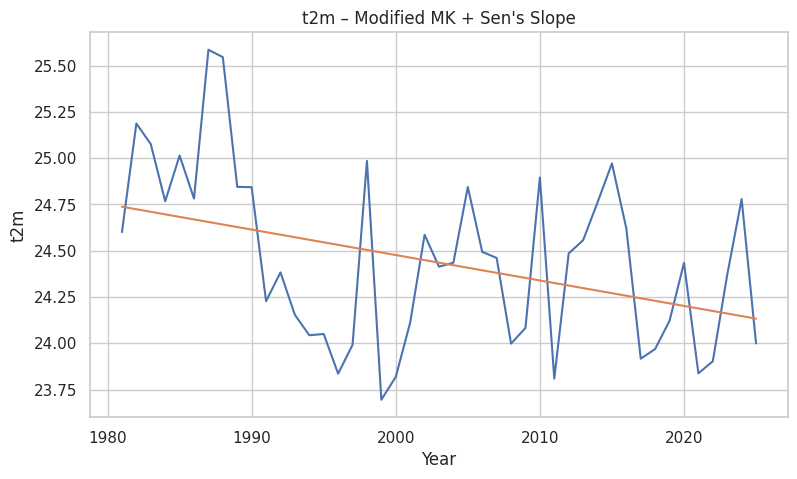

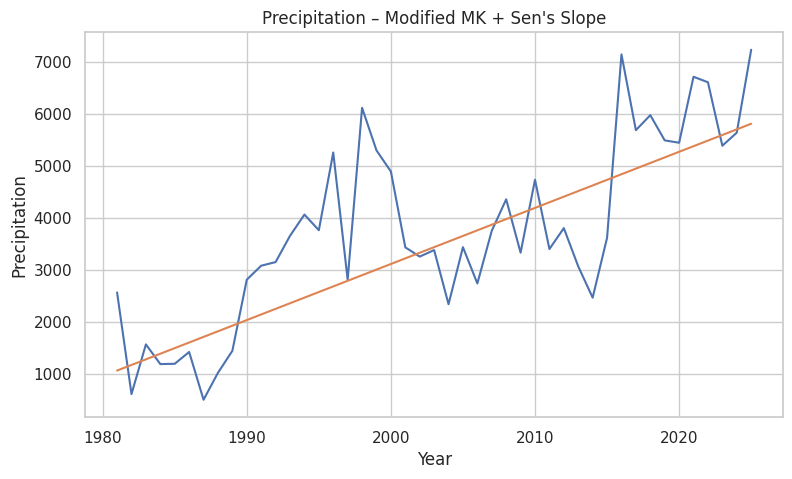

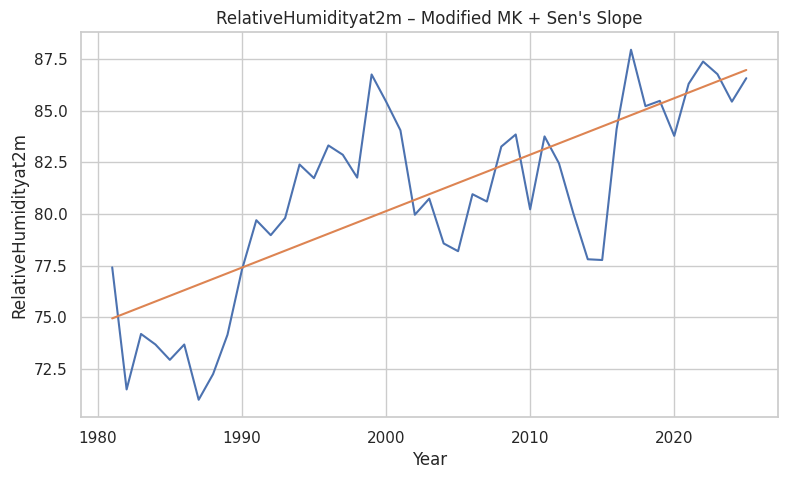

In [ ]:
import matplotlib.pyplot as plt

for var in variables:

    plt.figure(figsize=(9,5))
    plt.plot(yearly["YEAR"], yearly[var])

    slope, intercept, _, _ = theilslopes(
        yearly[var].values,
        yearly["YEAR"].values
    )

    trend_line = intercept + slope * yearly["YEAR"]
    plt.plot(yearly["YEAR"], trend_line)

    plt.title(f"{var} – Modified MK + Sen's Slope")
    plt.xlabel("Year")
    plt.ylabel(var)
    plt.show()


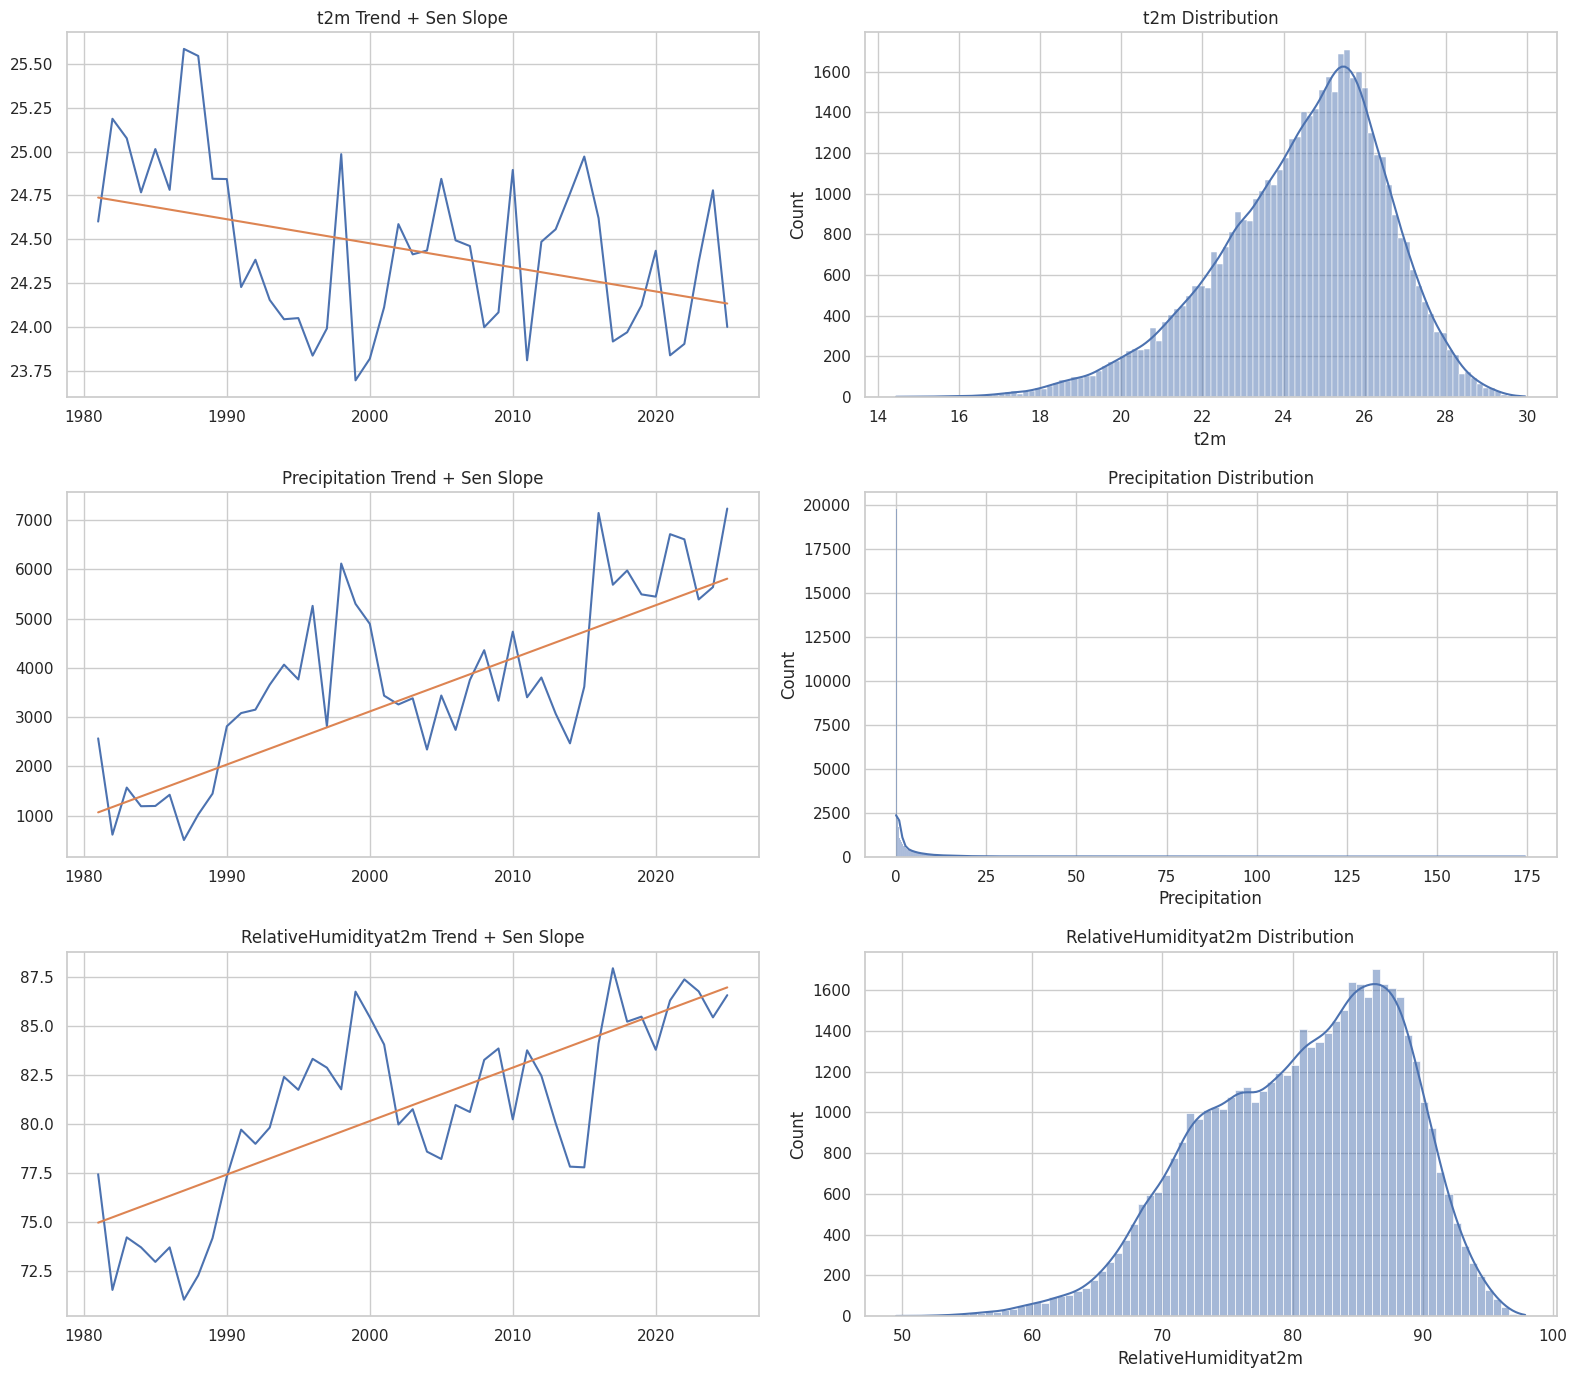

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import theilslopes

sns.set_style("whitegrid")

variables = ["t2m", "Precipitation", "RelativeHumidityat2m"]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for i, var in enumerate(variables):

    # ---- Trend with CI ribbon ----
    slope, intercept, lower, upper = theilslopes(
        yearly[var].values,
        yearly["YEAR"].values
    )

    trend_line = intercept + slope * yearly["YEAR"]

    axes[i, 0].plot(yearly["YEAR"], yearly[var])
    axes[i, 0].plot(yearly["YEAR"], trend_line)
    axes[i, 0].set_title(f"{var} Trend + Sen Slope")

    # ---- Distribution + KDE ----
    sns.histplot(df[var], kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"{var} Distribution")

plt.tight_layout()
plt.show()


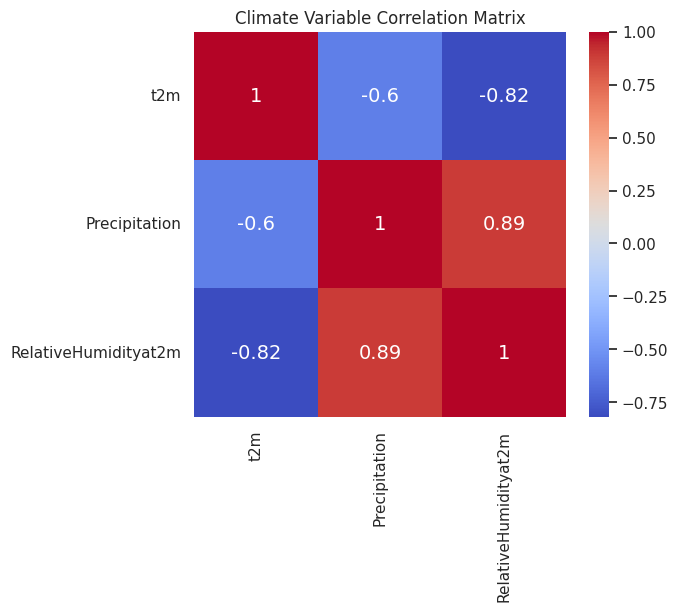

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(yearly[variables].corr(), annot=True, cmap="coolwarm")
plt.title("Climate Variable Correlation Matrix")
plt.show()


In [ ]:
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes

# Load and combine all sheets
file = "datatoshafi.xlsx"
all_sheets = pd.read_excel(file, sheet_name=None)
df = pd.concat(all_sheets.values(), ignore_index=True)

# Yearly aggregation
yearly = df.groupby("YEAR").agg({
    "t2m": "mean",
    "Precipitation": "sum",
    "RelativeHumidityat2m": "mean"
}).reset_index()

variables = ["t2m", "Precipitation", "RelativeHumidityat2m"]

results = []

for var in variables:

    # ORIGINAL Mann-Kendall
    mk_result = mk.original_test(yearly[var])

    # Sen’s slope + 95% CI
    slope, intercept, lower, upper = theilslopes(
        yearly[var].values,
        yearly["YEAR"].values,
        0.95
    )

    results.append({
        "Variable": var,
        "Trend": mk_result.trend,
        "MK p-value": mk_result.p,
        "Z-value": mk_result.z,
        "Tau": mk_result.Tau,
        "Sen Slope": slope,
        "CI Lower": lower,
        "CI Upper": upper
    })

final_results = pd.DataFrame(results)

print("\n===== ORIGINAL MANN-KENDALL RESULTS =====")
print(final_results)



===== ORIGINAL MANN-KENDALL RESULTS =====
               Variable       Trend    MK p-value   Z-value       Tau  \
0                   t2m  decreasing  1.008940e-02 -2.572750 -0.266667   
1         Precipitation  increasing  9.747766e-08  5.331364  0.551515   
2  RelativeHumidityat2m  increasing  7.852144e-08  5.370494  0.555556   

    Sen Slope   CI Lower    CI Upper  
0   -0.013740  -0.025776   -0.003441  
1  107.773560  77.456970  136.185455  
2    0.273176   0.198999    0.353484  


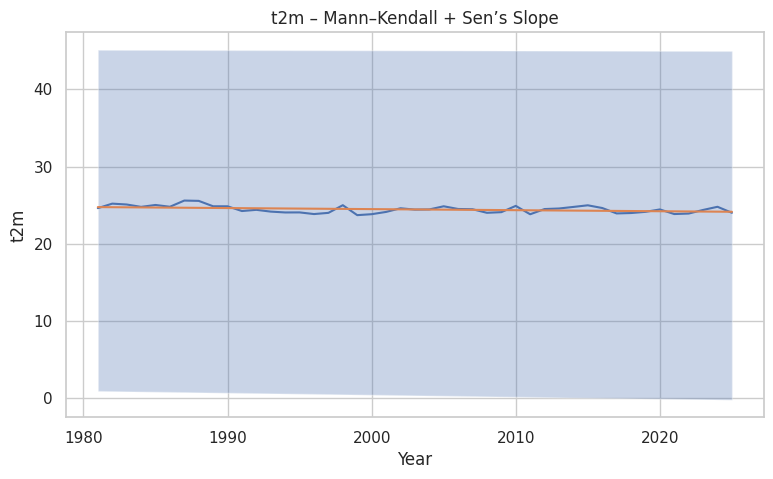

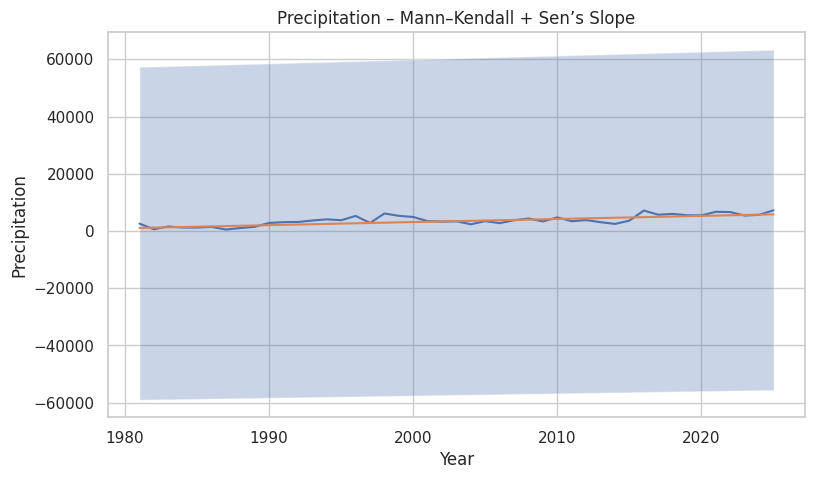

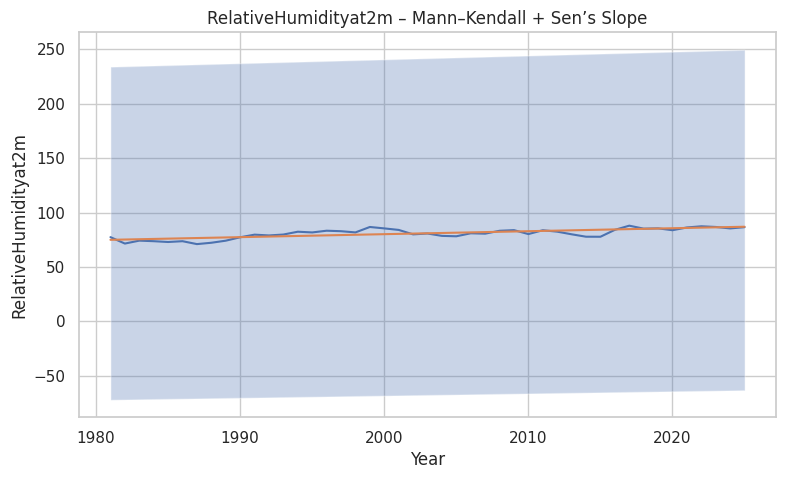

In [ ]:
import matplotlib.pyplot as plt

for var in variables:

    slope, intercept, lower, upper = theilslopes(
        yearly[var].values,
        yearly["YEAR"].values
    )

    trend_line = intercept + slope * yearly["YEAR"]
    lower_line = intercept + lower * yearly["YEAR"]
    upper_line = intercept + upper * yearly["YEAR"]

    plt.figure(figsize=(9,5))
    plt.plot(yearly["YEAR"], yearly[var])
    plt.plot(yearly["YEAR"], trend_line)
    plt.fill_between(yearly["YEAR"], lower_line, upper_line, alpha=0.3)

    plt.title(f"{var} – Mann–Kendall + Sen’s Slope")
    plt.xlabel("Year")
    plt.ylabel(var)
    plt.show()


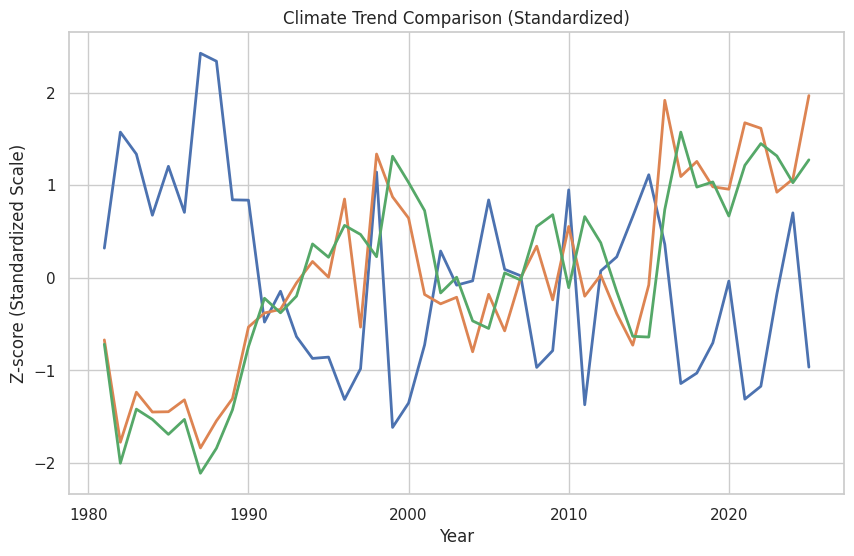

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

variables = ["t2m", "Precipitation", "RelativeHumidityat2m"]

scaler = StandardScaler()
scaled = scaler.fit_transform(yearly[variables])

scaled_df = pd.DataFrame(scaled, columns=variables)
scaled_df["YEAR"] = yearly["YEAR"]

plt.figure(figsize=(10,6))

for var in variables:
    plt.plot(scaled_df["YEAR"], scaled_df[var], linewidth=2)

plt.title("Climate Trend Comparison (Standardized)")
plt.xlabel("Year")
plt.ylabel("Z-score (Standardized Scale)")
plt.show()


In [ ]:
print(yearly["Precipitation"].min(),
      yearly["Precipitation"].max())


505.65999999999997 7230.63


In [ ]:
print(yearly.sort_values("Precipitation").head())
print(yearly.sort_values("Precipitation").tail())


   YEAR        t2m  Precipitation  RelativeHumidityat2m
6  1987  25.585790         505.66             71.013242
1  1982  25.187269         614.39             71.511963
7  1988  25.545510        1023.22             72.255592
3  1984  24.767341        1191.17             73.687067
4  1985  25.014329        1196.46             72.944247
    YEAR        t2m  Precipitation  RelativeHumidityat2m
17  1998  24.985324        6115.00             81.761662
41  2022  23.902941        6606.20             87.377936
40  2021  23.837845        6711.41             86.299315
35  2016  24.620291        7140.73             84.107505
44  2025  23.999671        7230.63             86.571963


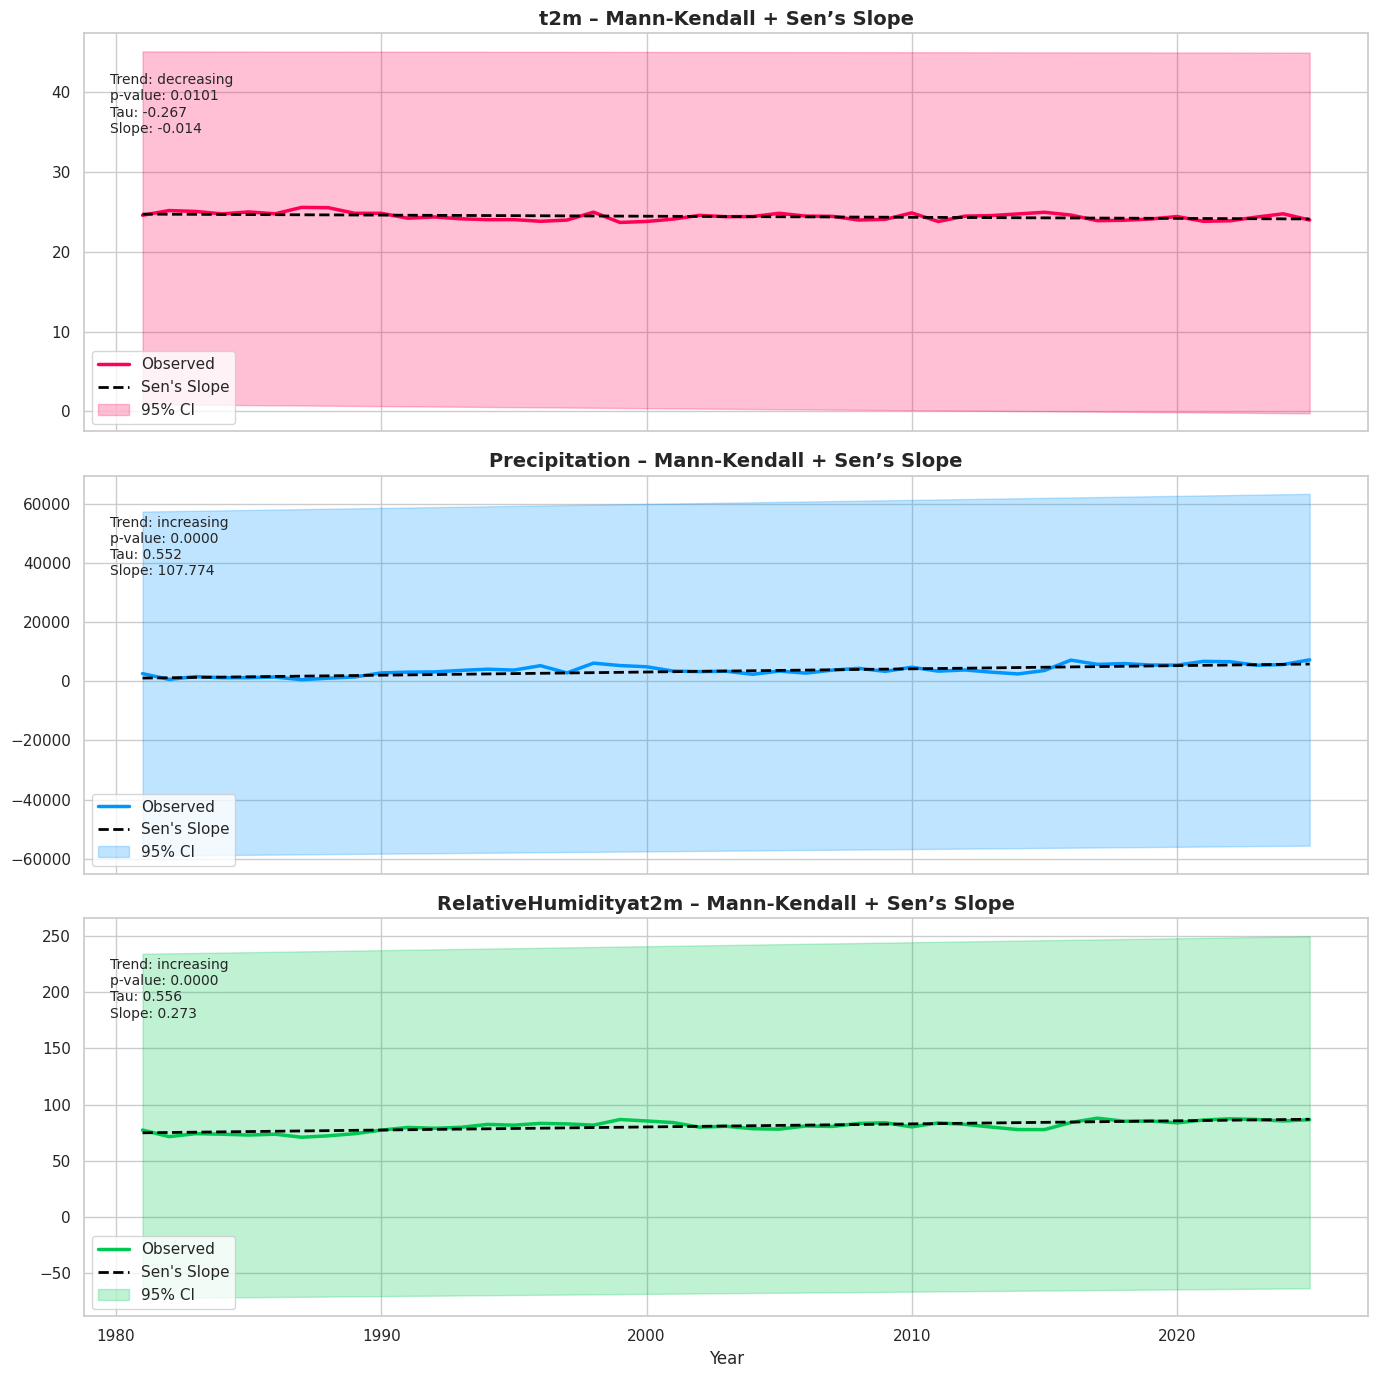

MK_Sen_Master_Climate_Analysis.png saved successfully.


In [ ]:
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes
import matplotlib.pyplot as plt

# Combine sheets
file = "datatoshafi.xlsx"
all_sheets = pd.read_excel(file, sheet_name=None)
df = pd.concat(all_sheets.values(), ignore_index=True)

# Yearly aggregation
yearly = df.groupby("YEAR").agg({
    "t2m": "mean",
    "Precipitation": "sum",
    "RelativeHumidityat2m": "mean"
}).reset_index()

variables = ["t2m", "Precipitation", "RelativeHumidityat2m"]

# Bright modern colors
colors = {
    "t2m": "#FF0054",                  # Bright red-pink
    "Precipitation": "#0096FF",        # Electric blue
    "RelativeHumidityat2m": "#00C853"  # Neon green
}

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

for i, var in enumerate(variables):

    mk_result = mk.original_test(yearly[var])

    slope, intercept, lower, upper = theilslopes(
        yearly[var].values,
        yearly["YEAR"].values,
        0.95
    )

    trend_line = intercept + slope * yearly["YEAR"]
    lower_line = intercept + lower * yearly["YEAR"]
    upper_line = intercept + upper * yearly["YEAR"]

    axes[i].plot(yearly["YEAR"], yearly[var],
                 color=colors[var], linewidth=2.5, label="Observed")

    axes[i].plot(yearly["YEAR"], trend_line,
                 color="black", linewidth=2, linestyle="--",
                 label="Sen's Slope")

    axes[i].fill_between(yearly["YEAR"], lower_line, upper_line,
                         color=colors[var], alpha=0.25,
                         label="95% CI")

    axes[i].set_title(f"{var} – Mann-Kendall + Sen’s Slope",
                      fontsize=14, fontweight='bold')

    axes[i].text(
        0.02, 0.90,
        f"Trend: {mk_result.trend}\n"
        f"p-value: {mk_result.p:.4f}\n"
        f"Tau: {mk_result.Tau:.3f}\n"
        f"Slope: {slope:.3f}",
        transform=axes[i].transAxes,
        fontsize=10,
        verticalalignment='top'
    )

    axes[i].legend()

axes[-1].set_xlabel("Year", fontsize=12)

plt.tight_layout()

# Save high-resolution image
plt.savefig("MK_Sen_Master_Climate_Analysis.png", dpi=400)
plt.show()

print("MK_Sen_Master_Climate_Analysis.png saved successfully.")


In [ ]:
total_n = len(df)
print("Total observations:", total_n)


Total observations: 49308


In [ ]:
def outlier_percentage(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((series < lower) | (series > upper)).sum()
    percentage = (outliers / len(series)) * 100

    return outliers, percentage

variables = ["t2m", "Precipitation", "RelativeHumidityat2m", "tmin2m", "tmax2m"]

results = []

for var in variables:
    count, percent = outlier_percentage(df[var])
    results.append({
        "Variable": var,
        "Outlier Count": count,
        "Outlier %": round(percent, 2)
    })

outlier_table = pd.DataFrame(results)
print(outlier_table)


               Variable  Outlier Count  Outlier %
0                   t2m            751       1.52
1         Precipitation           5706      11.57
2  RelativeHumidityat2m            133       0.27
3                tmin2m            727       1.47
4                tmax2m            390       0.79


In [ ]:
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt

# Load and combine sheets
file = "datatoshafi.xlsx"
all_sheets = pd.read_excel(file, sheet_name=None)
df = pd.concat(all_sheets.values(), ignore_index=True)

# Get unique cities
cities = df["Location"].unique()
print("Cities:", cities)


Cities: ['Phan Rang-Tháp Chàm' 'Thuận Bắc District' 'Ninh Sơn District']


In [ ]:
results = []

for city in cities:

    city_df = df[df["Location"] == city]

    yearly = city_df.groupby("YEAR").agg({
        "t2m": "mean",
        "RelativeHumidityat2m": "mean",
        "Precipitation": "sum"
    }).reset_index()

    for var in ["t2m", "RelativeHumidityat2m", "Precipitation"]:

        # Compute lag-1
        lag1 = acf(yearly[var], nlags=1)[1]

        # Original MK
        mk_result = mk.original_test(yearly[var])

        # Sen slope
        slope, intercept, lower, upper = theilslopes(
            yearly[var].values,
            yearly["YEAR"].values,
            0.95
        )

        results.append({
            "City": city,
            "Variable": var,
            "Lag1": round(lag1,3),
            "Trend": mk_result.trend,
            "p-value": mk_result.p,
            "Tau": mk_result.Tau,
            "Slope": slope,
            "CI Lower": lower,
            "CI Upper": upper
        })

final_city_results = pd.DataFrame(results)
print(final_city_results)


                  City              Variable   Lag1       Trend       p-value  \
0  Phan Rang-Tháp Chàm                   t2m  0.418  decreasing  2.383889e-02   
1  Phan Rang-Tháp Chàm  RelativeHumidityat2m  0.833  increasing  5.661119e-08   
2  Phan Rang-Tháp Chàm         Precipitation  0.731  increasing  7.852144e-08   
3   Thuận Bắc District                   t2m  0.537  decreasing  3.036260e-03   
4   Thuận Bắc District  RelativeHumidityat2m  0.838  increasing  7.043487e-08   
5   Thuận Bắc District         Precipitation  0.719  increasing  2.532488e-07   
6    Ninh Sơn District                   t2m  0.418  decreasing  2.383889e-02   
7    Ninh Sơn District  RelativeHumidityat2m  0.833  increasing  5.661119e-08   
8    Ninh Sơn District         Precipitation  0.731  increasing  7.852144e-08   

        Tau      Slope   CI Lower   CI Upper  
0 -0.234343  -0.011187  -0.021779  -0.001440  
1  0.561616   0.254977   0.183053   0.318164  
2  0.555556  34.758796  25.263333  43.270238  
3

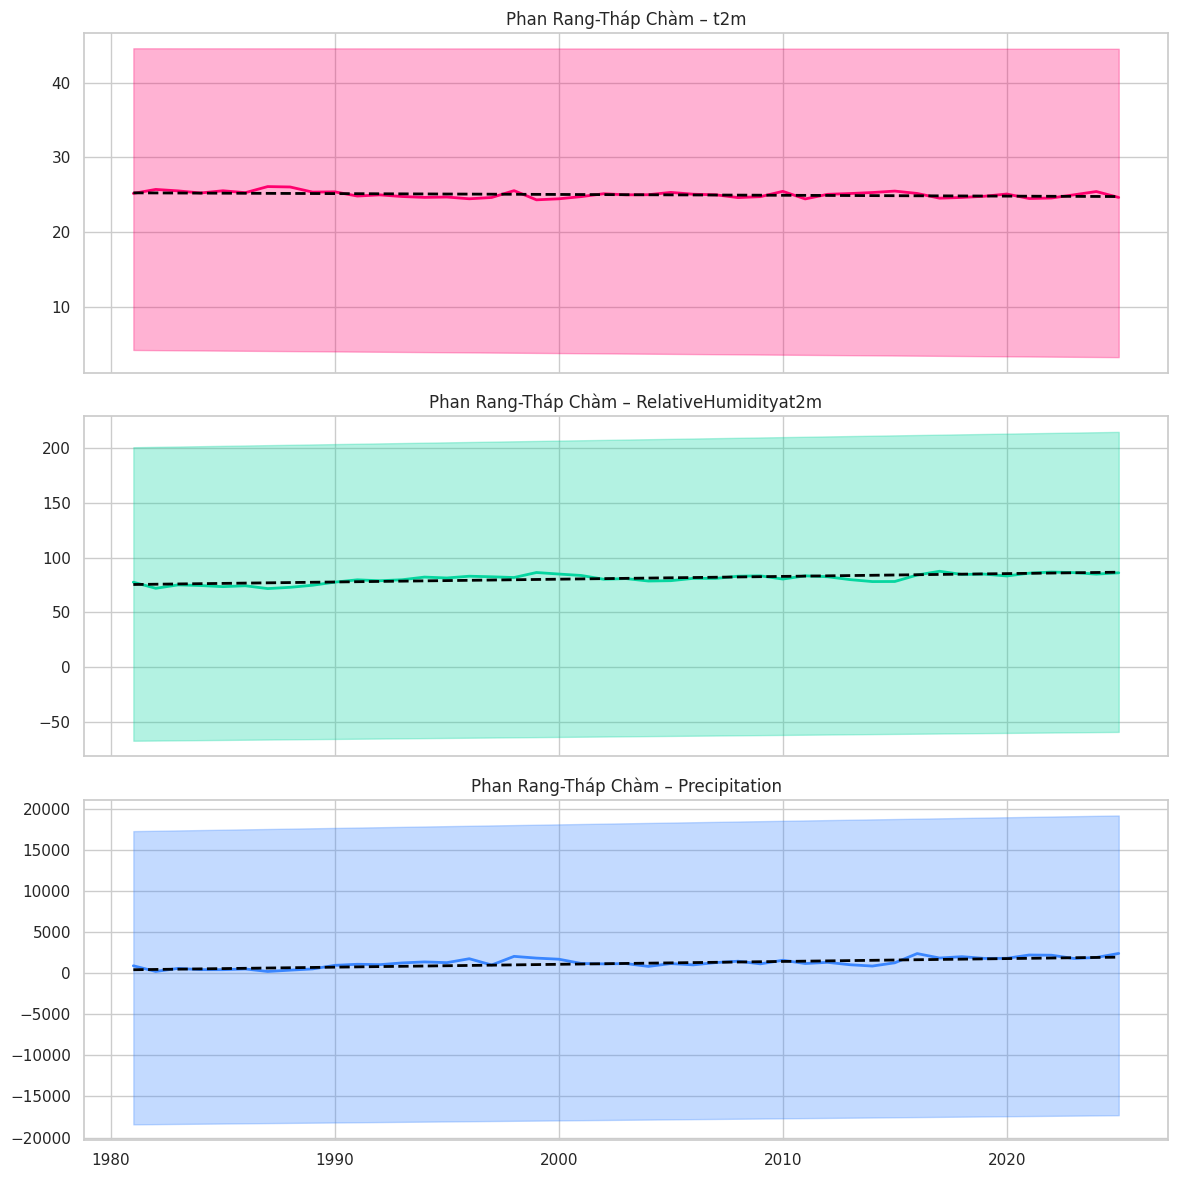

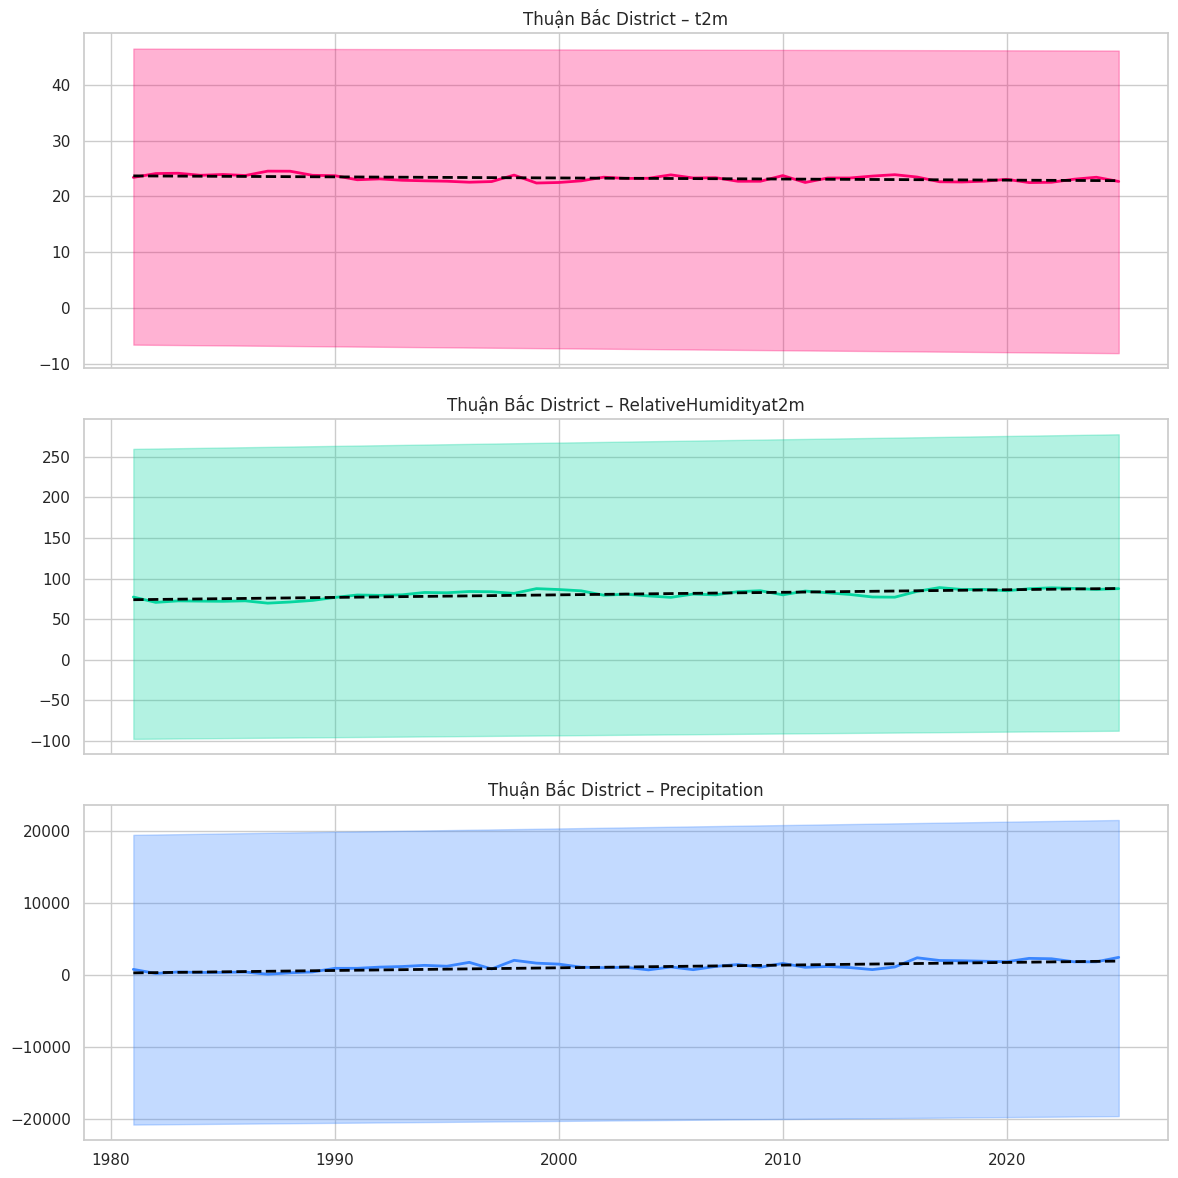

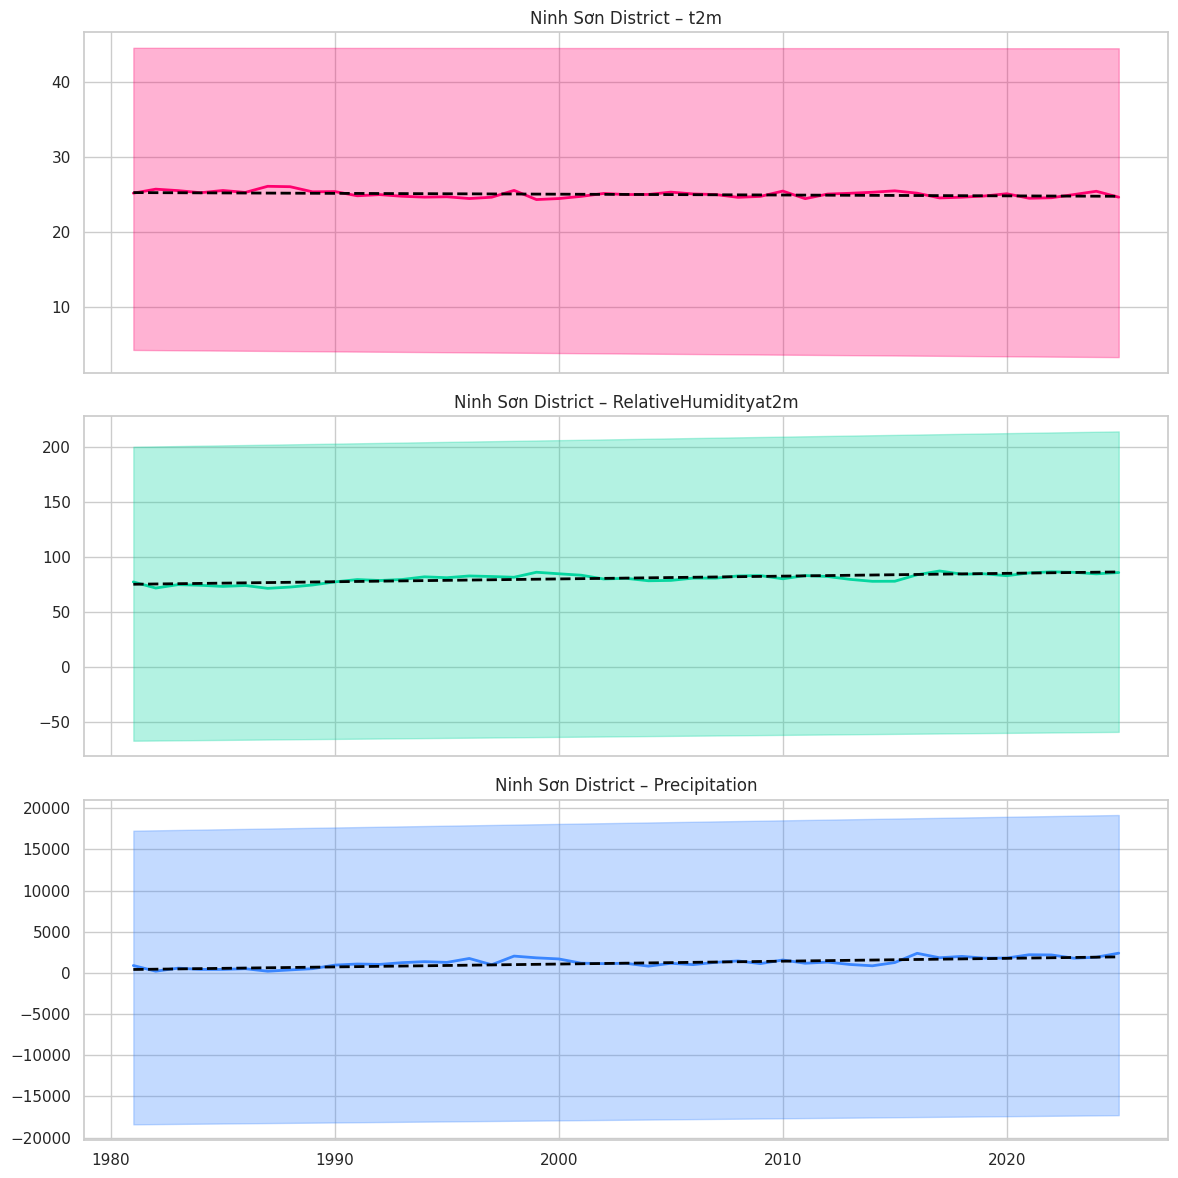

In [ ]:
colors = {
    "t2m": "#FF006E",
    "Precipitation": "#3A86FF",
    "RelativeHumidityat2m": "#06D6A0"
}

for city in cities:

    city_df = df[df["Location"] == city]

    yearly = city_df.groupby("YEAR").agg({
        "t2m": "mean",
        "RelativeHumidityat2m": "mean",
        "Precipitation": "sum"
    }).reset_index()

    fig, axes = plt.subplots(3,1, figsize=(12,12), sharex=True)

    for i, var in enumerate(["t2m","RelativeHumidityat2m","Precipitation"]):

        slope, intercept, lower, upper = theilslopes(
            yearly[var].values,
            yearly["YEAR"].values,
            0.95
        )

        trend_line = intercept + slope * yearly["YEAR"]
        lower_line = intercept + lower * yearly["YEAR"]
        upper_line = intercept + upper * yearly["YEAR"]

        axes[i].plot(yearly["YEAR"], yearly[var],
                     color=colors[var], linewidth=2)

        axes[i].plot(yearly["YEAR"], trend_line,
                     color="black", linestyle="--", linewidth=2)

        axes[i].fill_between(yearly["YEAR"],
                             lower_line, upper_line,
                             color=colors[var], alpha=0.3)

        axes[i].set_title(f"{city} – {var}")

    plt.tight_layout()
    plt.savefig(f"{city}_MK_Sen.png", dpi=400)
    plt.show()


In [ ]:
from google.colab import files
for city in cities:
    files.download(f"{city}_MK_Sen.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes
from statsmodels.tsa.stattools import acf

# Load & combine sheets
file = "datatoshafi.xlsx"
all_sheets = pd.read_excel(file, sheet_name=None)
df = pd.concat(all_sheets.values(), ignore_index=True)

cities = df["Location"].unique()

results = []

for city in cities:

    city_df = df[df["Location"] == city]

    yearly = city_df.groupby("YEAR").agg({
        "t2m": "mean",
        "RelativeHumidityat2m": "mean",
        "Precipitation": "sum"
    }).reset_index()

    for var in ["t2m", "RelativeHumidityat2m", "Precipitation"]:

        lag1 = acf(yearly[var], nlags=1)[1]

        # Modified MK
        mk_result = mk.hamed_rao_modification_test(yearly[var])

        # Sen slope + CI
        slope, intercept, lower, upper = theilslopes(
            yearly[var].values,
            yearly["YEAR"].values,
            0.95
        )

        results.append({
            "City": city,
            "Variable": var,
            "Lag1": round(lag1,3),
            "Trend": mk_result.trend,
            "p-value": mk_result.p,
            "Tau": mk_result.Tau,
            "Slope": slope,
            "CI Lower": lower,
            "CI Upper": upper
        })

final_modified_results = pd.DataFrame(results)

print("\n===== MODIFIED MK RESULTS =====")
print(final_modified_results)



===== MODIFIED MK RESULTS =====
                  City              Variable   Lag1       Trend   p-value  \
0  Phan Rang-Tháp Chàm                   t2m  0.418    no trend  0.069177   
1  Phan Rang-Tháp Chàm  RelativeHumidityat2m  0.833  increasing  0.000219   
2  Phan Rang-Tháp Chàm         Precipitation  0.731  increasing  0.000017   
3   Thuận Bắc District                   t2m  0.537  decreasing  0.023582   
4   Thuận Bắc District  RelativeHumidityat2m  0.838  increasing  0.000132   
5   Thuận Bắc District         Precipitation  0.719  increasing  0.000045   
6    Ninh Sơn District                   t2m  0.418    no trend  0.069177   
7    Ninh Sơn District  RelativeHumidityat2m  0.833  increasing  0.000219   
8    Ninh Sơn District         Precipitation  0.731  increasing  0.000017   

        Tau      Slope   CI Lower   CI Upper  
0 -0.234343  -0.011187  -0.021779  -0.001440  
1  0.561616   0.254977   0.183053   0.318164  
2  0.555556  34.758796  25.263333  43.270238  
3 -0.307

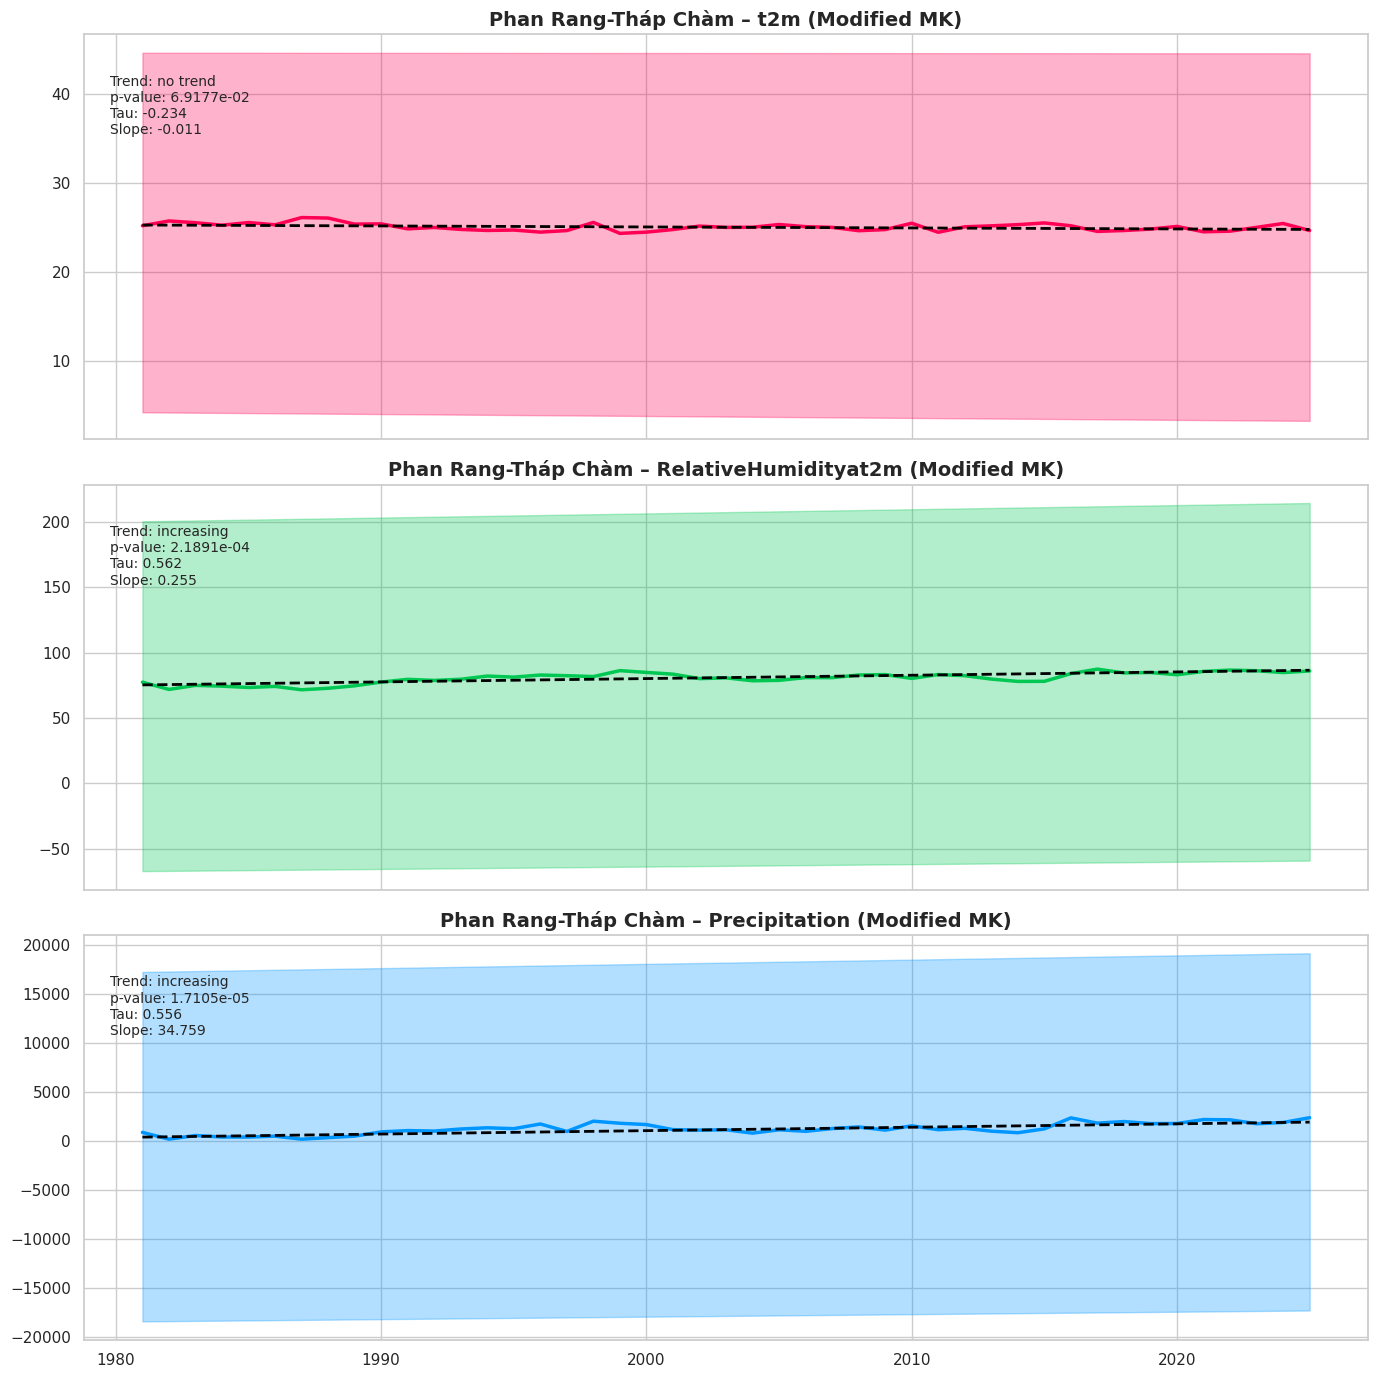

Phan Rang-Tháp Chàm_Modified_MK.png saved.


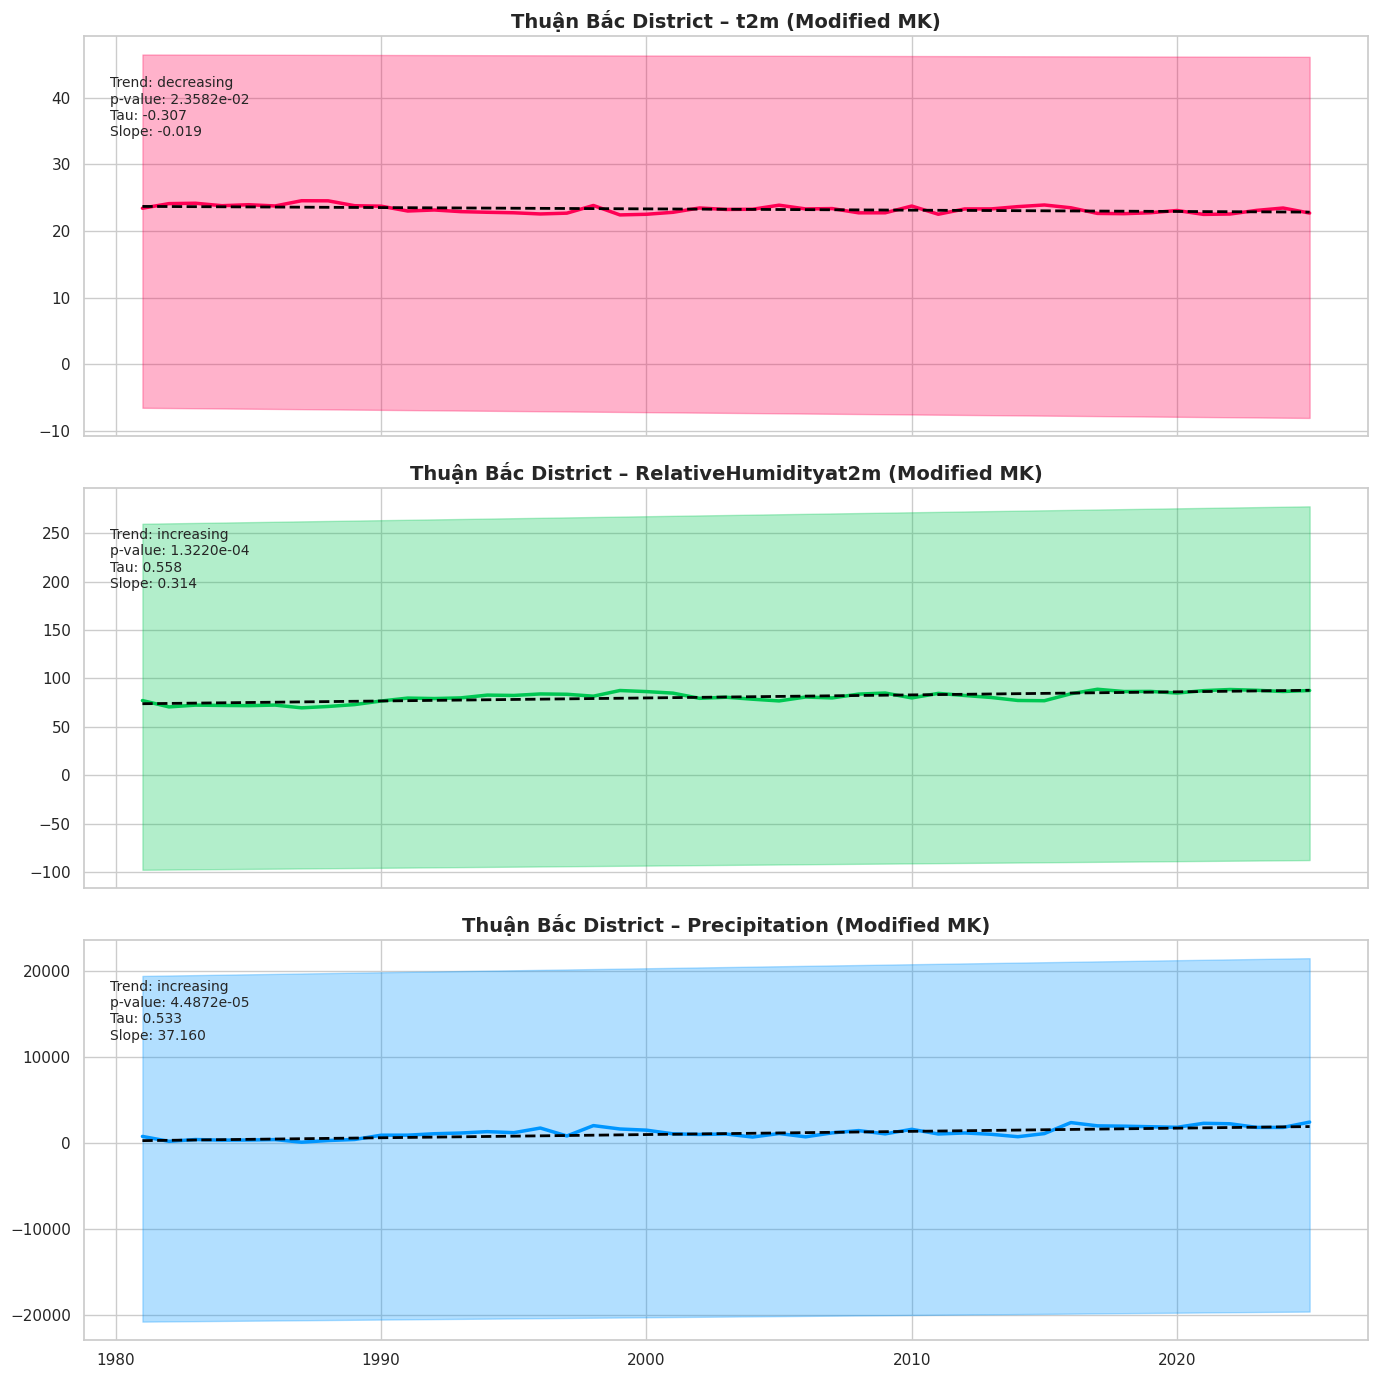

Thuận Bắc District_Modified_MK.png saved.


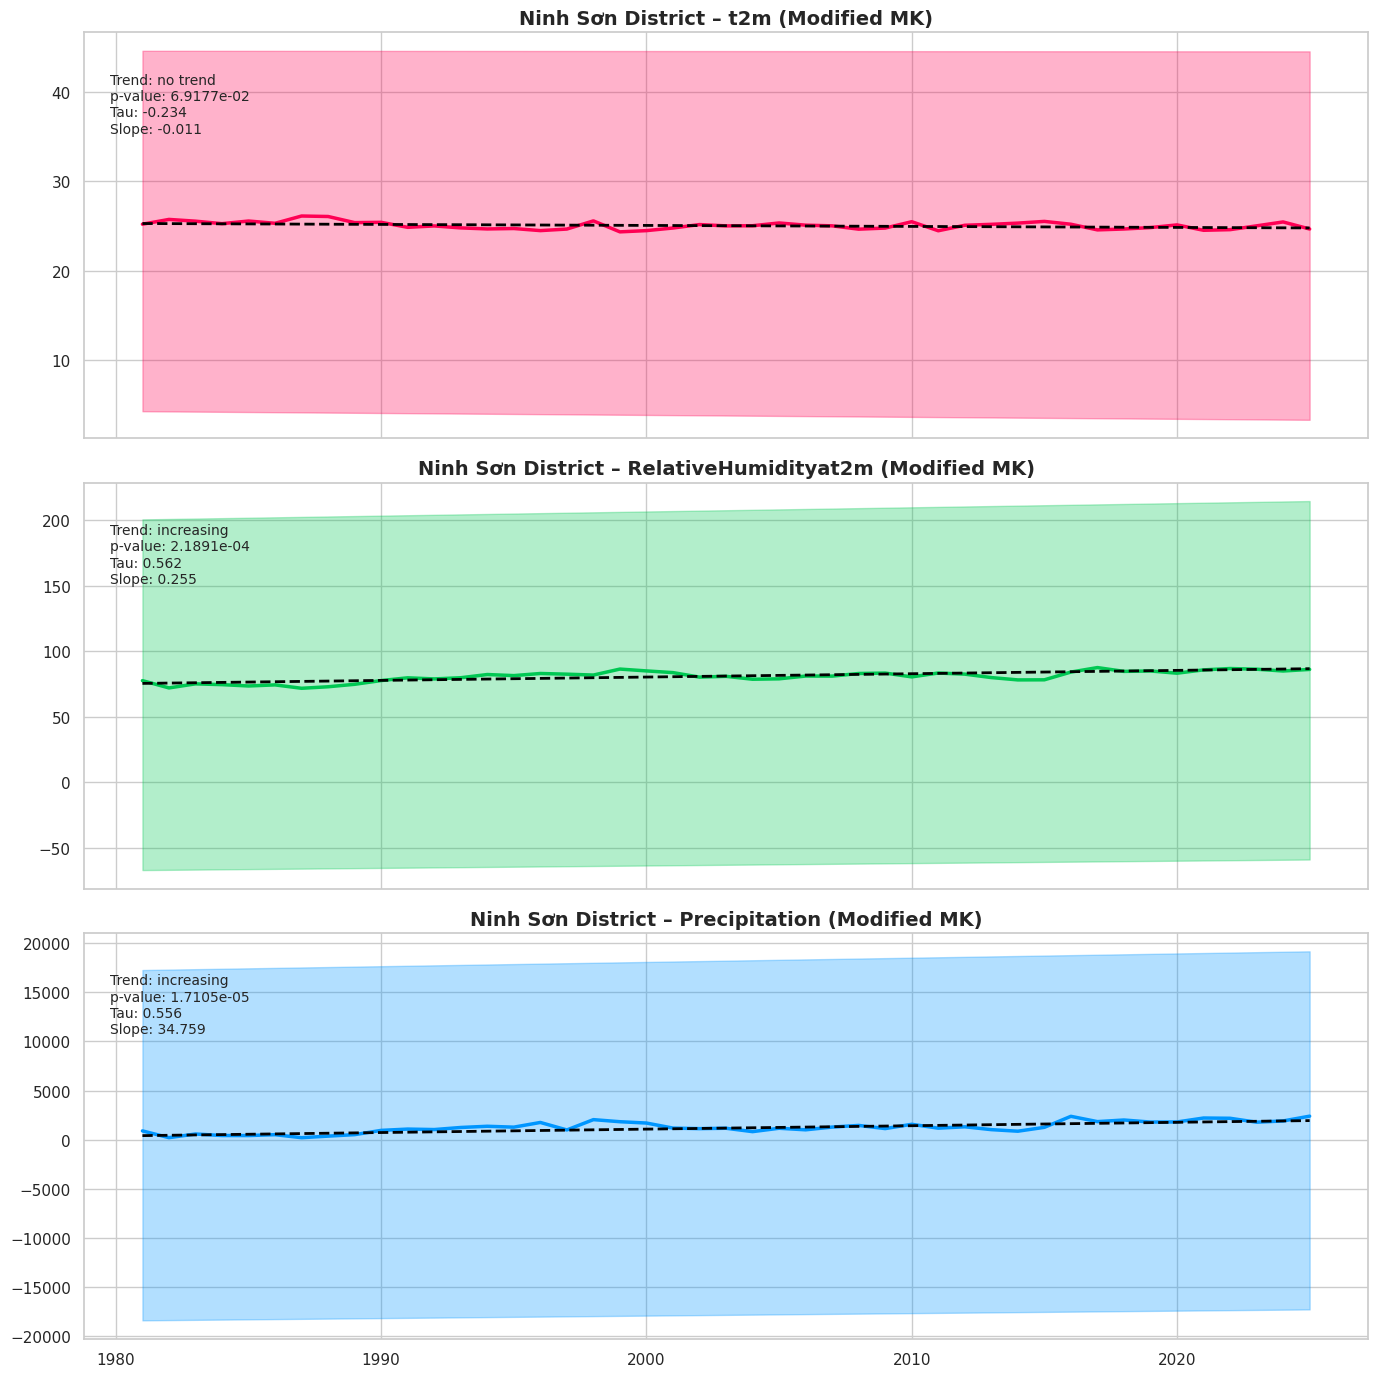

Ninh Sơn District_Modified_MK.png saved.


In [ ]:
import matplotlib.pyplot as plt

colors = {
    "t2m": "#FF0054",
    "RelativeHumidityat2m": "#00C853",
    "Precipitation": "#0096FF"
}

for city in cities:

    city_df = df[df["Location"] == city]

    yearly = city_df.groupby("YEAR").agg({
        "t2m": "mean",
        "RelativeHumidityat2m": "mean",
        "Precipitation": "sum"
    }).reset_index()

    fig, axes = plt.subplots(3,1, figsize=(14,14), sharex=True)

    for i, var in enumerate(["t2m","RelativeHumidityat2m","Precipitation"]):

        mk_result = mk.hamed_rao_modification_test(yearly[var])

        slope, intercept, lower, upper = theilslopes(
            yearly[var].values,
            yearly["YEAR"].values,
            0.95
        )

        trend_line = intercept + slope * yearly["YEAR"]
        lower_line = intercept + lower * yearly["YEAR"]
        upper_line = intercept + upper * yearly["YEAR"]

        axes[i].plot(yearly["YEAR"], yearly[var],
                     color=colors[var], linewidth=2.5)

        axes[i].plot(yearly["YEAR"], trend_line,
                     color="black", linestyle="--", linewidth=2)

        axes[i].fill_between(yearly["YEAR"],
                             lower_line, upper_line,
                             color=colors[var], alpha=0.3)

        axes[i].set_title(
            f"{city} – {var} (Modified MK)",
            fontsize=14, fontweight='bold'
        )

        axes[i].text(
            0.02, 0.90,
            f"Trend: {mk_result.trend}\n"
            f"p-value: {mk_result.p:.4e}\n"
            f"Tau: {mk_result.Tau:.3f}\n"
            f"Slope: {slope:.3f}",
            transform=axes[i].transAxes,
            fontsize=10,
            verticalalignment='top'
        )

    plt.tight_layout()
    filename = f"{city}_Modified_MK.png"
    plt.savefig(filename, dpi=400)
    plt.show()

    print(f"{filename} saved.")


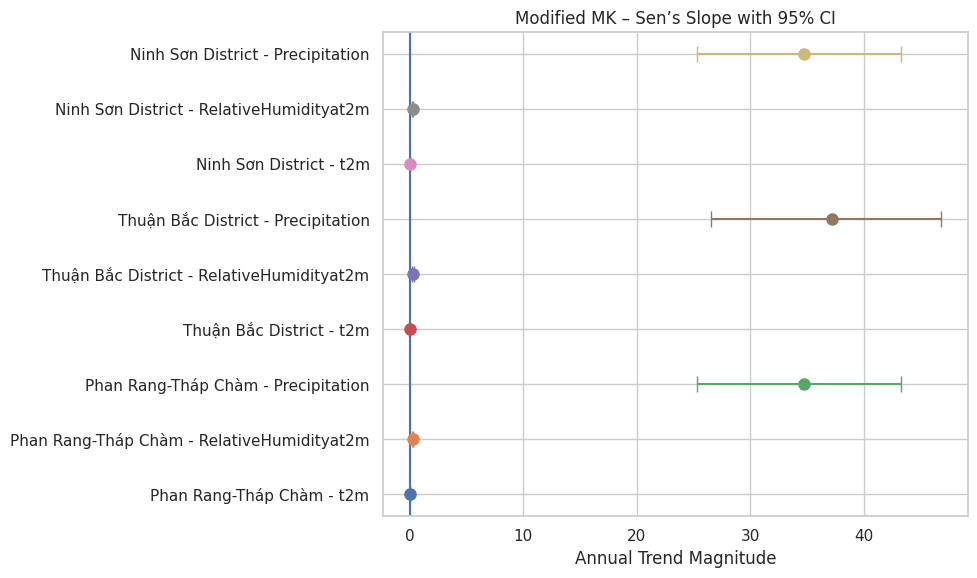

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10,6))

for i, row in final_modified_results.iterrows():
    ax.errorbar(
        row["Slope"],
        i,
        xerr=[[row["Slope"] - row["CI Lower"]],
              [row["CI Upper"] - row["Slope"]]],
        fmt='o',
        markersize=8,
        capsize=6
    )

ax.axvline(0)
ax.set_yticks(range(len(final_modified_results)))
ax.set_yticklabels(final_modified_results["City"] + " - " + final_modified_results["Variable"])
ax.set_title("Modified MK – Sen’s Slope with 95% CI")
ax.set_xlabel("Annual Trend Magnitude")
plt.tight_layout()
plt.show()


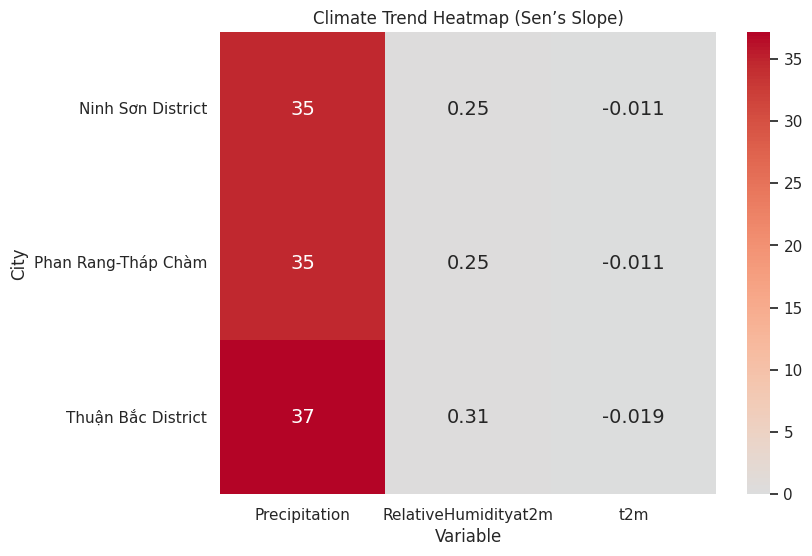

In [ ]:
import seaborn as sns
import pandas as pd

pivot = final_modified_results.pivot(
    index="City",
    columns="Variable",
    values="Slope"
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="coolwarm", center=0)
plt.title("Climate Trend Heatmap (Sen’s Slope)")
plt.show()


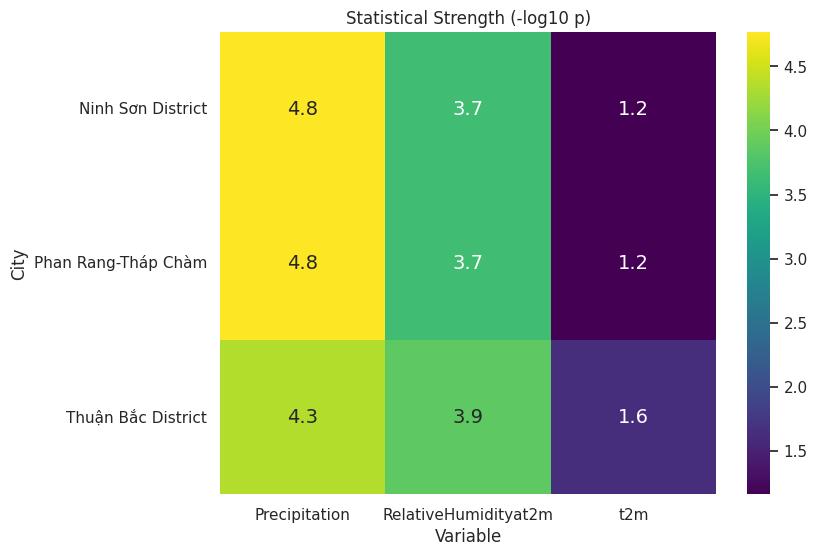

In [ ]:
pivot_p = final_modified_results.pivot(
    index="City",
    columns="Variable",
    values="p-value"
)

confidence = -np.log10(pivot_p)

plt.figure(figsize=(8,6))
sns.heatmap(confidence, annot=True, cmap="viridis")
plt.title("Statistical Strength (-log10 p)")
plt.show()


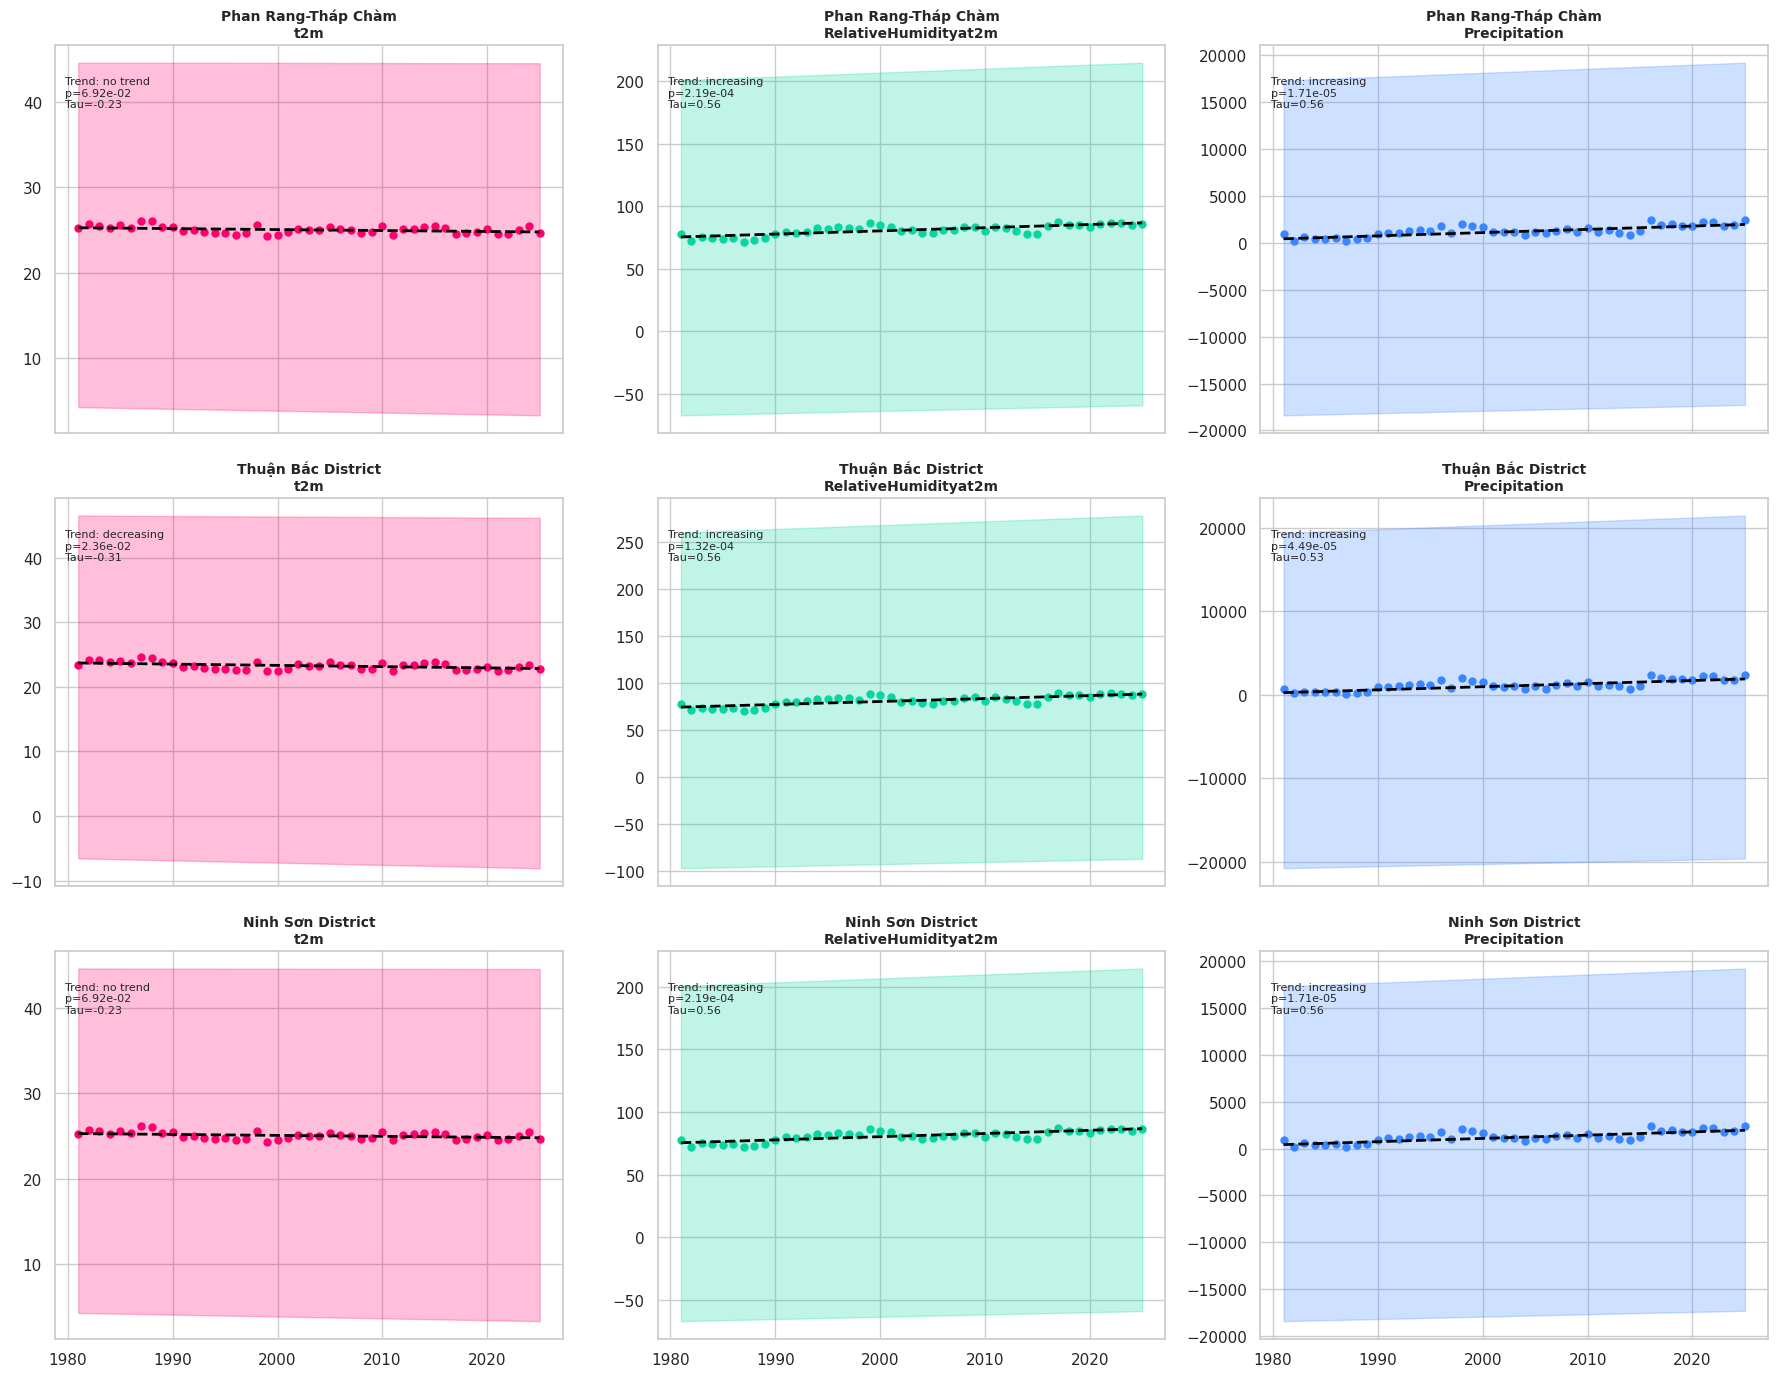

MASTER_MK_SEN_3x3_Dashboard.png saved successfully.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pymannkendall as mk
from scipy.stats import theilslopes

# Load & combine sheets
file = "datatoshafi.xlsx"
all_sheets = pd.read_excel(file, sheet_name=None)
df = pd.concat(all_sheets.values(), ignore_index=True)

cities = df["Location"].unique()
variables = ["t2m", "RelativeHumidityat2m", "Precipitation"]

# Bright professional colors
colors = {
    "t2m": "#FF006E",
    "RelativeHumidityat2m": "#06D6A0",
    "Precipitation": "#3A86FF"
}

fig, axes = plt.subplots(len(cities), len(variables),
                         figsize=(18, 14),
                         sharex=True)

for i, city in enumerate(cities):

    city_df = df[df["Location"] == city]

    yearly = city_df.groupby("YEAR").agg({
        "t2m": "mean",
        "RelativeHumidityat2m": "mean",
        "Precipitation": "sum"
    }).reset_index()

    for j, var in enumerate(variables):

        mk_result = mk.hamed_rao_modification_test(yearly[var])

        slope, intercept, lower, upper = theilslopes(
            yearly[var].values,
            yearly["YEAR"].values,
            0.95
        )

        trend_line = intercept + slope * yearly["YEAR"]
        lower_line = intercept + lower * yearly["YEAR"]
        upper_line = intercept + upper * yearly["YEAR"]

        ax = axes[i, j]

        ax.scatter(yearly["YEAR"], yearly[var],
                   color=colors[var], s=25)

        ax.plot(yearly["YEAR"], trend_line,
                color="black", linestyle="--", linewidth=2)

        ax.fill_between(yearly["YEAR"],
                        lower_line, upper_line,
                        color=colors[var], alpha=0.25)

        ax.set_title(f"{city}\n{var}",
                     fontsize=10, fontweight='bold')

        ax.text(
            0.02, 0.92,
            f"Trend: {mk_result.trend}\n"
            f"p={mk_result.p:.2e}\n"
            f"Tau={mk_result.Tau:.2f}",
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment='top'
        )

plt.tight_layout()
plt.savefig("MASTER_MK_SEN_3x3_Dashboard.png", dpi=400)
plt.show()

print("MASTER_MK_SEN_3x3_Dashboard.png saved successfully.")


In [ ]:
from google.colab import files
files.download("MASTER_MK_SEN_3x3_Dashboard.png")


In [ ]:
import pandas as pd

file = "datatoshafi.xlsx"
all_sheets = pd.read_excel(file, sheet_name=None)
df = pd.concat(all_sheets.values(), ignore_index=True)

print("Data loaded. Shape:", df.shape)


Data loaded. Shape: (49308, 9)


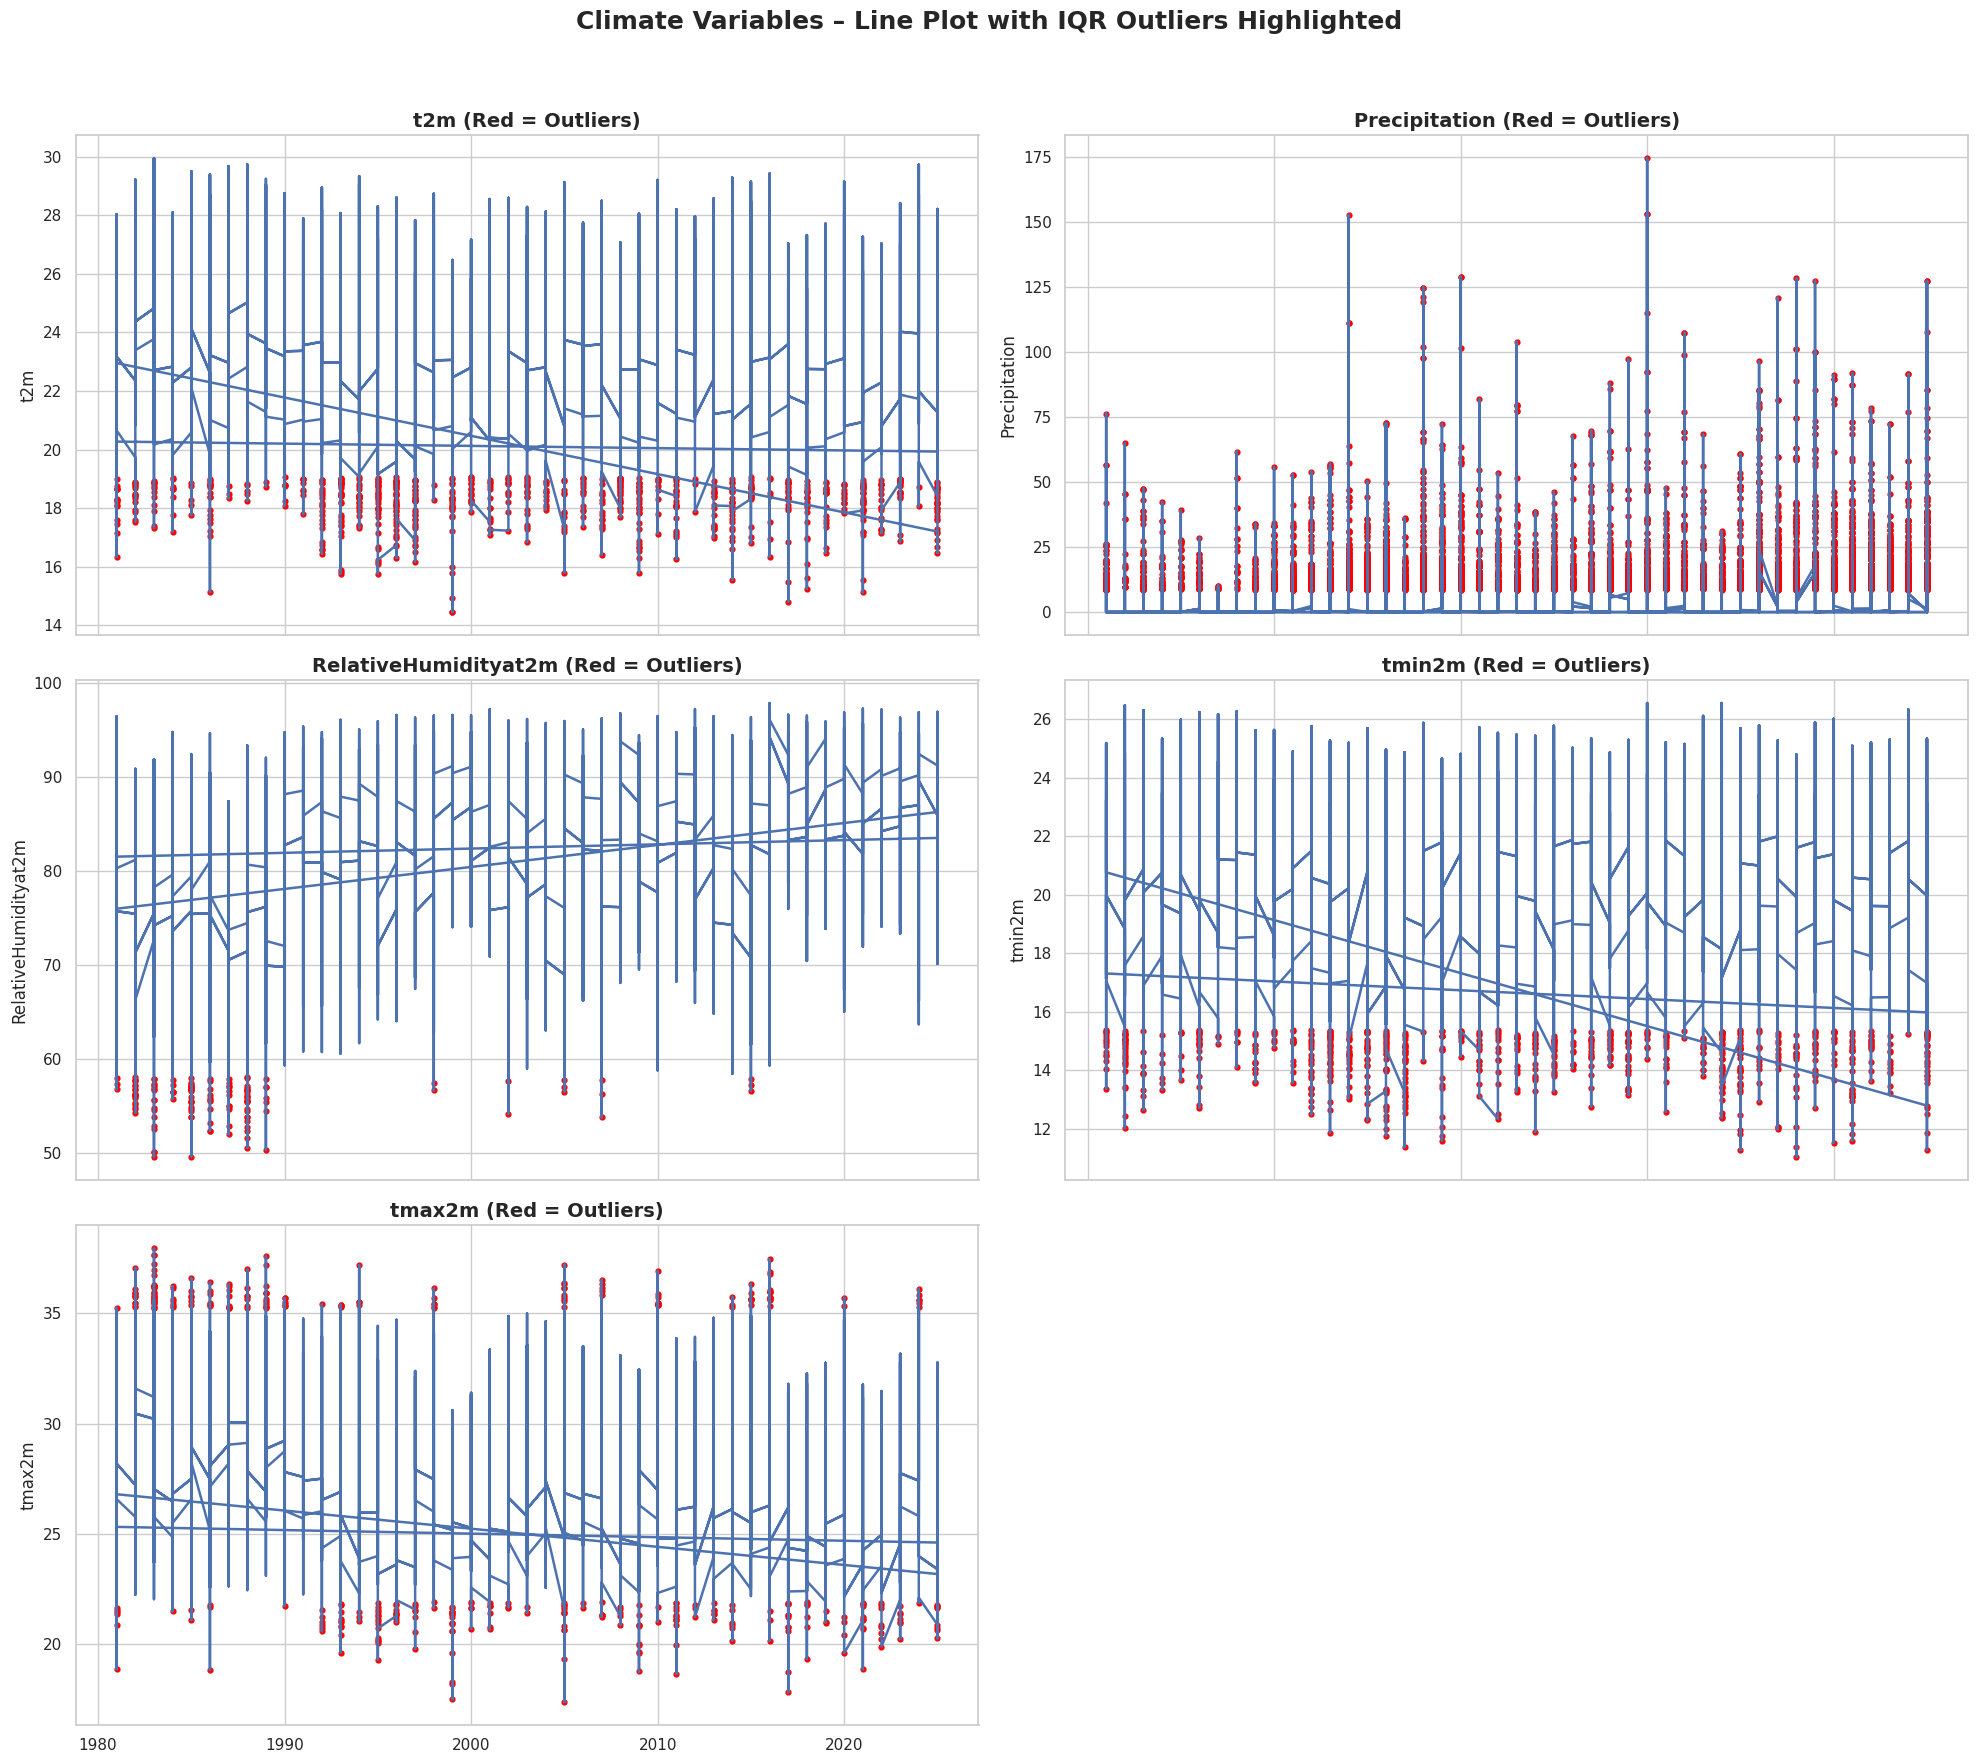

Climate_Outliers_Master_Page.png saved successfully.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload dataset
file = "datatoshafi.xlsx"
all_sheets = pd.read_excel(file, sheet_name=None)
df = pd.concat(all_sheets.values(), ignore_index=True)

variables = ["t2m", "Precipitation", "RelativeHumidityat2m", "tmin2m", "tmax2m"]

def detect_outliers_mask(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

# High-resolution master canvas
fig, axes = plt.subplots(3, 2, figsize=(20, 18), sharex=True)

axes = axes.flatten()

for i, var in enumerate(variables):

    mask = detect_outliers_mask(df[var])

    axes[i].plot(df["YEAR"], df[var], linewidth=1.8)
    axes[i].scatter(df["YEAR"][mask], df[var][mask],
                    color="red", s=12)

    axes[i].set_title(f"{var} (Red = Outliers)",
                      fontsize=14, fontweight="bold")
    axes[i].set_ylabel(var)

# Remove empty subplot (since 5 variables, 6 slots)
fig.delaxes(axes[-1])

fig.suptitle("Climate Variables – Line Plot with IQR Outliers Highlighted",
             fontsize=18, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save ultra-high resolution
plt.savefig("Climate_Outliers_Master_Page.png", dpi=600, bbox_inches="tight")

plt.show()

print("Climate_Outliers_Master_Page.png saved successfully.")


In [ ]:
from google.colab import files
files.download("Climate_Outliers_Master_Page.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes, spearmanr
import statsmodels.api as sm
import numpy as np

# Yearly aggregation
yearly = df.groupby("YEAR").agg({
    "t2m": "mean"
}).reset_index()

X = yearly["YEAR"]
y = yearly["t2m"]

# ---------------------------
# 1️⃣ Modified MK + Sen
# ---------------------------
mk_result = mk.hamed_rao_modification_test(y)

sen_slope, intercept, lower, upper = theilslopes(
    y.values, X.values, 0.95
)

print("===== Modified MK =====")
print("Tau:", mk_result.Tau)
print("Z:", mk_result.z)
print("p-value:", mk_result.p)
print("Sen slope:", sen_slope)
print("CI:", lower, upper)


# ---------------------------
# 2️⃣ Linear Regression
# ---------------------------
X_reg = sm.add_constant(X)
model = sm.OLS(y, X_reg).fit()

print("\n===== Linear Regression =====")
print("Slope:", model.params[1])
print("p-value:", model.pvalues[1])
print("R²:", model.rsquared)


# ---------------------------
# 3️⃣ Spearman Rank Trend
# ---------------------------
rho, p_spear = spearmanr(X, y)

print("\n===== Spearman Trend =====")
print("Spearman rho:", rho)
print("p-value:", p_spear)


===== Modified MK =====
Tau: -0.26666666666666666
Z: -2.0426917883664335
p-value: 0.0410829582243637
Sen slope: -0.013740021488047288
CI: -0.025776061384864525 -0.003441359593308958

===== Linear Regression =====
Slope: -0.014990268611053265
p-value: 0.004495373307988258
R²: 0.17294299426431892

===== Spearman Trend =====
Spearman rho: -0.4061923583662714
p-value: 0.005629478631876352


/tmp/ipython-input-61863635.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Slope:", model.params[1])
/tmp/ipython-input-61863635.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("p-value:", model.pvalues[1])


In [ ]:
import pandas as pd
import pymannkendall as mk
from scipy.stats import theilslopes, spearmanr
import statsmodels.api as sm
import numpy as np

# Yearly aggregation
yearly = df.groupby("YEAR").agg({
    "t2m": "mean",
    "RelativeHumidityat2m": "mean",
    "Precipitation": "sum"
}).reset_index()

variables = ["t2m", "RelativeHumidityat2m", "Precipitation"]

results = []

for var in variables:

    X = yearly["YEAR"]
    y = yearly[var]

    # ---------------------------
    # Modified MK
    # ---------------------------
    mk_result = mk.hamed_rao_modification_test(y)

    sen_slope, intercept, lower, upper = theilslopes(
        y.values, X.values, 0.95
    )

    # ---------------------------
    # Linear Regression
    # ---------------------------
    X_reg = sm.add_constant(X)
    model = sm.OLS(y, X_reg).fit()

    # ---------------------------
    # Spearman
    # ---------------------------
    rho, p_spear = spearmanr(X, y)

    results.append({
    "Variable": var,

    "MK Tau": round(mk_result.Tau,3),
    "MK Z": round(mk_result.z,3),
    "MK p": round(mk_result.p,5),
    "Sen Slope": round(sen_slope,5),
    "CI Lower": round(lower,5),
    "CI Upper": round(upper,5),

    "Reg Slope": round(model.params.iloc[1], 5),
    "Reg p": round(model.pvalues.iloc[1], 5),
    "R²": round(model.rsquared,3),

    "Spearman rho": round(rho,3),
    "Spearman p": round(p_spear,5)
})


final_trend_table = pd.DataFrame(results)

print("\n===== MASTER TREND COMPARISON TABLE =====")
print(final_trend_table)



===== MASTER TREND COMPARISON TABLE =====
               Variable  MK Tau   MK Z     MK p  Sen Slope  CI Lower  \
0                   t2m  -0.267 -2.043  0.04108   -0.01374  -0.02578   
1  RelativeHumidityat2m   0.556  3.628  0.00029    0.27318   0.19900   
2         Precipitation   0.552  4.271  0.00002  107.77356  77.45697   

    CI Upper  Reg Slope   Reg p     R²  Spearman rho  Spearman p  
0   -0.00344   -0.01499  0.0045  0.173        -0.406     0.00563  
1    0.35348    0.26986  0.0000  0.581         0.753     0.00000  
2  136.18545  104.01068  0.0000  0.584         0.746     0.00000  


In [ ]:
import pandas as pd

file = "datatoshafi.xlsx"   # make sure file is uploaded
all_sheets = pd.read_excel(file, sheet_name=None)

df = pd.concat(all_sheets.values(), ignore_index=True)

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (49308, 9)


In [ ]:
city_name = "Phan Rang-Tháp Chàm"

city_df = df[df["Location"] == city_name].copy()

city_df["DATE"] = pd.to_datetime(city_df["YEAR"].astype(str), format="%Y") + \
                  pd.to_timedelta(city_df["DOY"] - 1, unit="D")

city_df = city_df.sort_values("DATE")


In [ ]:
for col in ["t2m", "RelativeHumidityat2m", "Precipitation"]:
    city_df[f"{col}_lag1"] = city_df[col].shift(1)
    city_df[f"{col}_lag7"] = city_df[col].shift(7)
    city_df[f"{col}_lag30"] = city_df[col].shift(30)

city_df["dayofyear"] = city_df["DATE"].dt.dayofyear
city_df["month"] = city_df["DATE"].dt.month

city_df = city_df.dropna()


In [ ]:
feature_cols = [
    "t2m_lag1","t2m_lag7","t2m_lag30",
    "RelativeHumidityat2m_lag1","RelativeHumidityat2m_lag7","RelativeHumidityat2m_lag30",
    "Precipitation_lag1","Precipitation_lag7","Precipitation_lag30",
    "dayofyear","month"
]

X = city_df[feature_cols]

y = city_df[["t2m", "RelativeHumidityat2m", "Precipitation"]]


In [ ]:
split_index = int(len(city_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

for i, col in enumerate(y.columns):

    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    mape = np.mean(np.abs((y_test.iloc[:, i] - y_pred[:, i]) /
                           y_test.iloc[:, i])) * 100

    print(f"\n===== {col} =====")
    print("R²:", r2)
    print("RMSE:", rmse)
    print("MAPE:", mape)



===== t2m =====
R²: 0.9163540446026719
RMSE: 0.4714293641471546
MAPE: 1.478657175500304

===== RelativeHumidityat2m =====
R²: 0.7023016728315248
RMSE: 2.5207721805897547
MAPE: 2.305347754384756

===== Precipitation =====
R²: 0.26525572137902587
RMSE: 8.475939615293152
MAPE: inf


In [ ]:
def smape(y_true, y_pred):
    return np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    ) * 100


In [ ]:
results = []

variables = ["t2m", "RelativeHumidityat2m", "Precipitation"]

for i, col in enumerate(variables):

    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))

    if col != "Precipitation":
        mape = np.mean(np.abs((y_test.iloc[:, i] - y_pred[:, i]) /
                               y_test.iloc[:, i])) * 100
        accuracy = 100 - mape
    else:
        mape = smape(y_test.iloc[:, i], y_pred[:, i])
        accuracy = 100 - mape

    results.append({
        "Variable": col,
        "R²": round(r2, 3),
        "RMSE": round(rmse, 3),
        "Error (%)": round(mape, 2),
        "Prediction Accuracy (%)": round(accuracy, 2)
    })

performance_table =F = pd.DataFrame(results)

print("\n===== FINAL MODEL PERFORMANCE TABLE =====")
print(performance_table)



===== FINAL MODEL PERFORMANCE TABLE =====
               Variable     R²   RMSE  Error (%)  Prediction Accuracy (%)
0                   t2m  0.916  0.471       1.48                    98.52
1  RelativeHumidityat2m  0.702  2.521       2.31                    97.69
2         Precipitation  0.265  8.476     100.39                    -0.39


In [ ]:
city_name = "Phan Rang-Tháp Chàm"
city_df = df[df["Location"] == city_name].copy()

city_df["DATE"] = pd.to_datetime(city_df["YEAR"].astype(str), format="%Y") + \
                  pd.to_timedelta(city_df["DOY"] - 1, unit="D")

city_df = city_df.sort_values("DATE")


In [ ]:
city_df["rain_occurrence"] = (city_df["Precipitation"] > 0).astype(int)


In [ ]:
city_df["prec_lag1"] = city_df["Precipitation"].shift(1)
city_df["prec_lag7"] = city_df["Precipitation"].shift(7)
city_df["prec_lag30"] = city_df["Precipitation"].shift(30)

city_df["t2m_lag1"] = city_df["t2m"].shift(1)
city_df["rh_lag1"] = city_df["RelativeHumidityat2m"].shift(1)

city_df["dayofyear"] = city_df["DATE"].dt.dayofyear
city_df["month"] = city_df["DATE"].dt.month

city_df = city_df.dropna()


In [ ]:
features = [
    "prec_lag1","prec_lag7","prec_lag30",
    "t2m_lag1","rh_lag1",
    "dayofyear","month"
]

X = city_df[features]

split_index = int(len(city_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

# Classification target
y_train_class = city_df["rain_occurrence"].iloc[:split_index]
y_test_class = city_df["rain_occurrence"].iloc[split_index:]


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

clf = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

clf.fit(X_train, y_train_class)

y_pred_class = clf.predict(X_test)

print("Rain Occurrence Accuracy:",
      accuracy_score(y_test_class, y_pred_class))

print("F1 Score:",
      f1_score(y_test_class, y_pred_class))


Rain Occurrence Accuracy: 0.9466788543570993
F1 Score: 0.9703640982218459


In [ ]:
rain_train_mask = y_train_class == 1
rain_test_mask = y_test_class == 1

y_train_reg = city_df["Precipitation"].iloc[:split_index][rain_train_mask]
y_test_reg = city_df["Precipitation"].iloc[split_index:][rain_test_mask]

X_train_reg = X_train[rain_train_mask]
X_test_reg = X_test[rain_test_mask]


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

reg = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

reg.fit(X_train_reg, y_train_reg)

y_pred_reg = reg.predict(X_test_reg)

r2 = r2_score(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print("Rainfall Amount R²:", r2)
print("Rainfall Amount RMSE:", rmse)


Rainfall Amount R²: 0.18883054345295103
Rainfall Amount RMSE: 9.238001463613093


In [ ]:
y_train_reg_log = np.log1p(y_train_reg)
reg.fit(X_train_reg, y_train_reg_log)

y_pred_log = reg.predict(X_test_reg)
y_pred_reg = np.expm1(y_pred_log)


In [ ]:
import pandas as pd

file = "datatoshafi.xlsx"   # make sure file is uploaded
all_sheets = pd.read_excel(file, sheet_name=None)

df = pd.concat(all_sheets.values(), ignore_index=True)

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (49308, 9)


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, f1_score

def climate_pipeline(city_name):

    city_df = df[df["Location"] == city_name].copy()

    city_df["DATE"] = pd.to_datetime(city_df["YEAR"].astype(str), format="%Y") + \
                      pd.to_timedelta(city_df["DOY"] - 1, unit="D")

    city_df = city_df.sort_values("DATE")

    # Create rain occurrence target
    city_df["rain_occurrence"] = (city_df["Precipitation"] > 0).astype(int)

    # Lag features
    for col in ["t2m", "RelativeHumidityat2m", "Precipitation"]:
        city_df[f"{col}_lag1"] = city_df[col].shift(1)
        city_df[f"{col}_lag7"] = city_df[col].shift(7)
        city_df[f"{col}_lag30"] = city_df[col].shift(30)

    city_df["dayofyear"] = city_df["DATE"].dt.dayofyear
    city_df["month"] = city_df["DATE"].dt.month

    city_df = city_df.dropna()

    features = [
        "t2m_lag1","t2m_lag7","t2m_lag30",
        "RelativeHumidityat2m_lag1","RelativeHumidityat2m_lag7","RelativeHumidityat2m_lag30",
        "Precipitation_lag1","Precipitation_lag7","Precipitation_lag30",
        "dayofyear","month"
    ]

    X = city_df[features]

    split_index = int(len(city_df) * 0.8)

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    results = {"City": city_name}

    # ------------------------
    # Temperature Model
    # ------------------------
    y_train_temp = city_df["t2m"].iloc[:split_index]
    y_test_temp = city_df["t2m"].iloc[split_index:]

    temp_model = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05)
    temp_model.fit(X_train, y_train_temp)
    y_pred_temp = temp_model.predict(X_test)

    results["Temp_R2"] = r2_score(y_test_temp, y_pred_temp)

    # ------------------------
    # Humidity Model
    # ------------------------
    y_train_rh = city_df["RelativeHumidityat2m"].iloc[:split_index]
    y_test_rh = city_df["RelativeHumidityat2m"].iloc[split_index:]

    rh_model = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05)
    rh_model.fit(X_train, y_train_rh)
    y_pred_rh = rh_model.predict(X_test)

    results["RH_R2"] = r2_score(y_test_rh, y_pred_rh)

    # ------------------------
    # Rain Occurrence Model
    # ------------------------
    y_train_class = city_df["rain_occurrence"].iloc[:split_index]
    y_test_class = city_df["rain_occurrence"].iloc[split_index:]

    clf = XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05)
    clf.fit(X_train, y_train_class)
    y_pred_class = clf.predict(X_test)

    results["Rain_Accuracy"] = accuracy_score(y_test_class, y_pred_class)
    results["Rain_F1"] = f1_score(y_test_class, y_pred_class)

    # ------------------------
    # Rain Amount Model
    # ------------------------
    rain_train_mask = y_train_class == 1
    rain_test_mask = y_test_class == 1

    reg = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05)
    reg.fit(X_train[rain_train_mask],
            city_df["Precipitation"].iloc[:split_index][rain_train_mask])

    y_pred_rain = reg.predict(X_test[rain_test_mask])

    results["Rain_R2"] = r2_score(
        city_df["Precipitation"].iloc[split_index:][rain_test_mask],
        y_pred_rain
    )

    return results


In [ ]:
cities = df["Location"].unique()

all_results = []

for city in cities:
    print("Running model for:", city)
    result = climate_pipeline(city)
    all_results.append(result)

final_results = pd.DataFrame(all_results)

print("\n===== ALL CITIES PERFORMANCE =====")
print(final_results)


Running model for: Phan Rang-Tháp Chàm
Running model for: Thuận Bắc District
Running model for: Ninh Sơn District

===== ALL CITIES PERFORMANCE =====
                  City   Temp_R2     RH_R2  Rain_Accuracy   Rain_F1   Rain_R2
0  Phan Rang-Tháp Chàm  0.917450  0.706092       0.946984  0.970638  0.240921
1   Thuận Bắc District  0.903404  0.665250       0.949116  0.972528  0.168500
2    Ninh Sơn District  0.917450  0.706092       0.946984  0.970638  0.240921


In [ ]:
!pip install pymannkendall


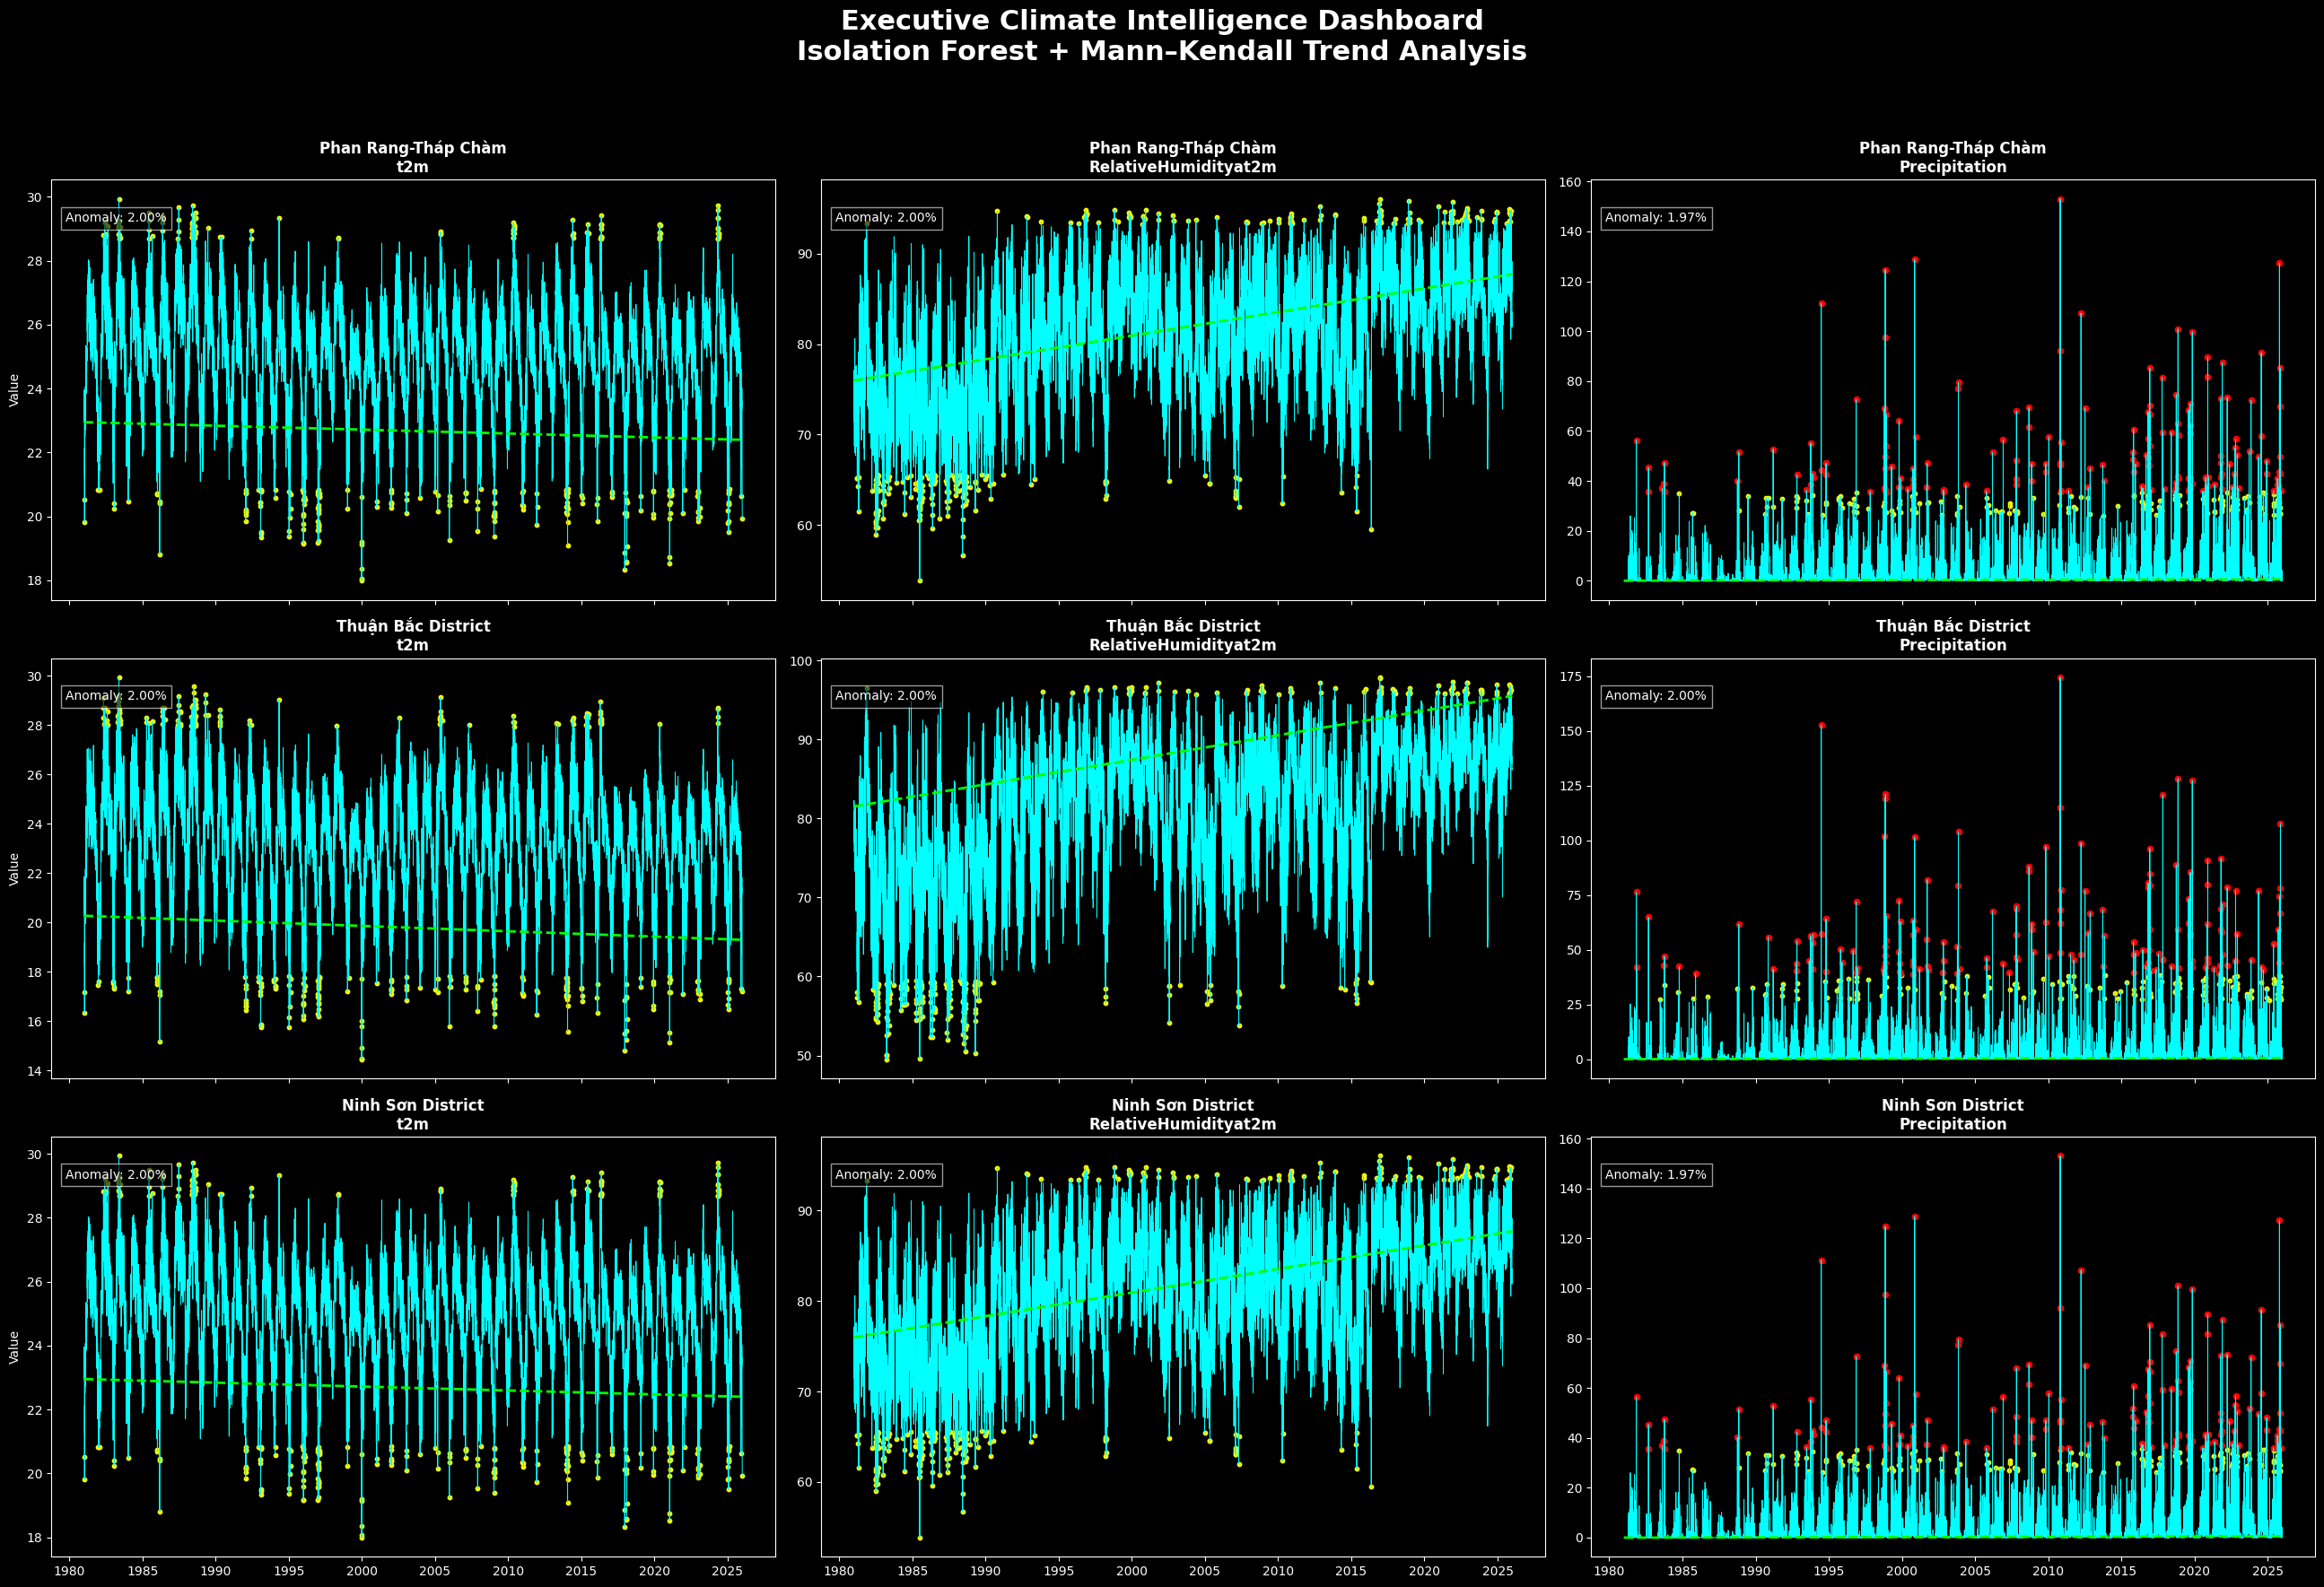

Saved as: Executive_Climate_Dashboard_All_Cities.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
import pymannkendall as mk

# Create DATE column
df["DATE"] = pd.to_datetime(df["YEAR"].astype(str), format="%Y") + \
             pd.to_timedelta(df["DOY"] - 1, unit="D")

cities = df["Location"].unique()
variables = ["t2m", "RelativeHumidityat2m", "Precipitation"]

plt.style.use("dark_background")

fig, axes = plt.subplots(3, 3, figsize=(26, 18), sharex=True)

for i, city in enumerate(cities):

    city_df = df[df["Location"] == city].copy()
    city_df = city_df.sort_values("DATE")

    for j, var in enumerate(variables):

        ax = axes[i, j]

        # Isolation Forest
        iso = IsolationForest(contamination=0.02, random_state=42)
        city_df["Anomaly"] = iso.fit_predict(city_df[[var]])

        anomalies = city_df[city_df["Anomaly"] == -1]

        # Calculate anomaly %
        anomaly_percent = (len(anomalies) / len(city_df)) * 100

        # Base line plot
        ax.plot(city_df["DATE"], city_df[var],
                color="cyan", linewidth=0.7)

        # Standard anomalies
        ax.scatter(anomalies["DATE"], anomalies[var],
                   color="yellow", s=10, label="Anomaly")

        # Extra highlight extreme rainfall spikes
        if var == "Precipitation":
            threshold = city_df[var].quantile(0.99)
            extreme = city_df[city_df[var] > threshold]

            ax.scatter(extreme["DATE"], extreme[var],
                       color="red", s=20, label="Extreme Spike")

        # Mann-Kendall Trend
        mk_result = mk.original_test(city_df[var])
        slope = mk_result.slope

        x = np.arange(len(city_df))
        trend_line = slope * x + city_df[var].iloc[0]

        ax.plot(city_df["DATE"], trend_line,
                color="lime", linewidth=2, linestyle="--",
                label="MK Trend")

        # Panel Title
        ax.set_title(f"{city}\n{var}",
                     fontsize=12, fontweight="bold")

        # Add anomaly percentage text
        ax.text(0.02, 0.90,
                f"Anomaly: {anomaly_percent:.2f}%",
                transform=ax.transAxes,
                fontsize=10,
                color="white",
                bbox=dict(facecolor="black", alpha=0.6))

        if j == 0:
            ax.set_ylabel("Value")

# Global Title
plt.suptitle(
    "Executive Climate Intelligence Dashboard\nIsolation Forest + Mann–Kendall Trend Analysis",
    fontsize=22, fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("Executive_Climate_Dashboard_All_Cities.png",
            dpi=600, bbox_inches="tight")

plt.show()

print("Saved as: Executive_Climate_Dashboard_All_Cities.png")


In [ ]:
from google.colab import files
files.download("Executive_Climate_Dashboard_All_Cities.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install statsmodels


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA


In [ ]:
city = monthly_data["Location"].unique()[0]

city_df = monthly_data[
    monthly_data["Location"] == city
].copy()

city_df = city_df.set_index("YearMonth")
city_df = city_df.asfreq("MS")

wb = city_df["WaterBalance"].dropna()


In [ ]:
stl = STL(wb, period=12)
res = stl.fit()

trend = res.trend
seasonal = res.seasonal
residual = res.resid


In [ ]:
model = ARIMA(residual, order=(1,0,1))
results = model.fit()


In [ ]:
forecast_steps = 20 * 12

residual_forecast = results.forecast(steps=forecast_steps)


In [ ]:
simulations = 1000
residual_simulations = []

historical_residuals = residual.values

for i in range(simulations):
    sampled_noise = np.random.choice(
        historical_residuals,
        size=forecast_steps,
        replace=True
    )
    sim = residual_forecast.values + sampled_noise
    residual_simulations.append(sim)

residual_simulations = np.array(residual_simulations)


In [ ]:
x = np.arange(len(trend))
slope = np.polyfit(x, trend, 1)[0]

future_x = np.arange(len(trend), len(trend) + forecast_steps)
trend_future = trend.iloc[-1] + slope * (future_x - future_x[0])


In [ ]:
seasonal_pattern = seasonal[-12:].values
seasonal_future = np.tile(seasonal_pattern, 20)


In [ ]:
wb_future_sim = residual_simulations + trend_future + seasonal_future


In [ ]:
hist_mean = wb.mean()
hist_std = wb.std()

spei_hist = (wb - hist_mean) / hist_std
spei_future = (wb_future_sim - hist_mean) / hist_std


In [ ]:
severe_threshold = -1.5
moderate_threshold = -1.0

severe_prob = (spei_future < severe_threshold).mean()
moderate_prob = (spei_future < moderate_threshold).mean()

expected_severe_months = \
    (spei_future < severe_threshold).sum(axis=1).mean()

print("Probability Severe Drought:", severe_prob)
print("Probability Moderate Drought:", moderate_prob)
print("Expected Severe Drought Months (20 yrs):",
      expected_severe_months)


Probability Severe Drought: 0.00034166666666666666
Probability Moderate Drought: 0.003033333333333333
Expected Severe Drought Months (20 yrs): 0.082


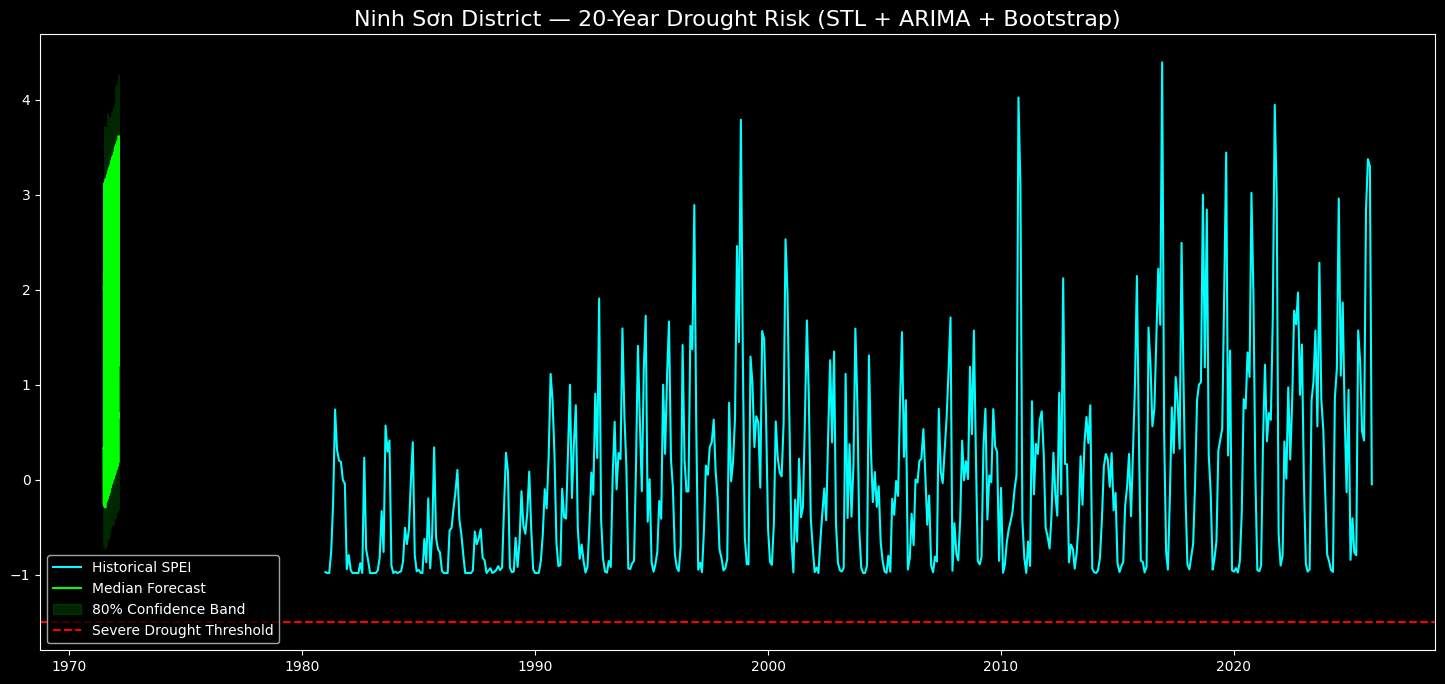

In [ ]:
plt.style.use("dark_background")

median_forecast = np.median(spei_future, axis=0)
p10 = np.percentile(spei_future, 10, axis=0)
p90 = np.percentile(spei_future, 90, axis=0)

future_time = np.arange(len(spei_hist),
                        len(spei_hist) + forecast_steps)

plt.figure(figsize=(18,8))

plt.plot(spei_hist.index,
         spei_hist,
         color="cyan",
         label="Historical SPEI")

plt.plot(future_time,
         median_forecast,
         color="lime",
         label="Median Forecast")

plt.fill_between(future_time,
                 p10,
                 p90,
                 color="green",
                 alpha=0.3,
                 label="80% Confidence Band")

plt.axhline(-1.5,
            color="red",
            linestyle="--",
            label="Severe Drought Threshold")

plt.legend()
plt.title(f"{city} — 20-Year Drought Risk (STL + ARIMA + Bootstrap)",
          fontsize=16)
plt.show()


In [ ]:
# Create DATE
df["DATE"] = pd.to_datetime(df["YEAR"].astype(str), format="%Y") + \
             pd.to_timedelta(df["DOY"] - 1, unit="D")

df = df.sort_values("DATE")

# Monthly aggregation
monthly = df.copy()
monthly["YearMonth"] = monthly["DATE"].dt.to_period("M")

monthly_data = monthly.groupby(
    ["Location", "YearMonth"]
).agg({
    "Precipitation": "sum",
    "t2m": "mean"
}).reset_index()

monthly_data["YearMonth"] = monthly_data["YearMonth"].dt.to_timestamp()

# PET
def thornthwaite_pet(temp):
    temp = np.maximum(temp, 0)
    I = np.sum((temp / 5) ** 1.514)
    a = (6.75e-7)*(I**3) - (7.71e-5)*(I**2) + (1.79e-2)*I + 0.492
    PET = 16 * ((10 * temp / I) ** a)
    return PET

monthly_data["PET"] = monthly_data.groupby("Location")["t2m"].transform(
    lambda x: thornthwaite_pet(x.values)
)

monthly_data["WaterBalance"] = \
    monthly_data["Precipitation"] - monthly_data["PET"]


In [ ]:
city = monthly_data["Location"].unique()[0]

city_df = monthly_data[
    monthly_data["Location"] == city
].copy()

city_df = city_df.set_index("YearMonth")
city_df = city_df.asfreq("MS")

wb = city_df["WaterBalance"].dropna()


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

model1 = SARIMAX(
    wb,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

res1 = model1.fit(disp=False)

forecast_steps = 20 * 12

forecast_obj = res1.get_forecast(steps=forecast_steps)
wb_forecast_mean = forecast_obj.predicted_mean

residual_std = np.std(res1.resid)

simulations = 1000
wb_future_model1 = []

for i in range(simulations):
    noise = np.random.normal(0, residual_std, forecast_steps)
    sim = wb_forecast_mean.values + noise
    wb_future_model1.append(sim)

wb_future_model1 = np.array(wb_future_model1)


In [ ]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA

stl = STL(wb, period=12)
res_stl = stl.fit()

trend = res_stl.trend
seasonal = res_stl.seasonal
residual = res_stl.resid

model2 = ARIMA(residual, order=(1,0,1))
res2 = model2.fit()

residual_forecast = res2.forecast(steps=forecast_steps)

historical_residuals = residual.values

wb_future_model2 = []

for i in range(simulations):
    sampled_noise = np.random.choice(
        historical_residuals,
        size=forecast_steps,
        replace=True
    )
    sim_res = residual_forecast.values + sampled_noise
    wb_future_model2.append(sim_res)

wb_future_model2 = np.array(wb_future_model2)

# Extend trend
x = np.arange(len(trend))
slope = np.polyfit(x, trend, 1)[0]

future_x = np.arange(len(trend), len(trend) + forecast_steps)
trend_future = trend.iloc[-1] + slope * (future_x - future_x[0])

# Repeat seasonal
seasonal_pattern = seasonal[-12:].values
seasonal_future = np.tile(seasonal_pattern, 20)

wb_future_model2 = wb_future_model2 + trend_future + seasonal_future


In [ ]:
hist_mean = wb.mean()
hist_std = wb.std()

spei_future_model1 = (wb_future_model1 - hist_mean) / hist_std
spei_future_model2 = (wb_future_model2 - hist_mean) / hist_std


In [ ]:
severe_threshold = -1.5

severe_prob1 = (spei_future_model1 < severe_threshold).mean()
severe_prob2 = (spei_future_model2 < severe_threshold).mean()

expected_severe1 = \
    (spei_future_model1 < severe_threshold).sum(axis=1).mean()

expected_severe2 = \
    (spei_future_model2 < severe_threshold).sum(axis=1).mean()

print("===== MODEL COMPARISON =====")
print("Model 1 Severe Probability:", severe_prob1)
print("Model 1 Expected Severe Months:", expected_severe1)

print("Model 2 Severe Probability:", severe_prob2)
print("Model 2 Expected Severe Months:", expected_severe2)

print("Model 1 Future Mean:", spei_future_model1.mean())
print("Model 2 Future Mean:", spei_future_model2.mean())

print("Model 1 Future Std:", spei_future_model1.std())
print("Model 2 Future Std:", spei_future_model2.std())


===== MODEL COMPARISON =====
Model 1 Severe Probability: 0.004333333333333333
Model 1 Expected Severe Months: 1.04
Model 2 Severe Probability: 0.00034583333333333335
Model 2 Expected Severe Months: 0.083
Model 1 Future Mean: 1.1508614939328425
Model 2 Future Mean: 1.5756580095730257
Model 1 Future Std: 1.1094491429872122
Model 2 Future Std: 1.1960066750536646


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
import numpy as np

# In-sample fitted values
fitted1 = res1.fittedvalues

rmse1 = np.sqrt(mean_squared_error(wb[1:], fitted1[1:]))
mae1 = mean_absolute_error(wb[1:], fitted1[1:])

aic1 = res1.aic
bic1 = res1.bic

lb1 = acorr_ljungbox(res1.resid, lags=[12], return_df=True)
jb1 = jarque_bera(res1.resid)

print("===== SARIMA MODEL =====")
print("RMSE:", rmse1)
print("MAE:", mae1)
print("AIC:", aic1)
print("BIC:", bic1)
print("Ljung-Box p-value:", lb1["lb_pvalue"].values[0])
print("Jarque-Bera p-value:", jb1[1])


===== SARIMA MODEL =====
RMSE: 70.58963305121046
MAE: 48.99820375073474
AIC: 5852.96822525473
BIC: 5874.169604480584
Ljung-Box p-value: 0.25669676313484785
Jarque-Bera p-value: 8.507302803565468e-228


In [ ]:
# Reconstruct fitted values
fitted2 = trend + seasonal + res2.fittedvalues

rmse2 = np.sqrt(mean_squared_error(wb, fitted2))
mae2 = mean_absolute_error(wb, fitted2)

aic2 = res2.aic
bic2 = res2.bic

lb2 = acorr_ljungbox(res2.resid, lags=[12], return_df=True)
jb2 = jarque_bera(res2.resid)

print("\n===== STL + ARIMA MODEL =====")
print("RMSE:", rmse2)
print("MAE:", mae2)
print("AIC:", aic2)
print("BIC:", bic2)
print("Ljung-Box p-value:", lb2["lb_pvalue"].values[0])
print("Jarque-Bera p-value:", jb2[1])



===== STL + ARIMA MODEL =====
RMSE: 45.34124556984397
MAE: 32.32133858638896
AIC: 5661.837882252853
BIC: 5679.004158811086
Ljung-Box p-value: 3.0839535217947555e-29
Jarque-Bera p-value: 2.0889520599847547e-47


In [ ]:
import pandas as pd

comparison_table = pd.DataFrame({
    "Metric": [
        "RMSE", "MAE", "AIC", "BIC",
        "Ljung-Box p", "Jarque-Bera p",
        "Severe Prob", "Expected Severe Months"
    ],
    "SARIMA": [
        rmse1, mae1, aic1, bic1,
        lb1["lb_pvalue"].values[0], jb1[1],
        severe_prob1, expected_severe1
    ],
    "STL + ARIMA": [
        rmse2, mae2, aic2, bic2,
        lb2["lb_pvalue"].values[0], jb2[1],
        severe_prob2, expected_severe2
    ]
})

print(comparison_table)


                   Metric         SARIMA   STL + ARIMA
0                    RMSE   7.058963e+01  4.534125e+01
1                     MAE   4.899820e+01  3.232134e+01
2                     AIC   5.852968e+03  5.661838e+03
3                     BIC   5.874170e+03  5.679004e+03
4             Ljung-Box p   2.566968e-01  3.083954e-29
5           Jarque-Bera p  8.507303e-228  2.088952e-47
6             Severe Prob   4.333333e-03  3.458333e-04
7  Expected Severe Months   1.040000e+00  8.300000e-02


In [ ]:
split_index = int(len(wb) * 0.8)

wb_train = wb.iloc[:split_index]
wb_test = wb.iloc[split_index:]


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

model1 = SARIMAX(
    wb_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

res1 = model1.fit(disp=False)

forecast_test1 = res1.forecast(steps=len(wb_test))

rmse1_test = np.sqrt(mean_squared_error(wb_test, forecast_test1))
mae1_test = mean_absolute_error(wb_test, forecast_test1)

print("SARIMA Test RMSE:", rmse1_test)
print("SARIMA Test MAE:", mae1_test)


SARIMA Test RMSE: 137.64841269324575
SARIMA Test MAE: 120.92595578831785


In [ ]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA

# STL on training
stl_train = STL(wb_train, period=12)
res_stl_train = stl_train.fit()

trend_train = res_stl_train.trend
seasonal_train = res_stl_train.seasonal
residual_train = res_stl_train.resid

# ARIMA on residual
model2 = ARIMA(residual_train, order=(1,0,1))
res2 = model2.fit()

# Forecast residual
residual_forecast_test = res2.forecast(steps=len(wb_test))

# Extend trend linearly
x = np.arange(len(trend_train))
slope = np.polyfit(x, trend_train, 1)[0]

future_x = np.arange(len(trend_train), len(trend_train)+len(wb_test))
trend_future_test = trend_train.iloc[-1] + slope * (future_x - future_x[0])

# Repeat seasonal pattern
seasonal_pattern = seasonal_train[-12:].values
seasonal_future_test = np.tile(
    seasonal_pattern,
    int(np.ceil(len(wb_test)/12))
)[:len(wb_test)]

forecast_test2 = (
    trend_future_test +
    seasonal_future_test +
    residual_forecast_test.values
)

rmse2_test = np.sqrt(mean_squared_error(wb_test, forecast_test2))
mae2_test = mean_absolute_error(wb_test, forecast_test2)

print("STL+ARIMA Test RMSE:", rmse2_test)
print("STL+ARIMA Test MAE:", mae2_test)


STL+ARIMA Test RMSE: 169.42334687933337
STL+ARIMA Test MAE: 138.12069118358988


In [ ]:
# Training fitted values

fitted1_train = res1.fittedvalues
rmse1_train = np.sqrt(mean_squared_error(wb_train[1:], fitted1_train[1:]))
mae1_train = mean_absolute_error(wb_train[1:], fitted1_train[1:])

fitted2_train = trend_train + seasonal_train + res2.fittedvalues
rmse2_train = np.sqrt(mean_squared_error(wb_train, fitted2_train))
mae2_train = mean_absolute_error(wb_train, fitted2_train)

print("\n=== TRAIN PERFORMANCE ===")
print("SARIMA RMSE:", rmse1_train)
print("SARIMA MAE:", mae1_train)
print("STL+ARIMA RMSE:", rmse2_train)
print("STL+ARIMA MAE:", mae2_train)



=== TRAIN PERFORMANCE ===
SARIMA RMSE: 65.86023991024489
SARIMA MAE: 43.98318093651038
STL+ARIMA RMSE: 40.465482961110006
STL+ARIMA MAE: 28.883742158000683


In [ ]:
from sklearn.metrics import r2_score

r2_1_test = r2_score(wb_test, forecast_test1)
r2_2_test = r2_score(wb_test, forecast_test2)

print("\nR² SARIMA Test:", r2_1_test)
print("R² STL+ARIMA Test:", r2_2_test)



R² SARIMA Test: -0.0684342405087166
R² STL+ARIMA Test: -0.6186460650714154


In [ ]:
from scipy.stats import ttest_rel

residuals1 = wb_test - forecast_test1
residuals2 = wb_test - forecast_test2

t_stat, p_value = ttest_rel(residuals1, residuals2)

print("\nPaired t-test p-value (test residuals):", p_value)



Paired t-test p-value (test residuals): 0.07329219794744879


In [ ]:
import pandas as pd

evaluation_table = pd.DataFrame({
    "Metric": [
        "Train RMSE", "Train MAE",
        "Test RMSE", "Test MAE",
        "Test R²"
    ],
    "SARIMA": [
        rmse1_train, mae1_train,
        rmse1_test, mae1_test,
        r2_1_test
    ],
    "STL+ARIMA": [
        rmse2_train, mae2_train,
        rmse2_test, mae2_test,
        r2_2_test
    ]
})

print("\n===== FINAL STATISTICAL EVALUATION =====")
print(evaluation_table)



===== FINAL STATISTICAL EVALUATION =====
       Metric      SARIMA   STL+ARIMA
0  Train RMSE   65.860240   40.465483
1   Train MAE   43.983181   28.883742
2   Test RMSE  137.648413  169.423347
3    Test MAE  120.925956  138.120691
4     Test R²   -0.068434   -0.618646


In [ ]:
import pandas as pd

file = "datatoshafi.xlsx"   # make sure file is uploaded
all_sheets = pd.read_excel(file, sheet_name=None)

df = pd.concat(all_sheets.values(), ignore_index=True)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (49308, 9)


In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [ ]:
# If DATE is already index, remove it first
if df.index.name == "DATE":
    df = df.reset_index(drop=True)

# If duplicate DATE column exists, remove duplicates
df = df.loc[:, ~df.columns.duplicated()]

# Now recreate DATE cleanly
df["DATE"] = pd.to_datetime(df["YEAR"].astype(str)) + \
             pd.to_timedelta(df["DOY"] - 1, unit="D")

# Sort and set index properly
df = df.sort_values("DATE")
df = df.set_index("DATE")


In [ ]:
temp = np.maximum(df["t2m"].values, 0)

I = (temp / 5) ** 1.514
I_sum = pd.Series(I, index=df.index).rolling(365, min_periods=30).sum().bfill()

a = (6.75e-7)*(I_sum**3) - (7.71e-5)*(I_sum**2) + (1.79e-2)*I_sum + 0.492

PET_daily = 16 * ((10 * temp / I_sum) ** a)

df["PET"] = PET_daily


In [ ]:
df["WaterBalance"] = df["Precipitation"] - df["PET"]


In [ ]:
data = df.copy()

# Time features
data["dayofyear"] = data.index.dayofyear
data["year"] = data.index.year

# Cyclical encoding
data["sin_doy"] = np.sin(2*np.pi*data["dayofyear"]/365)
data["cos_doy"] = np.cos(2*np.pi*data["dayofyear"]/365)

# Lag features
for lag in [1, 7, 30, 90, 365]:
    data[f"lag_{lag}"] = data["WaterBalance"].shift(lag)

# Rolling features
for window in [7, 30, 90]:
    data[f"roll_mean_{window}"] = data["WaterBalance"].rolling(window).mean()
    data[f"roll_std_{window}"] = data["WaterBalance"].rolling(window).std()

data = data.dropna()


In [ ]:
split = int(len(data) * 0.8)

train = data.iloc[:split]
test = data.iloc[split:]

X_train = train.drop(columns=["WaterBalance", "Location", "Climate"], errors="ignore")
y_train = train["WaterBalance"]

X_test = test.drop(columns=["WaterBalance", "Location", "Climate"], errors="ignore")
y_test = test["WaterBalance"]

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 39154
Test size: 9789


In [ ]:
model_xgb = XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_test)

r2_xgb = r2_score(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

print("\n===== XGBOOST RESULTS =====")
print("R²:", r2_xgb)
print("RMSE:", rmse_xgb)



===== XGBOOST RESULTS =====
R²: 0.9752762823465612
RMSE: 1.5737165262070394


In [ ]:
# ===============================
# FIX DUPLICATE DATE ISSUE
# ===============================

# Choose one city first
city_name = df["Location"].unique()[0]

df_city = df[df["Location"] == city_name].copy()

# Remove DATE from index if exists
if df_city.index.name == "DATE":
    df_city = df_city.reset_index(drop=True)

# Recreate DATE cleanly
df_city["DATE"] = pd.to_datetime(df_city["YEAR"].astype(str)) + \
                  pd.to_timedelta(df_city["DOY"] - 1, unit="D")

df_city = df_city.sort_values("DATE")
df_city = df_city.set_index("DATE")

# NOW frequency works because only one city
df_city = df_city.asfreq("D")

print("Frequency:", df_city.index.freq)
print("Duplicate dates:", df_city.index.duplicated().sum())


Frequency: <Day>
Duplicate dates: 0


In [ ]:
import pandas as pd

df = pd.read_excel("datatoshafi.xlsx")


In [ ]:
# =========================================================
# COMPLETE DAILY CLEAN MODELING PIPELINE (PER CITY)
# =========================================================

import pandas as pd
import numpy as np

# -----------------------------
# 1️⃣ Select One City
# -----------------------------
city_name = df["Location"].unique()[0]
df_city = df[df["Location"] == city_name].copy()

# -----------------------------
# 2️⃣ Clean DATE Structure
# -----------------------------
if df_city.index.name == "DATE":
    df_city = df_city.reset_index(drop=True)

df_city["DATE"] = pd.to_datetime(df_city["YEAR"].astype(str)) + \
                  pd.to_timedelta(df_city["DOY"] - 1, unit="D")

df_city = df_city.sort_values("DATE")
df_city = df_city.set_index("DATE")

# Ensure unique daily index
df_city = df_city[~df_city.index.duplicated(keep="first")]

# Force DAILY frequency
df_city.index = pd.DatetimeIndex(df_city.index, freq="D")

# -----------------------------
# 3️⃣ Compute Daily PET
# -----------------------------
temp = np.maximum(df_city["t2m"].values, 0)

I = (temp / 5) ** 1.514
I_sum = pd.Series(I, index=df_city.index).rolling(365, min_periods=30).sum().bfill()

a = (6.75e-7)*(I_sum**3) - (7.71e-5)*(I_sum**2) + (1.79e-2)*I_sum + 0.492
PET_daily = 16 * ((10 * temp / I_sum) ** a)

df_city["PET"] = PET_daily

# -----------------------------
# 4️⃣ Create Water Balance
# -----------------------------
df_city["WaterBalance"] = df_city["Precipitation"] - df_city["PET"]

# -----------------------------
# 5️⃣ Feature Engineering
# -----------------------------
data = df_city.copy()

# Time features
data["dayofyear"] = data.index.dayofyear
data["year"] = data.index.year

# Cyclical encoding (important)
data["sin_doy"] = np.sin(2*np.pi*data["dayofyear"]/365)
data["cos_doy"] = np.cos(2*np.pi*data["dayofyear"]/365)

# Lag features
for lag in [1, 7, 30, 90, 365]:
    data[f"lag_{lag}"] = data["WaterBalance"].shift(lag)

# Rolling features
for window in [7, 30, 90]:
    data[f"roll_mean_{window}"] = data["WaterBalance"].rolling(window).mean()
    data[f"roll_std_{window}"] = data["WaterBalance"].rolling(window).std()

# Drop NA introduced by lags/rolling
data = data.dropna()

# Restore DAILY frequency after dropna
data.index = pd.DatetimeIndex(data.index, freq="D")

# -----------------------------
# 6️⃣ Final Check
# -----------------------------
print("City:", city_name)
print("Rows:", len(data))
print("Frequency:", data.index.freq)
print("Duplicate dates:", data.index.duplicated().sum())
print("Columns:", data.columns.tolist())


City: Phan Rang-Tháp Chàm
Rows: 16071
Frequency: <Day>
Duplicate dates: 0
Columns: ['Location', 'Climate', 'YEAR', 'DOY', 'Precipitation', 'RelativeHumidityat2m', 'tmin2m', 'tmax2m', 't2m', 'PET', 'WaterBalance', 'dayofyear', 'year', 'sin_doy', 'cos_doy', 'lag_1', 'lag_7', 'lag_30', 'lag_90', 'lag_365', 'roll_mean_7', 'roll_std_7', 'roll_mean_30', 'roll_std_30', 'roll_mean_90', 'roll_std_90']


In [ ]:
# =========================================================
# SARIMAX DAILY MODEL (STABLE VERSION)
# =========================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# -----------------------------
# 1️⃣ Define Target
# -----------------------------
y = data["WaterBalance"]

# -----------------------------
# 2️⃣ Train/Test Split (Time-Based 80-20)
# -----------------------------
split = int(len(y) * 0.8)

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Train size:", len(y_train))
print("Test size:", len(y_test))

# -----------------------------
# 3️⃣ Fit SARIMAX
# Weekly seasonality = 7
# -----------------------------
sarimax_model = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),   # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False)

print("\n===== SARIMAX MODEL SUMMARY =====")
print(sarimax_result.summary())

# -----------------------------
# 4️⃣ Forecast Test Period
# -----------------------------
forecast = sarimax_result.forecast(steps=len(y_test))

# -----------------------------
# 5️⃣ Evaluate Performance
# -----------------------------
r2_sarimax = r2_score(y_test, forecast)
rmse_sarimax = np.sqrt(mean_squared_error(y_test, forecast))

print("\n===== SARIMAX PERFORMANCE =====")
print("R²:", r2_sarimax)
print("RMSE:", rmse_sarimax)


Train size: 12856
Test size: 3215

===== SARIMAX MODEL SUMMARY =====
                                     SARIMAX Results                                     
Dep. Variable:                      WaterBalance   No. Observations:                12856
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -40325.505
Date:                           Sat, 21 Feb 2026   AIC                          80661.009
Time:                                   09:14:35   BIC                          80698.310
Sample:                               01-01-1982   HQIC                         80673.480
                                    - 03-13-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4765      0.003    160.410      0.00

In [ ]:
# =========================================================
# COMPLETE DAILY MODEL COMPARISON (XGBoost vs SARIMAX)
# =========================================================

import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -----------------------------
# 1️⃣ Load Dataset
# -----------------------------
df = pd.read_excel("datatoshafi.xlsx")

# -----------------------------
# 2️⃣ Select One City
# -----------------------------
city_name = df["Location"].unique()[0]
df_city = df[df["Location"] == city_name].copy()

# -----------------------------
# 3️⃣ Create DATE Index
# -----------------------------
df_city["DATE"] = pd.to_datetime(df_city["YEAR"].astype(str)) + \
                  pd.to_timedelta(df_city["DOY"] - 1, unit="D")

df_city = df_city.sort_values("DATE")
df_city = df_city.set_index("DATE")
df_city = df_city[~df_city.index.duplicated()]
df_city.index = pd.DatetimeIndex(df_city.index, freq="D")

# -----------------------------
# 4️⃣ Compute Daily PET
# -----------------------------
temp = np.maximum(df_city["t2m"].values, 0)

I = (temp / 5) ** 1.514
I_sum = pd.Series(I, index=df_city.index).rolling(365, min_periods=30).sum().bfill()

a = (6.75e-7)*(I_sum**3) - (7.71e-5)*(I_sum**2) + (1.79e-2)*I_sum + 0.492
PET_daily = 16 * ((10 * temp / I_sum) ** a)

df_city["PET"] = PET_daily
df_city["WaterBalance"] = df_city["Precipitation"] - df_city["PET"]

# -----------------------------
# 5️⃣ Feature Engineering
# -----------------------------
data = df_city.copy()

data["dayofyear"] = data.index.dayofyear
data["year"] = data.index.year
data["sin_doy"] = np.sin(2*np.pi*data["dayofyear"]/365)
data["cos_doy"] = np.cos(2*np.pi*data["dayofyear"]/365)

for lag in [1, 7, 30, 90, 365]:
    data[f"lag_{lag}"] = data["WaterBalance"].shift(lag)

for window in [7, 30, 90]:
    data[f"roll_mean_{window}"] = data["WaterBalance"].rolling(window).mean()
    data[f"roll_std_{window}"] = data["WaterBalance"].rolling(window).std()

data = data.dropna()
data.index = pd.DatetimeIndex(data.index, freq="D")

# -----------------------------
# 6️⃣ Train/Test Split
# -----------------------------
split = int(len(data) * 0.8)

train = data.iloc[:split]
test = data.iloc[split:]

X_train = train.drop(columns=["WaterBalance", "Location", "Climate"], errors="ignore")
y_train = train["WaterBalance"]

X_test = test.drop(columns=["WaterBalance", "Location", "Climate"], errors="ignore")
y_test = test["WaterBalance"]

# -----------------------------
# 7️⃣ XGBoost Model
# -----------------------------
model_xgb = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)

r2_xgb = r2_score(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

# -----------------------------
# 8️⃣ SARIMAX Model (Weekly Seasonality)
# -----------------------------
sarimax_model = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_result = sarimax_model.fit(disp=False)
pred_sarimax = sarimax_result.forecast(steps=len(y_test))

r2_sarimax = r2_score(y_test, pred_sarimax)
rmse_sarimax = np.sqrt(mean_squared_error(y_test, pred_sarimax))

# -----------------------------
# 9️⃣ Compare Models
# -----------------------------
comparison = pd.DataFrame({
    "Model": ["XGBoost", "SARIMAX"],
    "R²": [r2_xgb, r2_sarimax],
    "RMSE": [rmse_xgb, rmse_sarimax]
})

print("\n===== FINAL MODEL COMPARISON =====")
print(comparison)



===== FINAL MODEL COMPARISON =====
     Model        R²       RMSE
0  XGBoost  0.977705   1.482975
1  SARIMAX -0.121308  10.516946


In [ ]:
# ===============================
# XGBoost TRAIN & TEST METRICS
# ===============================

# --- Train predictions ---
train_pred = model_xgb.predict(X_train)

r2_train = r2_score(y_train, train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, train_pred))

# --- Test predictions ---
test_pred = model_xgb.predict(X_test)

r2_test = r2_score(y_test, test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))

# --- Print results ---
print("===== XGBoost Performance =====")
print("Train R²:", r2_train)
print("Train RMSE:", rmse_train)
print("Test R²:", r2_test)
print("Test RMSE:", rmse_test)


===== XGBoost Performance =====
Train R²: 0.9998933211444784
Train RMSE: 0.07018725390335126
Test R²: 0.9777047037703879
Test RMSE: 1.4829746606028331


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_xgb.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.head(15))


                 Feature  Importance
2          Precipitation    0.727282
18            roll_std_7    0.072207
3   RelativeHumidityat2m    0.043081
12                 lag_1    0.025725
17           roll_mean_7    0.024484
5                 tmax2m    0.017969
9                   year    0.014993
15                lag_90    0.012175
11               cos_doy    0.010901
13                 lag_7    0.009477
22           roll_std_90    0.007512
4                 tmin2m    0.004668
14                lag_30    0.004390
1                    DOY    0.004288
20           roll_std_30    0.003753


In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model_xgb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

print(perm_importance.head(15))


                 Feature  Importance
2          Precipitation    1.616916
18            roll_std_7    0.052756
5                 tmax2m    0.002882
4                 tmin2m    0.001560
3   RelativeHumidityat2m    0.001272
22           roll_std_90    0.001214
20           roll_std_30    0.001011
12                 lag_1    0.000754
1                    DOY    0.000725
17           roll_mean_7    0.000719
16               lag_365    0.000478
15                lag_90    0.000176
11               cos_doy    0.000022
9                   year    0.000000
0                   YEAR    0.000000


In [ ]:
no_lag_cols = [col for col in X_train.columns if "lag" not in col]

X_train_no_lag = X_train[no_lag_cols]
X_test_no_lag = X_test[no_lag_cols]

model_no_lag = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_no_lag.fit(X_train_no_lag, y_train)

pred_no_lag = model_no_lag.predict(X_test_no_lag)

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R² without lag:", r2_score(y_test, pred_no_lag))
print("RMSE without lag:", np.sqrt(mean_squared_error(y_test, pred_no_lag)))


R² without lag: 0.9790731107475278
RMSE without lag: 1.43674417427544


In [ ]:
no_roll_cols = [col for col in X_train.columns if "roll" not in col]

X_train_no_roll = X_train[no_roll_cols]
X_test_no_roll = X_test[no_roll_cols]

model_no_roll = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_no_roll.fit(X_train_no_roll, y_train)

pred_no_roll = model_no_roll.predict(X_test_no_roll)

print("R² without rolling:", r2_score(y_test, pred_no_roll))
print("RMSE without rolling:", np.sqrt(mean_squared_error(y_test, pred_no_roll)))


R² without rolling: 0.9592953040007897
RMSE without rolling: 2.0037768952914417


In [ ]:
# ===============================
# MONTHLY WATER BALANCE
# ===============================

monthly_wb = df_city["WaterBalance"].resample("MS").sum()

print("Monthly rows:", len(monthly_wb))


Monthly rows: 540


In [ ]:
# ===============================
# COMPUTE SPEI-12
# ===============================

# Standardize monthly WB
wb_mean = monthly_wb.mean()
wb_std = monthly_wb.std()

wb_z = (monthly_wb - wb_mean) / wb_std

# 12-month rolling mean (long-term drought)
spei_12 = wb_z.rolling(12).mean().dropna()

print("SPEI length:", len(spei_12))


SPEI length: 529


In [ ]:
from sklearn.ensemble import IsolationForest

# Fit anomaly model
iso = IsolationForest(contamination=0.05, random_state=42)
spei_vals = spei_12.values.reshape(-1, 1)

anomaly_labels = iso.fit_predict(spei_vals)

# -1 = anomaly
spei_anomaly = pd.Series(anomaly_labels, index=spei_12.index)

print("Total anomalies:", (spei_anomaly == -1).sum())


Total anomalies: 27


In [ ]:
monthly_df = pd.DataFrame({"WB": monthly_wb})

monthly_df["month"] = monthly_df.index.month
monthly_df["year"] = monthly_df.index.year

monthly_df["sin_month"] = np.sin(2*np.pi*monthly_df["month"]/12)
monthly_df["cos_month"] = np.cos(2*np.pi*monthly_df["month"]/12)

for lag in [1, 3, 6, 12]:
    monthly_df[f"lag_{lag}"] = monthly_df["WB"].shift(lag)

for window in [3, 6, 12]:
    monthly_df[f"roll_mean_{window}"] = monthly_df["WB"].rolling(window).mean()

monthly_df = monthly_df.dropna()


In [ ]:
split = int(len(monthly_df) * 0.8)

train_m = monthly_df.iloc[:split]
test_m = monthly_df.iloc[split:]

X_train_m = train_m.drop(columns=["WB"])
y_train_m = train_m["WB"]

X_test_m = test_m.drop(columns=["WB"])
y_test_m = test_m["WB"]


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

model_monthly = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model_monthly.fit(X_train_m, y_train_m)

pred_test_m = model_monthly.predict(X_test_m)

print("Monthly R²:", r2_score(y_test_m, pred_test_m))
print("Monthly RMSE:", np.sqrt(mean_squared_error(y_test_m, pred_test_m)))


Monthly R²: 0.7084236546179163
Monthly RMSE: 72.19503457098064


In [ ]:
# ===============================
# 20-YEAR MONTHLY FORECAST
# ===============================

future_steps = 240

last_data = monthly_df.copy()

future_predictions = []

for i in range(future_steps):

    last_row = last_data.iloc[-1:].copy()

    next_month = last_row.index[0] + pd.DateOffset(months=1)

    new_row = pd.DataFrame(index=[next_month])
    new_row["month"] = next_month.month
    new_row["year"] = next_month.year

    new_row["sin_month"] = np.sin(2*np.pi*new_row["month"]/12)
    new_row["cos_month"] = np.cos(2*np.pi*new_row["month"]/12)

    for lag in [1, 3, 6, 12]:
        new_row[f"lag_{lag}"] = last_data["WB"].iloc[-lag]

    for window in [3, 6, 12]:
        new_row[f"roll_mean_{window}"] = last_data["WB"].iloc[-window:].mean()

    pred = model_monthly.predict(new_row)[0]

    new_row["WB"] = pred

    future_predictions.append(pred)
    last_data = pd.concat([last_data, new_row])

future_wb = pd.Series(future_predictions,
                      index=pd.date_range(start=monthly_df.index[-1] + pd.DateOffset(months=1),
                                          periods=240,
                                          freq="MS"))


In [ ]:
future_wb_z = (future_wb - wb_mean) / wb_std
future_spei_12 = future_wb_z.rolling(12).mean().dropna()

print("Future Severe Drought Months:",
      (future_spei_12 < -1.5).sum())


Future Severe Drought Months: 0


In [ ]:
print(monthly_wb.std())


108.03366148145344


<Axes: xlabel='DATE'>

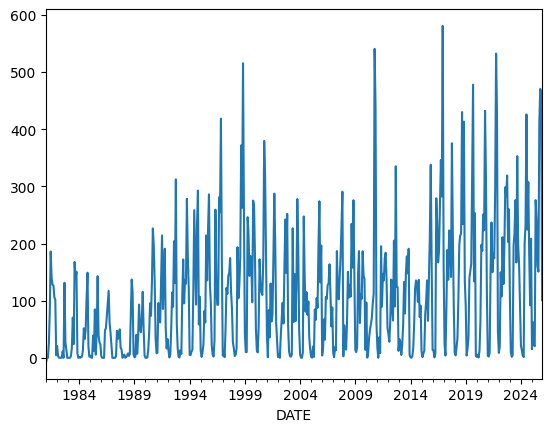

In [ ]:
monthly_wb.plot()


In [ ]:
print("Historical mean:", monthly_wb.mean())
print("Future mean:", future_wb.mean())


Historical mean: 106.04878958257763
Future mean: 129.18323


In [ ]:
print("Min future SPEI:", future_spei_12.min())
print("Mean future SPEI:", future_spei_12.mean())


Min future SPEI: 0.06124196108430624
Mean future SPEI: 0.20063213020864076


In [ ]:
# ===============================
# HARD RESET — REMOVE ANY DATE CONFLICT
# ===============================

df = df.copy()

# Completely remove index
df = df.reset_index(drop=True)

# Remove ANY existing DATE column
df = df.loc[:, ~df.columns.duplicated()]
if "DATE" in df.columns:
    df = df.drop(columns=["DATE"])

# Now safely create DATE
df["DATE"] = pd.to_datetime(df["YEAR"].astype(str), format="%Y") + \
             pd.to_timedelta(df["DOY"] - 1, unit="D")

# Sort and set index
df = df.sort_values("DATE")
df = df.set_index("DATE")

print("Index name:", df.index.name)
print("DATE in columns:", "DATE" in df.columns)
print("Duplicate index count:", df.index.duplicated().sum())


Index name: DATE
DATE in columns: False
Duplicate index count: 0


In [ ]:
# ==========================================
# FORCE REBUILD TIME INDEX (NO DATE COLUMN)
# ==========================================

df = df.copy()

# Completely remove index name
df.index.name = None

# Flatten dataframe fully
df = df.reset_index(drop=True)

# Now build datetime index directly (do NOT create DATE column)
new_index = pd.to_datetime(df["YEAR"].astype(str), format="%Y") + \
            pd.to_timedelta(df["DOY"] - 1, unit="D")

# Assign as index directly
df.index = new_index

# Remove any possible duplicate dates
df = df[~df.index.duplicated()]

# Final check
print("Index name:", df.index.name)
print("Duplicate dates:", df.index.duplicated().sum())
print(df.head())


Index name: None
Duplicate dates: 0
                       Location         Climate  YEAR  DOY  Precipitation  \
1981-01-01  Phan Rang-Tháp Chàm  Drought Center  1981    1            0.0   
1981-01-02  Phan Rang-Tháp Chàm  Drought Center  1981    2            0.0   
1981-01-03  Phan Rang-Tháp Chàm  Drought Center  1981    3            0.0   
1981-01-04  Phan Rang-Tháp Chàm  Drought Center  1981    4            0.0   
1981-01-05  Phan Rang-Tháp Chàm  Drought Center  1981    5            0.0   

            RelativeHumidityat2m  tmin2m  tmax2m    t2m       PET        WB  \
1981-01-01                 75.98   20.77   26.79  22.95  0.229961 -0.229961   
1981-01-02                 77.00   21.34   26.35  23.24  0.211278 -0.211278   
1981-01-03                 74.88   21.08   26.70  23.01  0.222517 -0.222517   
1981-01-04                 74.41   21.05   27.17  23.32  0.233968 -0.233968   
1981-01-05                 71.88   20.48   28.27  23.58  0.265636 -0.265636   

                 DATE  
19

In [ ]:
df = df.sort_index()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

# =====================================
# 1️⃣ PET + WATER BALANCE
# =====================================

if "PET" not in df.columns:
    df["PET"] = 0.0023 * (df["t2m"] + 17.8) * np.sqrt(df["tmax2m"] - df["tmin2m"])

df["WB"] = df["Precipitation"] - df["PET"]

# =====================================
# 2️⃣ FEATURE ENGINEERING FUNCTION
# =====================================

def create_features(data):
    data = data.copy()

    # Lags
    for lag in [1, 7, 30, 90, 365]:
        data[f"lag_{lag}"] = data["WB"].shift(lag)

    # Rolling
    data["roll_mean_30"] = data["WB"].rolling(30).mean()
    data["roll_std_30"] = data["WB"].rolling(30).std()

    # Seasonality
    data["sin_doy"] = np.sin(2*np.pi*data.index.dayofyear/365)
    data["cos_doy"] = np.cos(2*np.pi*data.index.dayofyear/365)

    return data.dropna()

# =====================================
# 3️⃣ DAILY & MONTHLY DATASETS
# =====================================

daily = create_features(df)

monthly_wb = df["WB"].resample("ME").sum()
monthly = create_features(monthly_wb.to_frame())

# =====================================
# 4️⃣ MODEL EVALUATION FUNCTION
# =====================================

def evaluate_model(data, split_ratio):

    data = data.select_dtypes(include=[np.number])

    split_index = int(len(data) * split_ratio)

    train = data.iloc[:split_index]
    test = data.iloc[split_index:]

    X_train = train.drop("WB", axis=1)
    y_train = train["WB"]
    X_test = test.drop("WB", axis=1)
    y_test = test["WB"]

    model = XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    return {
        "Train R²": r2_score(y_train, pred_train),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, pred_train)),
        "Test R²": r2_score(y_test, pred_test),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred_test))
    }

# =====================================
# 5️⃣ RUN ALL COMBINATIONS
# =====================================

results = []

for name, dataset in [("Daily", daily), ("Monthly", monthly)]:
    for ratio in [0.8, 0.7]:

        res = evaluate_model(dataset, ratio)

        results.append({
            "Dataset": name,
            "Split": f"{int(ratio*100)}-{int((1-ratio)*100)}",
            **res
        })

results_df = pd.DataFrame(results)

print("\n===== FINAL XGBOOST PERFORMANCE =====")
print(results_df)



===== FINAL XGBOOST PERFORMANCE =====
   Dataset  Split  Train R²  Train RMSE   Test R²  Test RMSE
0    Daily  80-19  0.999828    0.089454  0.969763   1.729808
1    Daily  70-30  0.999836    0.085163  0.971301   1.580286
2  Monthly  80-19  0.999991    0.372236  0.584483  89.818326
3  Monthly  70-30  0.999994    0.281111  0.486661  99.466747


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure datetime index already fixed earlier
monthly = df["WB"].resample("ME").sum().dropna()

print("Monthly samples:", len(monthly))


Monthly samples: 540


In [ ]:
model = SARIMAX(
    monthly,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = model.fit(disp=False)

print(sarima_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                                 WB   No. Observations:                  540
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2923.069
Date:                            Sat, 21 Feb 2026   AIC                           5856.138
Time:                                    10:55:13   BIC                           5877.340
Sample:                                01-31-1981   HQIC                          5864.449
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2414      0.041      5.835      0.000       0.160       0.322
ma.L1         -0.9577      0.015   

In [ ]:
forecast_horizon = 240
simulations = 1000

simulated_paths = []

for i in range(simulations):

    sim = sarima_fit.simulate(
        nsimulations=forecast_horizon
    )

    simulated_paths.append(sim.values)

simulated_paths = np.array(simulated_paths)


In [ ]:
severe_counts = []
extreme_counts = []

for path in simulated_paths:

    future_series = pd.Series(path)
    roll12 = future_series.rolling(12).sum().dropna()

    # Standardize using path climatology
    spei = (roll12 - roll12.mean()) / roll12.std()

    severe_counts.append(np.sum(spei < -1.5))
    extreme_counts.append(np.sum(spei < -2))


In [ ]:
severe_prob = np.mean(np.array(severe_counts) > 0)
extreme_prob = np.mean(np.array(extreme_counts) > 0)

expected_severe_months = np.mean(severe_counts)
expected_extreme_months = np.mean(extreme_counts)

print("Probability Severe Drought (20 yrs):", severe_prob)
print("Probability Extreme Drought (20 yrs):", extreme_prob)
print("Expected Severe Months:", expected_severe_months)
print("Expected Extreme Months:", expected_extreme_months)


Probability Severe Drought (20 yrs): 0.999
Probability Extreme Drought (20 yrs): 0.823
Expected Severe Months: 15.551
Expected Extreme Months: 4.801


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Monthly WB
monthly = df["WB"].resample("ME").sum().dropna()

# 70-30 split
split = int(len(monthly) * 0.7)

train = monthly.iloc[:split]
test = monthly.iloc[split:]

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 378
Test size: 162


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(0,1,1,12),
    enforce_stationarity=True,
    enforce_invertibility=True
)

sarima_fit = model.fit(disp=False)


In [ ]:
train_pred = sarima_fit.fittedvalues

train_r2 = r2_score(train, train_pred)
train_rmse = np.sqrt(mean_squared_error(train, train_pred))

print("Train R²:", train_r2)
print("Train RMSE:", train_rmse)


Train R²: 0.5103444141593176
Train RMSE: 64.03822433762501


In [ ]:
forecast = sarima_fit.forecast(steps=len(test))

test_r2 = r2_score(test, forecast)
test_rmse = np.sqrt(mean_squared_error(test, forecast))

print("Test R²:", test_r2)
print("Test RMSE:", test_rmse)


Test R²: 0.33344310396588095
Test RMSE: 106.05012902067324


Total anomalies: 10


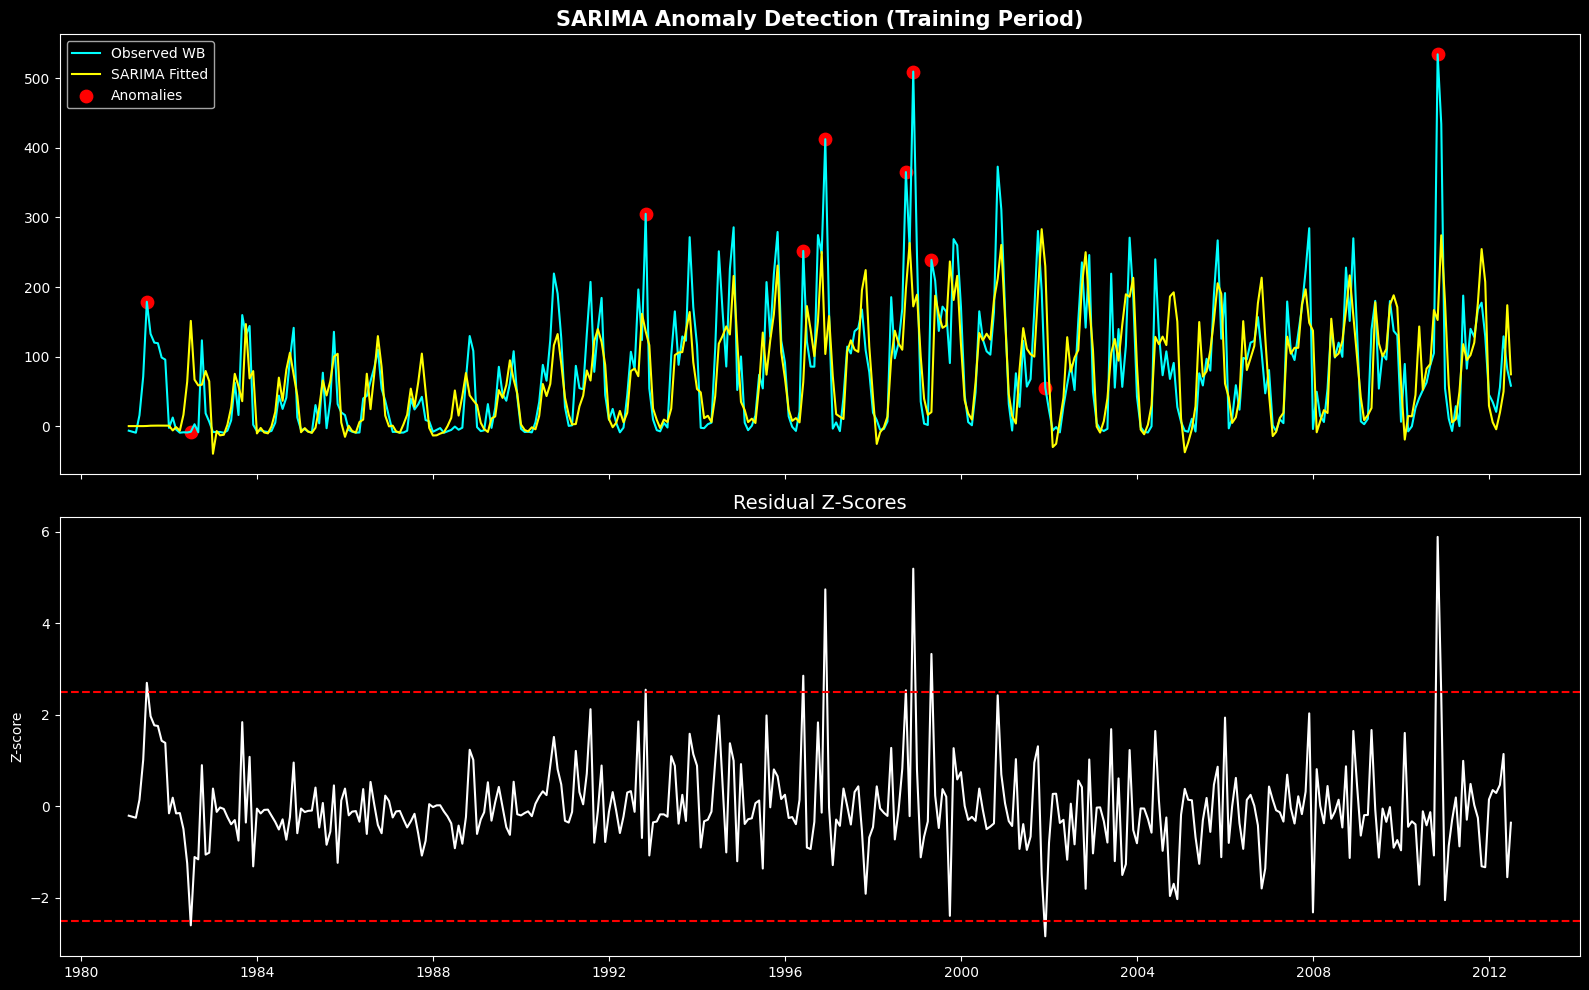

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Residuals from TRAIN period
residuals = sarima_fit.resid

# Standardize residuals
z_scores = (residuals - residuals.mean()) / residuals.std()

threshold = 2.5
anomalies = abs(z_scores) > threshold

print("Total anomalies:", anomalies.sum())

plt.style.use("dark_background")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16,10), sharex=True)

# Top plot: Observed vs Fitted
ax1.plot(train.index, train, color="cyan", label="Observed WB")
ax1.plot(train.index, sarima_fit.fittedvalues, color="yellow", label="SARIMA Fitted")

ax1.scatter(train.index[anomalies],
            train[anomalies],
            color="red",
            s=80,
            label="Anomalies")

ax1.set_title("SARIMA Anomaly Detection (Training Period)",
              fontsize=15, fontweight="bold")
ax1.legend()

# Bottom plot: Residual Z-scores
ax2.plot(train.index, z_scores, color="white")
ax2.axhline(threshold, color="red", linestyle="--")
ax2.axhline(-threshold, color="red", linestyle="--")

ax2.set_title("Residual Z-Scores", fontsize=14)
ax2.set_ylabel("Z-score")

plt.tight_layout()
plt.show()


In [ ]:
print("Historical WB mean:", monthly.mean())
print("Historical WB std:", monthly.std())

print("Simulated WB mean:", simulated_paths.mean())
print("Simulated WB std:", simulated_paths.std())


Historical WB mean: 98.58163102251851
Historical WB std: 108.61093042849554
Simulated WB mean: 0.9889841669762994
Simulated WB std: 1005.8050174751716


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd

# Monthly WB
monthly = df["WB"].resample("ME").sum().dropna()

# STRICTLY stationary model (NO differencing)
model = SARIMAX(
    monthly,
    order=(1,0,1),
    seasonal_order=(0,0,1,12),
    trend='c',   # include constant to preserve mean
    enforce_stationarity=True,
    enforce_invertibility=True
)

arma_fit = model.fit(disp=False)

print(arma_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                                 WB   No. Observations:                  540
Model:             SARIMAX(1, 0, 1)x(0, 0, 1, 12)   Log Likelihood               -3150.398
Date:                            Sat, 21 Feb 2026   AIC                           6310.797
Time:                                    12:35:40   BIC                           6332.255
Sample:                                01-31-1981   HQIC                          6319.189
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     47.5266      9.930      4.786      0.000      28.064      66.989
ar.L1          0.5185      0.055   

In [ ]:
forecast_horizon = 240
simulations = 1000

simulated_paths = []

for i in range(simulations):
    sim = arma_fit.simulate(nsimulations=forecast_horizon)
    simulated_paths.append(sim.values)

simulated_paths = np.array(simulated_paths)


In [ ]:
print("Historical mean:", monthly.mean())
print("Historical std:", monthly.std())

print("Simulated mean:", simulated_paths.mean())
print("Simulated std:", simulated_paths.std())


Historical mean: 98.58163102251851
Historical std: 108.61093042849554
Simulated mean: 98.83476871152588
Simulated std: 101.21845568324686


In [ ]:
# Historical climatology
hist_roll12 = monthly.rolling(12).sum().dropna()
hist_mean = hist_roll12.mean()
hist_std = hist_roll12.std()

severe_counts = []
extreme_counts = []

for path in simulated_paths:

    future_series = pd.Series(path)
    roll12 = future_series.rolling(12).sum().dropna()

    spei = (roll12 - hist_mean) / hist_std

    severe_counts.append(np.sum(spei < -1.5))
    extreme_counts.append(np.sum(spei < -2))

severe_counts = np.array(severe_counts)
extreme_counts = np.array(extreme_counts)


In [ ]:
severe_prob = np.mean(severe_counts > 0)
extreme_prob = np.mean(extreme_counts > 0)

expected_severe_months = severe_counts.mean()
expected_extreme_months = extreme_counts.mean()

print("Probability Severe Drought (20 yrs):", severe_prob)
print("Probability Extreme Drought (20 yrs):", extreme_prob)
print("Expected Severe Months:", expected_severe_months)
print("Expected Extreme Months:", expected_extreme_months)


Probability Severe Drought (20 yrs): 0.894
Probability Extreme Drought (20 yrs): 0.625
Expected Severe Months: 15.495
Expected Extreme Months: 5.537


In [ ]:
import pandas as pd

file = "datatoshafi.xlsx"   # make sure file is uploaded
all_sheets = pd.read_excel(file, sheet_name=None)

df = pd.concat(all_sheets.values(), ignore_index=True)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (49308, 9)


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ===== XGBOOST (Daily) =====
r2_xgb_train = r2_score(y_train, xgb_model.predict(X_train))
rmse_xgb_train = np.sqrt(mean_squared_error(y_train, xgb_model.predict(X_train)))

r2_xgb_test = r2_score(y_test, xgb_model.predict(X_test))
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, xgb_model.predict(X_test)))

# ===== SARIMA (Monthly) =====
r2_sarima_train = r2_score(train, sarima_train_pred)
rmse_sarima_train = np.sqrt(mean_squared_error(train, sarima_train_pred))

r2_sarima_test = r2_score(test, sarima_test_pred)
rmse_sarima_test = np.sqrt(mean_squared_error(test, sarima_test_pred))

print("XGBoost Train R²:", r2_xgb_train)
print("XGBoost Train RMSE:", rmse_xgb_train)
print("XGBoost Test R²:", r2_xgb_test)
print("XGBoost Test RMSE:", rmse_xgb_test)

print("\nSARIMA Train R²:", r2_sarima_train)
print("SARIMA Train RMSE:", rmse_sarima_train)
print("SARIMA Test R²:", r2_sarima_test)
print("SARIMA Test RMSE:", rmse_sarima_test)

XGBoost Train R²: 0.9762639669902872
XGBoost Train RMSE: 42.93370484771428
XGBoost Test R²: 0.29161727078973865
XGBoost Test RMSE: 331.4894982208314

SARIMA Train R²: 0.3961556173038592
SARIMA Train RMSE: 213.12801355796674
SARIMA Test R²: -0.2775839559922726
SARIMA Test RMSE: 444.08167803062753


In [ ]:
future_months = 240

sarima_future = sarima_fit.simulate(nsimulations=future_months)

future_dates = pd.date_range(
    start=monthly.index[-1],
    periods=future_months + 1,
    freq="ME"
)[1:]

sarima_future = pd.Series(sarima_future.values, index=future_dates)

In [ ]:
hist_roll12 = monthly.rolling(12).sum().dropna()
hist_mean = hist_roll12.mean()
hist_std = hist_roll12.std()

future_roll12 = sarima_future.rolling(12).sum().dropna()
future_spei = (future_roll12 - hist_mean) / hist_std

severe_future = future_spei < -1.5
extreme_future = future_spei < -2

print("Future Severe Months:", severe_future.sum())
print("Future Extreme Months:", extreme_future.sum())

Future Severe Months: 11
Future Extreme Months: 0


In [ ]:
# SARIMA anomalies
sarima_resid = sarima_fit.resid
z_sarima = (sarima_resid - sarima_resid.mean()) / sarima_resid.std()
sarima_anomaly = abs(z_sarima) > 2.5

# XGBoost anomalies (daily residuals)
xgb_residuals = y_test - xgb_model.predict(X_test)
z_xgb = (xgb_residuals - xgb_residuals.mean()) / xgb_residuals.std()
xgb_anomaly = abs(z_xgb) > 2.5

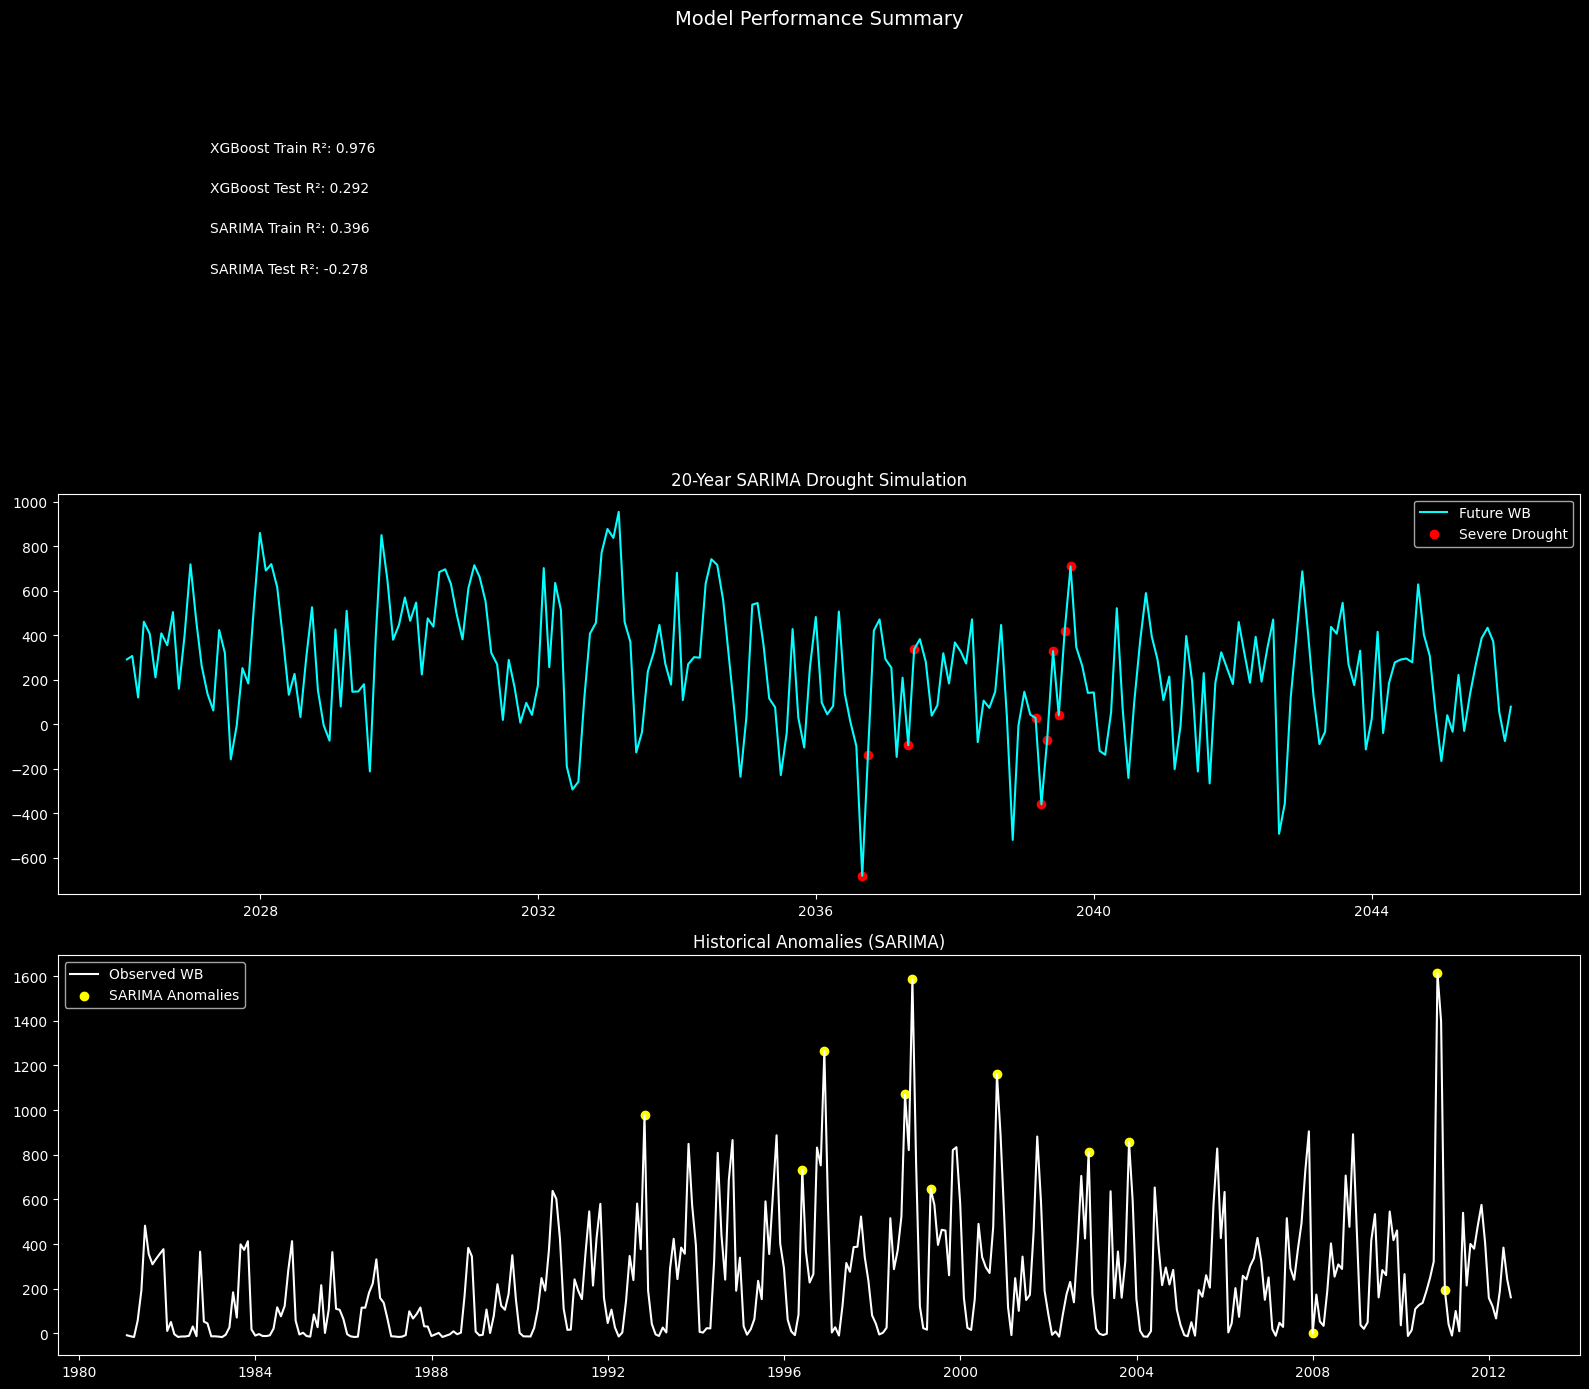

In [ ]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# ===== PANEL 1: Performance Table =====
axes[0].axis('off')
axes[0].text(0.1, 0.7, f"XGBoost Train R²: {r2_xgb_train:.3f}")
axes[0].text(0.1, 0.6, f"XGBoost Test R²: {r2_xgb_test:.3f}")
axes[0].text(0.1, 0.5, f"SARIMA Train R²: {r2_sarima_train:.3f}")
axes[0].text(0.1, 0.4, f"SARIMA Test R²: {r2_sarima_test:.3f}")
axes[0].set_title("Model Performance Summary", fontsize=14)

# ===== PANEL 2: 20-Year Drought Forecast =====
axes[1].plot(sarima_future.index, sarima_future, color="cyan", label="Future WB")
axes[1].scatter(future_spei.index[severe_future],
                sarima_future.loc[future_spei.index[severe_future]],
                color="red", label="Severe Drought")
axes[1].set_title("20-Year SARIMA Drought Simulation")
axes[1].legend()

# ===== PANEL 3: Anomaly Detection =====
axes[2].plot(train.index, train, color="white", label="Observed WB")
axes[2].scatter(train.index[sarima_anomaly],
                train[sarima_anomaly],
                color="yellow", label="SARIMA Anomalies")
axes[2].set_title("Historical Anomalies (SARIMA)")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Monthly aggregation
monthly = df["WB"].resample("ME").sum().dropna()

print("Length:", len(monthly))
print("Start:", monthly.index[0])
print("End:", monthly.index[-1])

Length: 540
Start: 1981-01-31 00:00:00
End: 2025-12-31 00:00:00


In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -2.146853545314227
p-value: 0.2260964167606282


In [ ]:
from statsmodels.tsa.seasonal import STL

stl = STL(monthly, period=12, robust=True)
res = stl.fit()

trend = res.trend
seasonal = res.seasonal
residual = res.resid

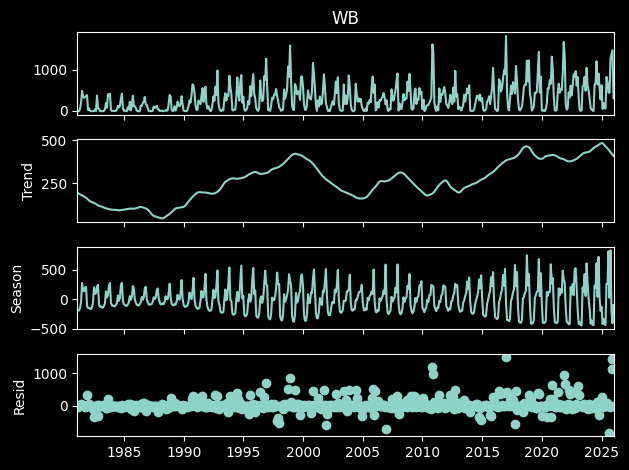

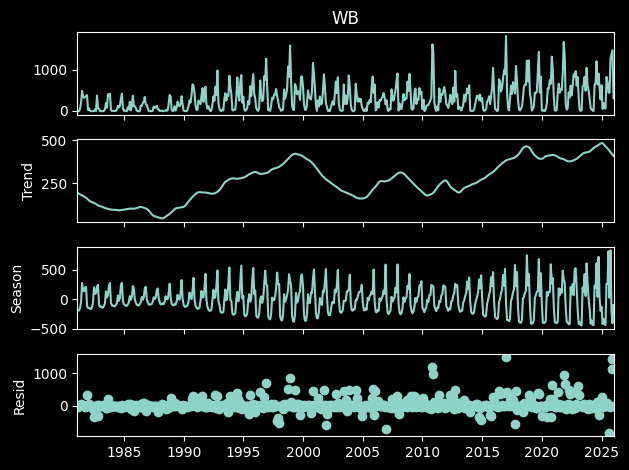

In [ ]:
res.plot()

In [ ]:
adf_resid = adfuller(residual.dropna())
print("Residual ADF p:", adf_resid[1])

Residual ADF p: 1.2357630679717846e-08


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    residual,
    order=(1,0,1),
    seasonal_order=(0,0,1,12),
    enforce_stationarity=True,
    enforce_invertibility=True
)

sarima_resid = model.fit(disp=False)
print(sarima_resid.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              resid   No. Observations:                  540
Model:             SARIMAX(1, 0, 1)x(0, 0, 1, 12)   Log Likelihood               -3642.899
Date:                            Fri, 27 Feb 2026   AIC                           7293.797
Time:                                    20:26:01   BIC                           7310.964
Sample:                                01-31-1981   HQIC                          7300.511
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2729      0.179      1.523      0.128      -0.078       0.624
ma.L1         -0.0485      0.178   

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

ljung = acorr_ljungbox(sarima_resid.resid, lags=[12], return_df=True)
jb = jarque_bera(sarima_resid.resid)

print("Ljung-Box p:", ljung["lb_pvalue"].values[0])
print("Jarque-Bera p:", jb[1])

Ljung-Box p: 0.10036948806971534
Jarque-Bera p: 0.0


In [ ]:
n_sim = 1000
horizon = 240  # 20 years monthly

sim_paths = []

for i in range(n_sim):
    sim = sarima_resid.simulate(nsimulations=horizon)
    sim_paths.append(sim.values)

sim_paths = np.array(sim_paths)

In [ ]:
future_index = pd.date_range(
    start=monthly.index[-1],
    periods=horizon+1,
    freq="ME"
)[1:]

future_trend = np.repeat(trend.iloc[-1], horizon)
future_season = np.tile(seasonal[-12:], horizon//12)

# Combine
future_full = sim_paths + future_trend + future_season

In [ ]:
hist_roll12 = monthly.rolling(12).sum().dropna()
hist_mean = hist_roll12.mean()
hist_std = hist_roll12.std()

severe_probs = []
extreme_probs = []

for path in future_full:
    series = pd.Series(path)
    roll12 = series.rolling(12).sum().dropna()
    spei = (roll12 - hist_mean) / hist_std

    severe = (spei < -1.5).mean()
    extreme = (spei < -2).mean()

    severe_probs.append(severe)
    extreme_probs.append(extreme)

print("Mean Severe Probability:", np.mean(severe_probs))
print("Mean Extreme Probability:", np.mean(extreme_probs))

Mean Severe Probability: 8.733624454148471e-06
Mean Extreme Probability: 0.0


In [ ]:
print("Severe 5th percentile:", np.percentile(severe_probs, 5))
print("Severe 95th percentile:", np.percentile(severe_probs, 95))

print("Extreme 5th percentile:", np.percentile(extreme_probs, 5))
print("Extreme 95th percentile:", np.percentile(extreme_probs, 95))

Severe 5th percentile: 0.0
Severe 95th percentile: 0.0
Extreme 5th percentile: 0.0
Extreme 95th percentile: 0.0


In [ ]:
print("Sensitivity — Mean Severe ± Std:",
      np.mean(severe_probs),
      np.std(severe_probs))

Sensitivity — Mean Severe ± Std: 8.733624454148471e-06 0.00027604332976906737


In [ ]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

model_llt = UnobservedComponents(
    monthly,
    level='local linear trend',
    seasonal=12,
    autoregressive=1

)

llt_fit = model_llt.fit()

print(llt_fit.summary())

                            Unobserved Components Results                            
Dep. Variable:                            WB   No. Observations:                  540
Model:                    local linear trend   Log Likelihood               -3610.196
                   + stochastic seasonal(12)   AIC                           7232.392
                                     + AR(1)   BIC                           7257.996
Date:                       Fri, 27 Feb 2026   HQIC                          7242.416
Time:                               20:39:26                                         
Sample:                           01-31-1981                                         
                                - 12-31-2025                                         
Covariance Type:                         opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

resid = llt_fit.resid

print("Ljung-Box p:", acorr_ljungbox(resid, lags=[12], return_df=True)["lb_pvalue"].values[0])
print("Jarque-Bera p:", jarque_bera(resid)[1])

Ljung-Box p: 5.7725798551419546e-08
Jarque-Bera p: 1.7300850416542383e-197


In [ ]:
n_sim = 1000
horizon = 240

simulations = llt_fit.simulate(nsimulations=horizon, repetitions=n_sim)

future_index = pd.date_range(
    start=monthly.index[-1],
    periods=horizon+1,
    freq="ME"
)[1:]

simulations.index = future_index

In [ ]:
hist_roll12 = monthly.rolling(12).sum().dropna()
hist_mean = hist_roll12.mean()
hist_std = hist_roll12.std()

severe_probs = []
extreme_probs = []

for col in simulations.columns:
    series = simulations[col]
    roll12 = series.rolling(12).sum().dropna()
    spei = (roll12 - hist_mean) / hist_std

    severe_probs.append((spei < -1.5).mean())
    extreme_probs.append((spei < -2).mean())

print("Mean Severe Probability:", np.mean(severe_probs))
print("Mean Extreme Probability:", np.mean(extreme_probs))

Mean Severe Probability: 0.4940218340611353
Mean Extreme Probability: 0.4935807860262008


In [ ]:
print("Severe 5th percentile:", np.percentile(severe_probs, 5))
print("Severe 95th percentile:", np.percentile(severe_probs, 95))

print("Extreme 5th percentile:", np.percentile(extreme_probs, 5))
print("Extreme 95th percentile:", np.percentile(extreme_probs, 95))

Severe 5th percentile: 0.0
Severe 95th percentile: 1.0
Extreme 5th percentile: 0.0
Extreme 95th percentile: 1.0


In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

# Monthly aggregation
monthly = df["WB"].resample("ME").sum().dropna()

print("Length:", len(monthly))


Length: 540


In [ ]:
model = UnobservedComponents(
    monthly,
    level='local linear trend',
    seasonal=12,
    autoregressive=1
)

llt_fit = model.fit()

print(llt_fit.summary())

                            Unobserved Components Results                            
Dep. Variable:                            WB   No. Observations:                  540
Model:                    local linear trend   Log Likelihood               -3610.196
                   + stochastic seasonal(12)   AIC                           7232.392
                                     + AR(1)   BIC                           7257.996
Date:                       Fri, 27 Feb 2026   HQIC                          7242.416
Time:                               20:41:08                                         
Sample:                           01-31-1981                                         
                                - 12-31-2025                                         
Covariance Type:                         opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

In [ ]:
resid = llt_fit.resid

ljung_p = acorr_ljungbox(resid, lags=[12], return_df=True)["lb_pvalue"].values[0]
jb_p = jarque_bera(resid)[1]

print("Ljung-Box p-value:", ljung_p)
print("Jarque-Bera p-value:", jb_p)

Ljung-Box p-value: 5.7725798551419546e-08
Jarque-Bera p-value: 1.7300850416542383e-197


In [ ]:
n_sim = 1000
horizon = 240  # 20 years monthly

simulations = llt_fit.simulate(
    nsimulations=horizon,
    repetitions=n_sim
)

future_index = pd.date_range(
    start=monthly.index[-1],
    periods=horizon+1,
    freq="ME"
)[1:]

simulations.index = future_index

In [ ]:
hist_roll12 = monthly.rolling(12).sum().dropna()
hist_mean = hist_roll12.mean()
hist_std = hist_roll12.std()

severe_probs = []
extreme_probs = []

for col in simulations.columns:
    series = simulations[col]
    roll12 = series.rolling(12).sum().dropna()
    spei = (roll12 - hist_mean) / hist_std

    severe_probs.append((spei < -1.5).mean())
    extreme_probs.append((spei < -2).mean())

mean_severe = np.mean(severe_probs)
mean_extreme = np.mean(extreme_probs)

print("Mean Severe Probability:", mean_severe)
print("Mean Extreme Probability:", mean_extreme)

Mean Severe Probability: 0.4902270742358079
Mean Extreme Probability: 0.4897467248908297
